## 題號 1
**問題**: 周天成使用「殺球」得分佔他總得分的百分比是多少？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：text；renderer：renderer / completed


In [ ]:
required_cols = {"player", "getpoint_player", "type"}

if len(df) == 0:
    payload = {
        "label": "周天成殺球得分佔總得分比例",
        "value": None,
        "unit": "%",
        "note": "資料為空，無法計算。"
    }
elif not required_cols.issubset(df.columns):
    missing_cols = sorted(required_cols - set(df.columns))
    payload = {
        "label": "周天成殺球得分佔總得分比例",
        "value": None,
        "unit": "%",
        "note": f"缺少必要欄位：{missing_cols}"
    }
else:
    active_win = (
        df["player"].eq("CHOU Tien Chen")
        & df["getpoint_player"].eq("CHOU Tien Chen")
    )

    total_active_wins = int(active_win.sum())
    smash_active_wins = int(
        (active_win & df["type"].eq("殺球")).sum()
    )

    percentage = (
        smash_active_wins / total_active_wins * 100
        if total_active_wins > 0 else None
    )

    payload = {
        "label": "周天成殺球得分佔總得分比例",
        "value": round(percentage, 2) if percentage is not None else None,
        "unit": "%",
        "note": (
            f"殺球主動得分 {smash_active_wins} 次；"
            f"總主動得分 {total_active_wins} 次。"
            if percentage is not None
            else "周天成沒有可辨識的主動得分事件，無法計算比例。"
        )
    }

template_output = render_output(kind="text", payload=payload)


周天成殺球得分佔總得分比例: 71.76%
殺球主動得分 61 次；總主動得分 85 次。


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 6
**問題**: 在第一場次中，每回合用的拍數，繪圖
> **使用的資料欄位群組**: `game_structure`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：bar；renderer：renderer / completed


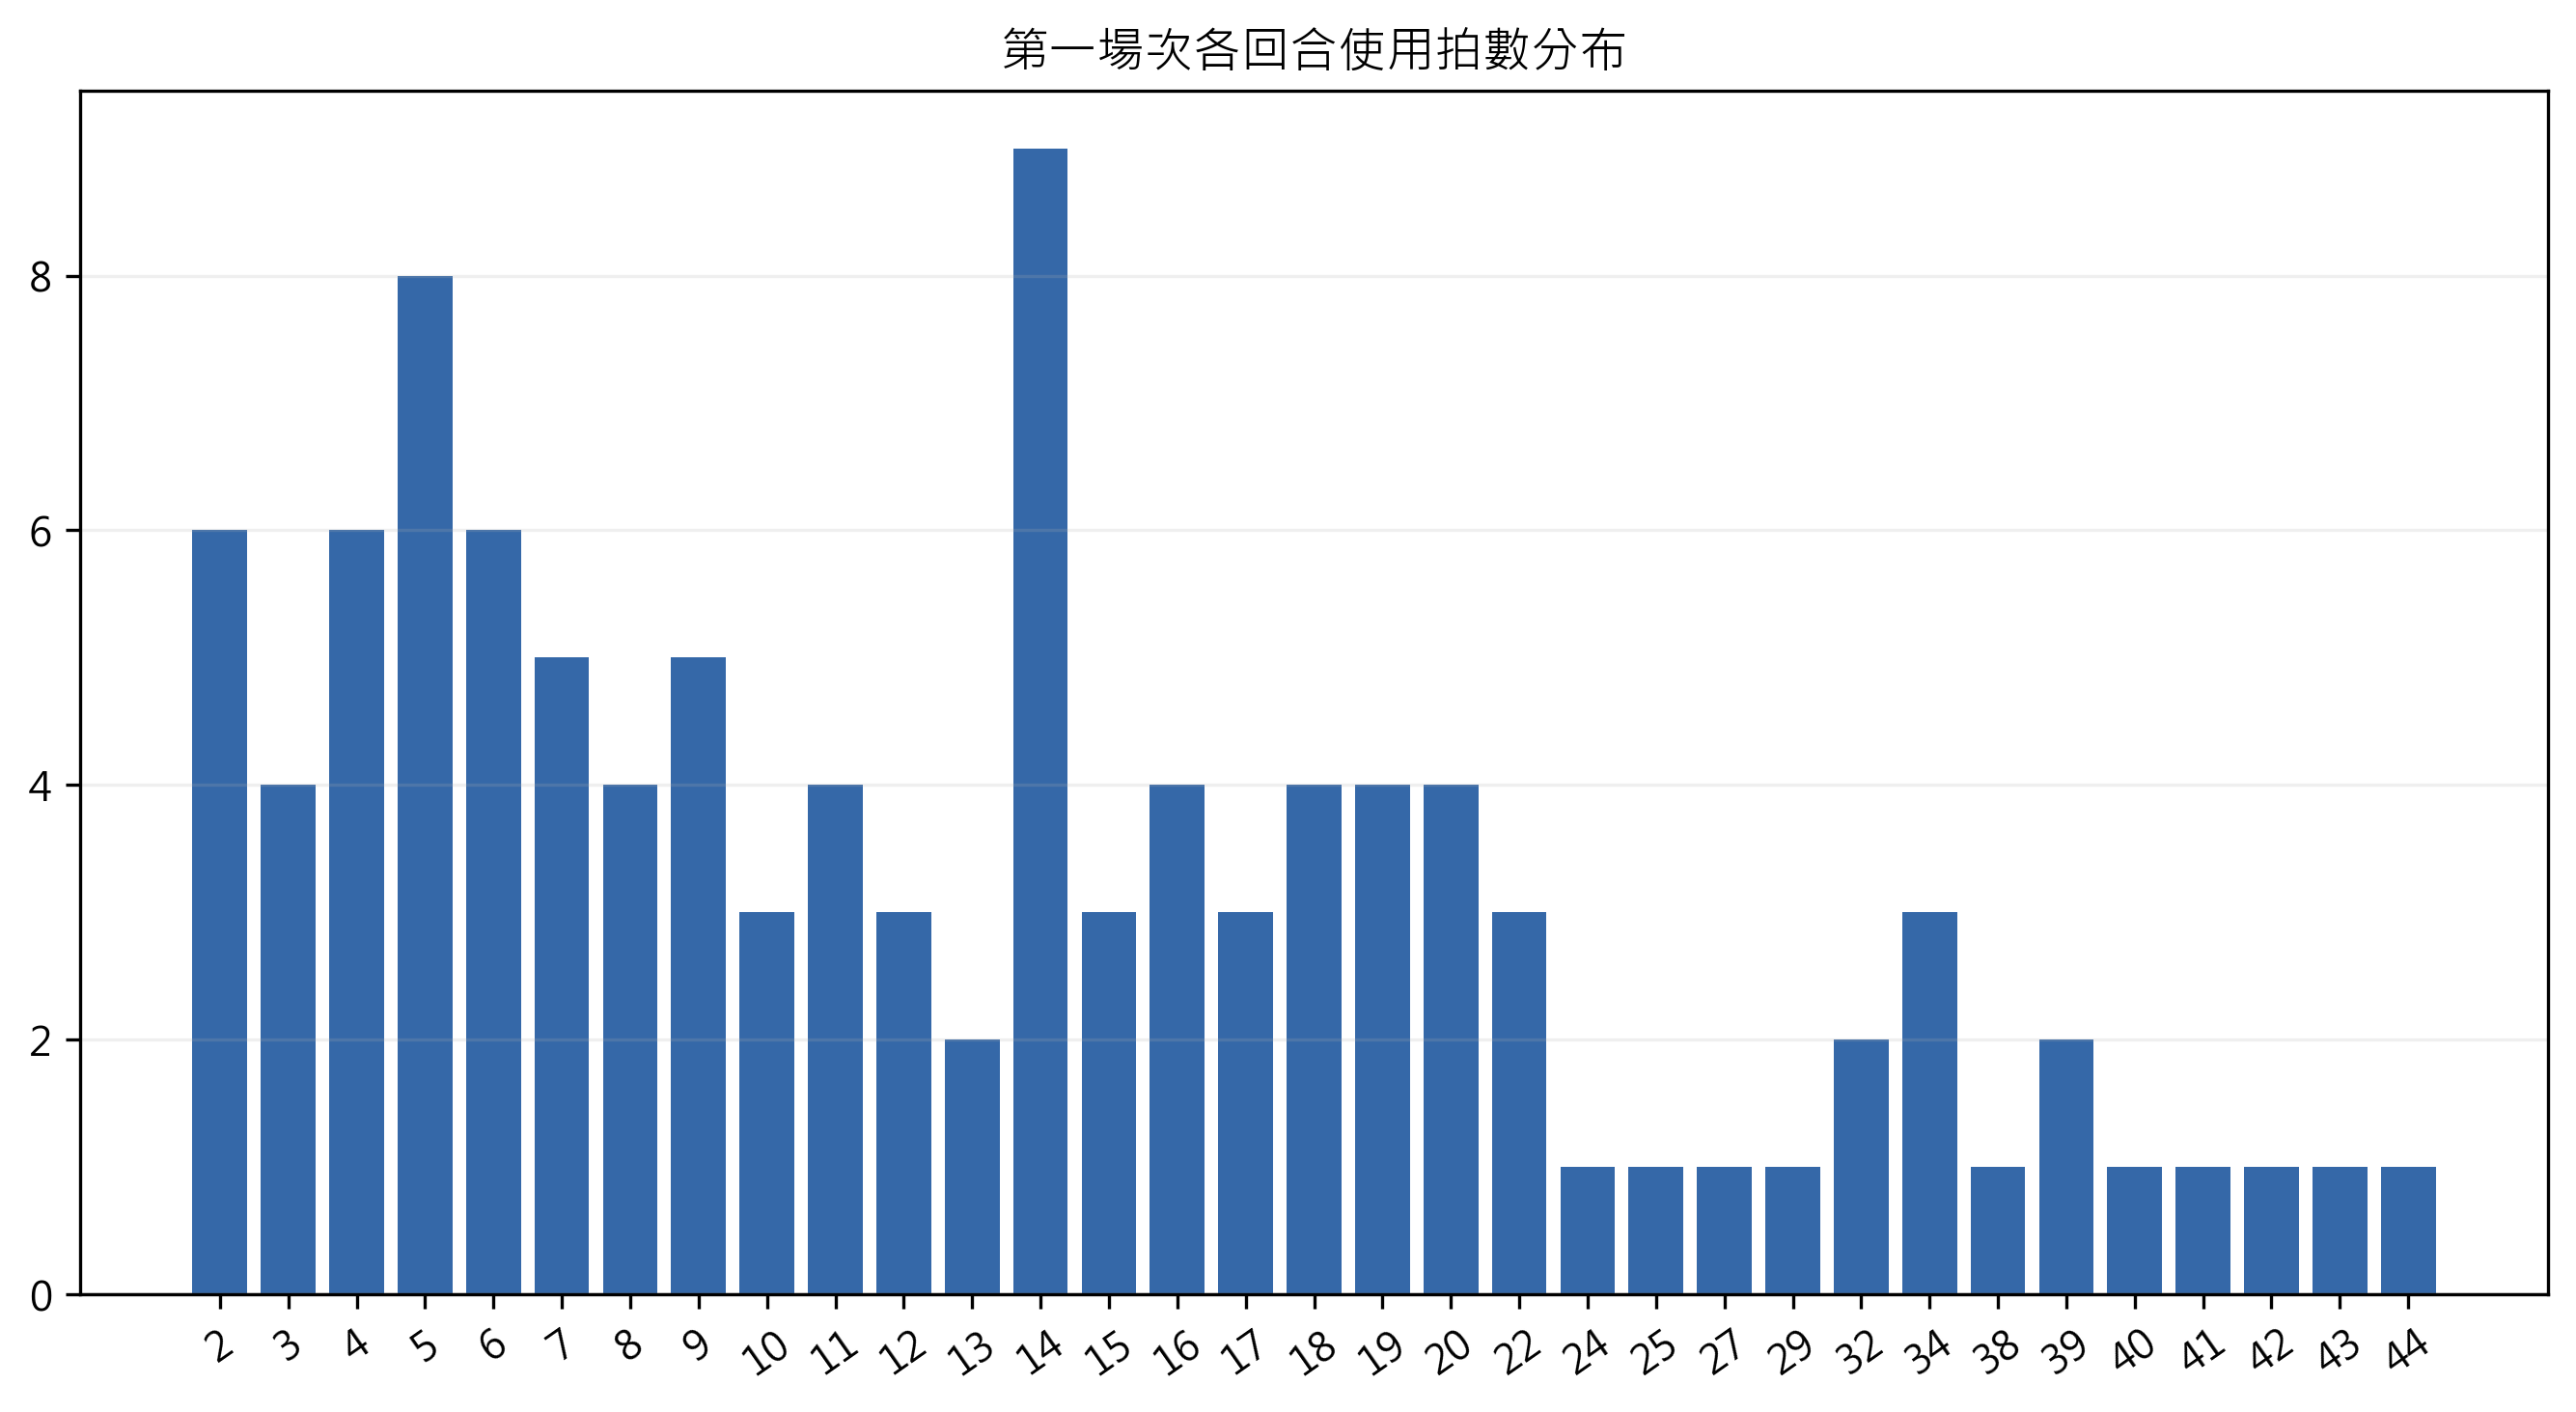

In [ ]:
required_cols = {"match_id", "set", "rally", "ball_round"}

if len(df) == 0:
    payload = {
        "series": [{"name": "回合數", "labels": [], "values": []}]
    }
    template_output = render_output(
        kind="bar",
        payload=payload,
        title="第一場次各回合使用拍數"
    )
elif not required_cols.issubset(df.columns):
    missing_cols = sorted(required_cols - set(df.columns))
    print(f"資料缺少必要欄位：{missing_cols}")
    payload = {
        "series": [{"name": "回合數", "labels": [], "values": []}]
    }
    template_output = render_output(
        kind="bar",
        payload=payload,
        title="第一場次各回合使用拍數"
    )
else:
    match_df = df.loc[
        df["match_id"].eq(1),
        ["match_id", "set", "rally", "ball_round"]
    ].dropna(subset=["match_id", "set", "rally", "ball_round"]).copy()

    rally_shots = (
        match_df
        .groupby(["match_id", "set", "rally"], sort=True)
        .size()
        .rename("拍數")
        .reset_index()
    )

    distribution = (
        rally_shots
        .groupby("拍數", sort=True)
        .size()
        .rename("回合數")
        .reset_index()
    )

    labels = distribution["拍數"].astype(int).astype(str).tolist()
    values = distribution["回合數"].astype(int).tolist()

    payload = {
        "series": [{"name": "回合數", "labels": labels, "values": values}]
    }

    template_output = render_output(
        kind="bar",
        payload=payload,
        title="第一場次各回合使用拍數分布"
    )


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 10
**問題**: 當周天成站在前場時，他最主要的得分球種?
> **使用的資料欄位群組**: `game_structure, shot_type, player_location, scoring_reason`


### 流程摘要

- 場地資訊：完整場地資訊（判定來源：llm+semantic_guard）
- 輸出：text；renderer：renderer / completed


In [ ]:
required_cols = {
    'player', 'getpoint_player', 'type', 'player_location_area'
}

if len(df) == 0:
    payload = {
        "label": "周天成前場主動得分球種",
        "value": "資料不足",
        "unit": "",
        "note": "df 無資料，無法進行統計。"
    }
elif not required_cols.issubset(df.columns):
    missing_cols = sorted(required_cols - set(df.columns))
    payload = {
        "label": "周天成前場主動得分球種",
        "value": "欄位不足",
        "unit": "",
        "note": f"缺少必要欄位：{missing_cols}"
    }
else:
    front_zones = [17, 18, 19, 20, 21, 22, 23, 24]

    analysis_df = df[
        df['player'].notna()
        & df['getpoint_player'].notna()
        & df['type'].notna()
        & df['player_location_area'].notna()
    ].copy()

    active_front_wins = analysis_df[
        (analysis_df['player'] == 'CHOU Tien Chen')
        & (analysis_df['getpoint_player'] == 'CHOU Tien Chen')
        & (analysis_df['player_location_area'].isin(front_zones))
    ].copy()

    if len(active_front_wins) == 0:
        payload = {
            "label": "周天成前場主動得分球種",
            "value": "無符合資料",
            "unit": "",
            "note": (
                "統計口徑：單拍、周天成站在前場區域（17–24），"
                "且擊球者與得分者皆為周天成的 Active Win。"
            )
        }
    else:
        shot_counts = (
            active_front_wins.groupby('type', as_index=False)
            .size()
            .rename(columns={'size': '得分拍數'})
            .sort_values(['得分拍數', 'type'], ascending=[False, True])
            .reset_index(drop=True)
        )

        top_count = int(shot_counts.loc[0, '得分拍數'])
        top_shots = shot_counts.loc[
            shot_counts['得分拍數'] == top_count, 'type'
        ].tolist()

        total_active_front_wins = len(active_front_wins)
        top_ratio = top_count / total_active_front_wins * 100
        shot_evidence = '；'.join(
            f"{row['type']}：{int(row['得分拍數'])}拍"
            for _, row in shot_counts.iterrows()
        )

        payload = {
            "label": "周天成前場主動得分球種",
            "value": "、".join(top_shots),
            "unit": "",
            "note": (
                f"最高為 {top_count} 拍，占周天成前場主動得分的 "
                f"{top_ratio:.1f}%。總前場主動得分："
                f"{total_active_front_wins} 拍。各球種統計：{shot_evidence}。"
                "前場定義依場地 metadata：區域 17–24，"
                "其中 17–20 為前排 M1、21–24 為網前 M2。"
            )
        }

template_output = render_output(
    kind='text',
    payload=payload,
    title='周天成站在前場時的主要得分球種'
)


周天成前場主動得分球種: 殺球
最高為 7 拍，占周天成前場主動得分的 77.8%。總前場主動得分：9 拍。各球種統計：殺球：7拍；推撲球：2拍。前場定義依場地 metadata：區域 17–24，其中 17–20 為前排 M1、21–24 為網前 M2。


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 13
**問題**: 幫我統整周天成所有球種的使用比例，以及每種球種的「得分次數」和「失誤次數」。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：table；renderer：renderer / completed


In [ ]:
required_cols = ['player', 'type', 'getpoint_player', 'opponent']

if len(df) == 0:
    payload = {
        "columns": ["球種", "使用次數", "使用比例", "得分次數", "失誤次數"],
        "rows": []
    }
    template_output = render_output(
        kind='table',
        payload=payload,
        title='周天成各球種使用與得失分統計'
    )
elif not set(required_cols).issubset(df.columns):
    missing_cols = [col for col in required_cols if col not in df.columns]
    print(f"缺少必要欄位：{missing_cols}")
else:
    target_player = 'CHOU Tien Chen'

    chou_df = df.loc[
        df['player'].eq(target_player),
        required_cols
    ].dropna(subset=['type']).copy()

    if len(chou_df) == 0:
        payload = {
            "columns": ["球種", "使用次數", "使用比例", "得分次數", "失誤次數"],
            "rows": []
        }
    else:
        chou_df['得分事件'] = (
            chou_df['getpoint_player'].eq(chou_df['player'])
        )
        chou_df['失誤事件'] = (
            chou_df['getpoint_player'].eq(chou_df['opponent'])
        )

        summary = (
            chou_df.groupby('type', sort=False)
            .agg(
                使用次數=('type', 'size'),
                得分次數=('得分事件', 'sum'),
                失誤次數=('失誤事件', 'sum')
            )
            .reset_index()
            .rename(columns={'type': '球種'})
        )

        total_usage = summary['使用次數'].sum()
        summary['使用比例'] = (
            summary['使用次數'] / total_usage * 100
            if total_usage > 0 else 0
        )

        summary = summary[['球種', '使用次數', '使用比例', '得分次數', '失誤次數']]
        summary['使用比例'] = summary['使用比例'].round(2)

        payload = {
            "columns": summary.columns.tolist(),
            "rows": summary.astype(object).where(summary.notna(), None).values.tolist()
        }

    template_output = render_output(
        kind='table',
        payload=payload,
        title='周天成各球種使用與得失分統計'
    )


球種  使用次數  使用比例  得分次數  失誤次數
  長球   275 10.54     2    11
 推撲球   334 12.80     9    20
接殺防守   351 13.45     5    37
  平球   106  4.06     2     8
 網前球   582 22.31     4    40
  殺球   299 11.46    61    20
  挑球   270 10.35     0    17
 發短球   147  5.63     0     0
  切球   211  8.09     2     7
 發長球    34  1.30     0     0


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 16
**問題**: 給我周天成最常見的失分原因
> **使用的資料欄位群組**: `game_structure, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：text；renderer：renderer / completed


In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round',
    'player', 'opponent', 'getpoint_player',
    'lose_reason', 'win_reason'
]

missing_cols = [col for col in required_cols if col not in df.columns]

if len(missing_cols) > 0:
    payload = {
        "label": "周天成最常見的失分原因",
        "value": "資料欄位不足",
        "unit": "",
        "note": f"缺少欄位：{', '.join(missing_cols)}"
    }
else:
    target_player = 'CHOU Tien Chen'

    if len(df) == 0:
        payload = {
            "label": "周天成最常見的失分原因",
            "value": "無資料",
            "unit": "",
            "note": "DataFrame 沒有資料列。"
        }
    else:
        work = df.sort_values(
            ['match_id', 'set', 'rally', 'ball_round'],
            kind='mergesort'
        ).copy()

        rally_end = (
            work.groupby(
                ['match_id', 'set', 'rally'],
                sort=False,
                dropna=False
            )
            .tail(1)
            .copy()
        )

        lost_rallies = rally_end[
            rally_end['getpoint_player'].notna()
            & (rally_end['getpoint_player'] == rally_end['opponent'])
            & (
                (rally_end['player'] == target_player)
                | (rally_end['opponent'] == target_player)
            )
        ].copy()

        if len(lost_rallies) == 0:
            payload = {
                "label": "周天成最常見的失分原因",
                "value": "無法判定",
                "unit": "",
                "note": "找不到周天成失分的有效回合。"
            }
        else:
            lost_rallies['loss_reason'] = lost_rallies['lose_reason']

            opponent_active_win = lost_rallies['player'] != target_player
            lost_rallies.loc[opponent_active_win, 'loss_reason'] = (
                lost_rallies.loc[opponent_active_win, 'win_reason']
            )

            lost_rallies['loss_reason'] = (
                lost_rallies['loss_reason']
                .astype('string')
                .fillna('原因未記錄')
            )

            reason_counts = (
                lost_rallies['loss_reason']
                .value_counts()
                .rename_axis('失分原因')
                .reset_index(name='失分次數')
            )

            top_reason = reason_counts.iloc[0]
            total_lost = int(len(lost_rallies))
            top_count = int(top_reason['失分次數'])
            top_reason_name = str(top_reason['失分原因'])

            count_text = '；'.join(
                f"{row['失分原因']}：{int(row['失分次數'])} 次"
                for _, row in reason_counts.iterrows()
            )

            payload = {
                "label": "周天成最常見的失分原因",
                "value": top_reason_name,
                "unit": "次",
                "note": (
                    f"周天成共失分 {total_lost} 個回合；"
                    f"最常見原因為「{top_reason_name}」，共 {top_count} 次。"
                    f"各原因統計：{count_text}"
                )
            }

template_output = render_output(
    kind='text',
    payload=payload,
    title='周天成最常見的失分原因'
)


周天成最常見的失分原因: 原因未記錄次
周天成共失分 262 個回合；最常見原因為「原因未記錄」，共 109 次。各原因統計：原因未記錄：109 次；出界：72 次；掛網：57 次；未過網：24 次


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 17
**問題**: 繪製周天成所有輸球原因為'掛網'時的球員站位熱區圖？
> **使用的資料欄位群組**: `game_structure, player_location, scoring_reason`


### 流程摘要

- 場地資訊：完整場地資訊（判定來源：llm）
- 輸出：heatmap；renderer：renderer / completed


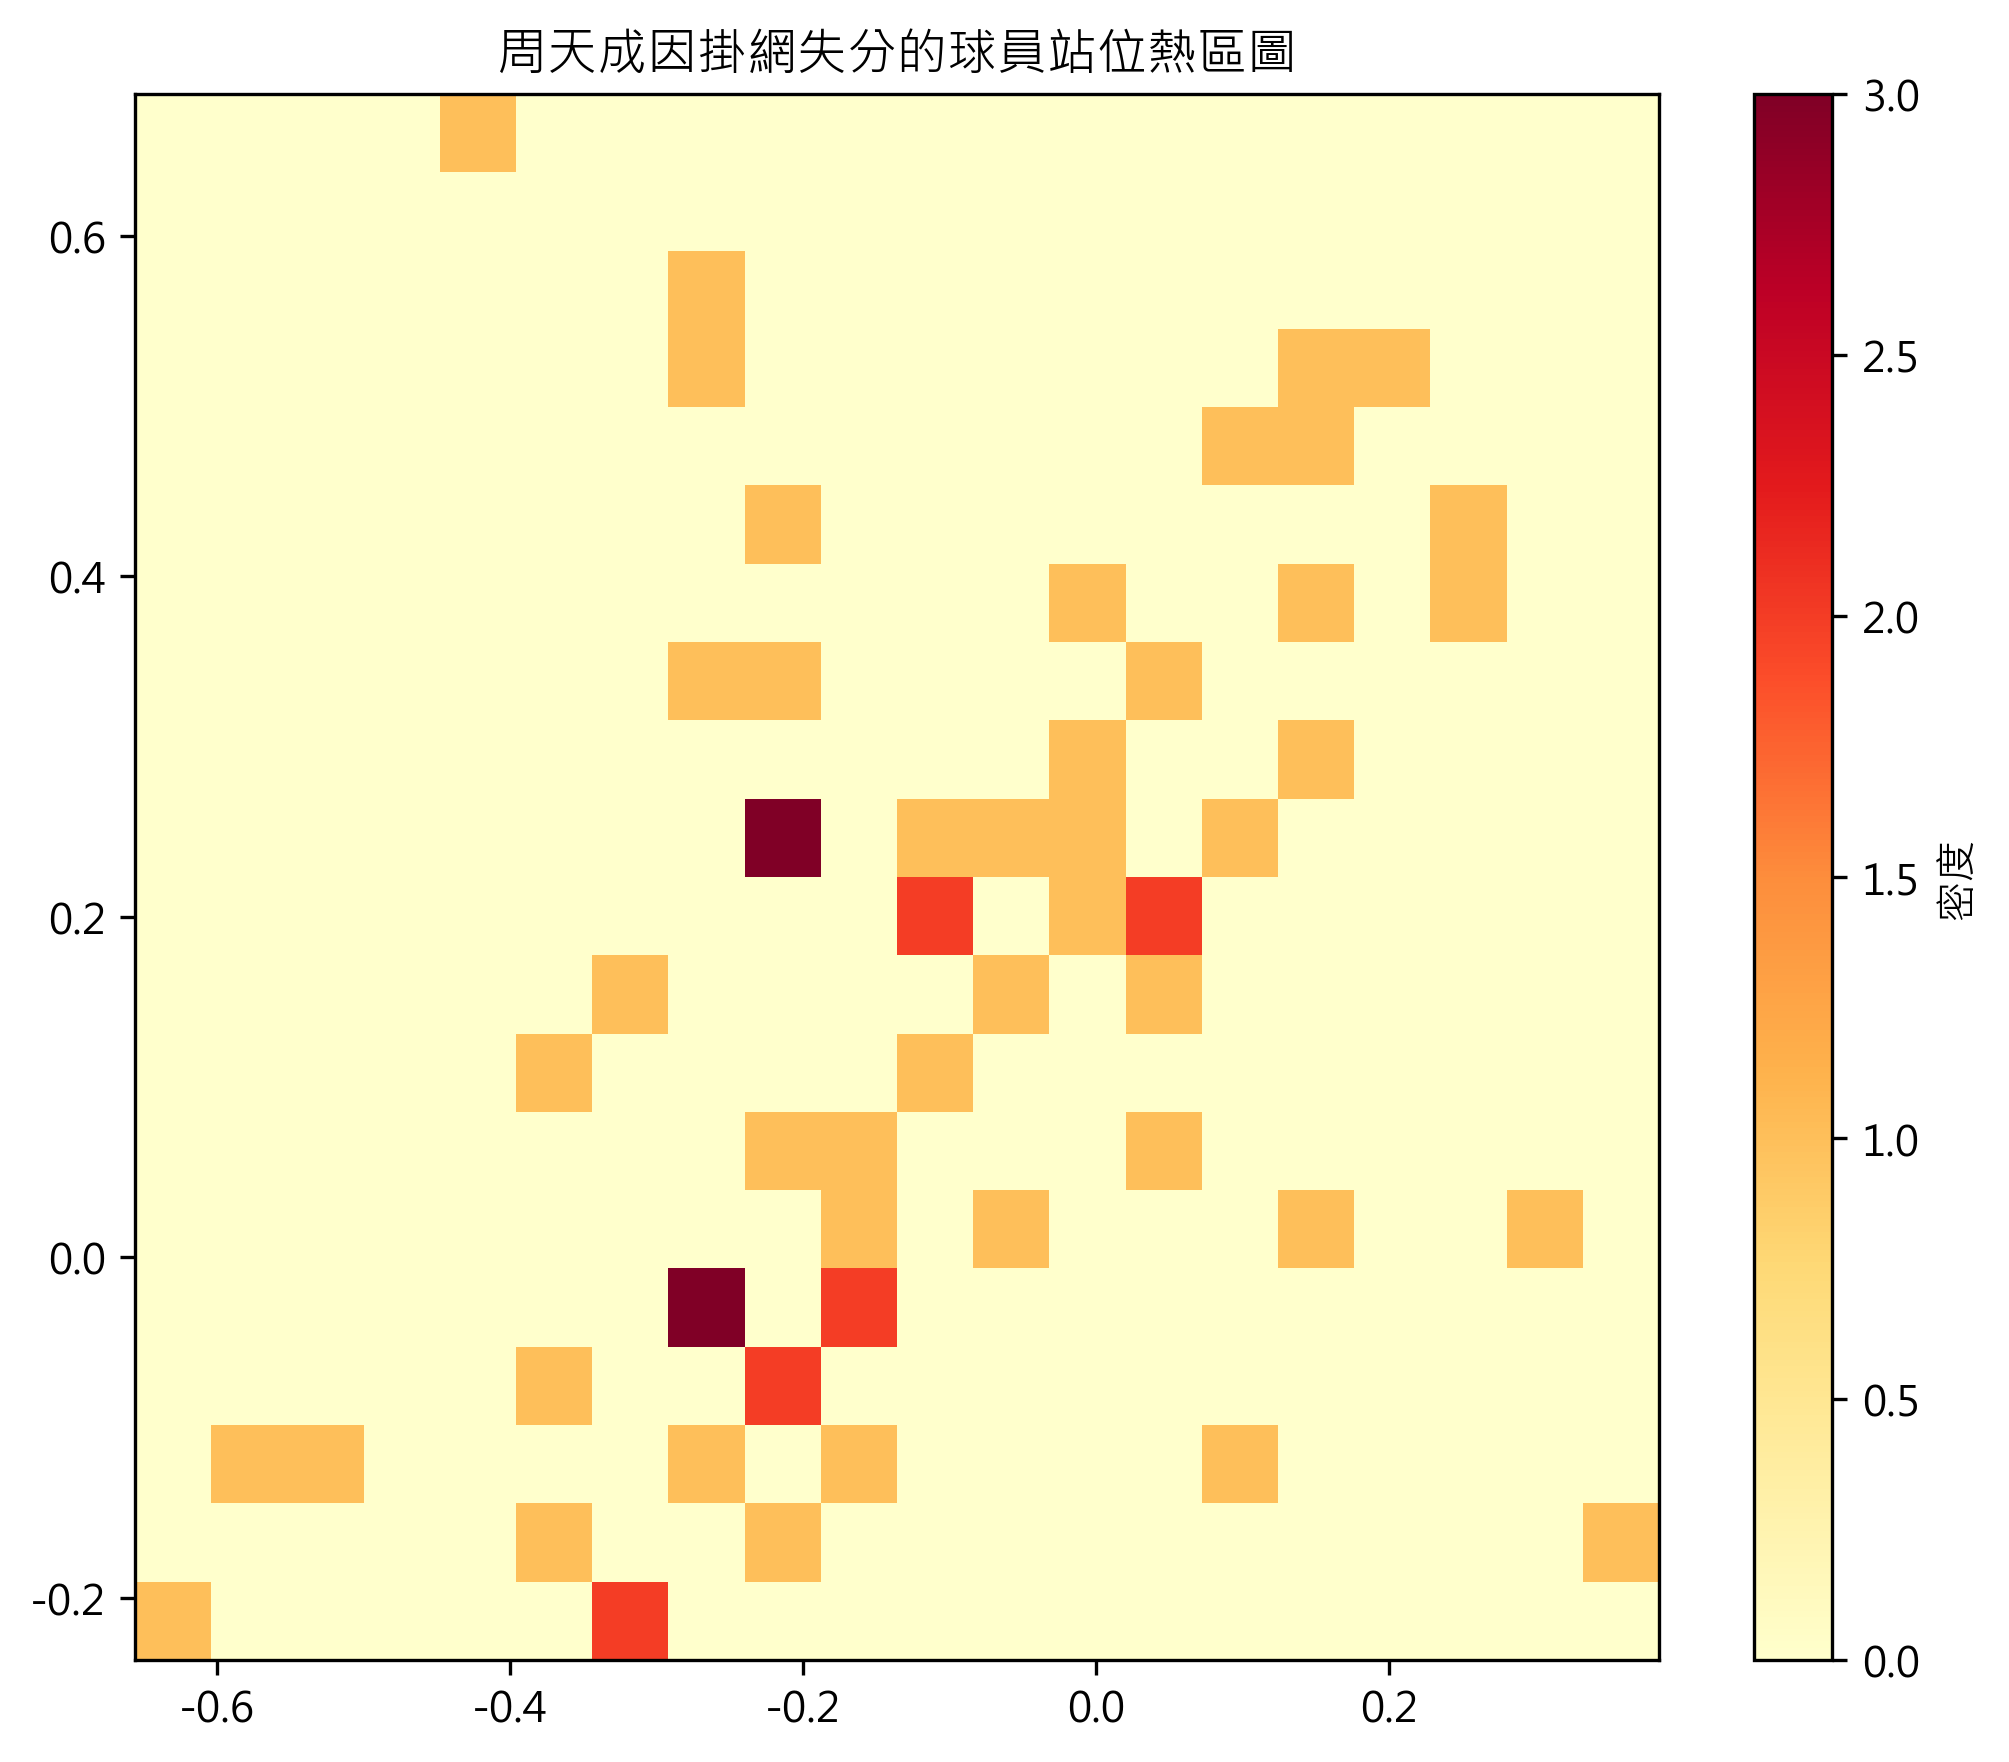

In [ ]:
target_player = "CHOU Tien Chen"
required_columns = [
    "player",
    "lose_reason",
    "player_location_x",
    "player_location_y",
]

if len(df) == 0:
    heatmap_x = []
    heatmap_y = []
    heatmap_weights = None
    title = "周天成因掛網失分的球員站位熱區圖（無資料）"
elif not set(required_columns).issubset(df.columns):
    missing_columns = [c for c in required_columns if c not in df.columns]
    heatmap_x = []
    heatmap_y = []
    heatmap_weights = None
    title = f"周天成因掛網失分的球員站位熱區圖（缺少欄位：{', '.join(missing_columns)}）"
else:
    filtered_df = df.loc[
        (df["player"] == target_player)
        & (df["lose_reason"] == "掛網"),
        ["player_location_x", "player_location_y"],
    ].copy()

    filtered_df["player_location_x"] = pd.to_numeric(
        filtered_df["player_location_x"], errors="coerce"
    )
    filtered_df["player_location_y"] = pd.to_numeric(
        filtered_df["player_location_y"], errors="coerce"
    )
    filtered_df = filtered_df.dropna(
        subset=["player_location_x", "player_location_y"]
    )

    heatmap_x = filtered_df["player_location_x"].tolist()
    heatmap_y = filtered_df["player_location_y"].tolist()
    heatmap_weights = None
    title = "周天成因掛網失分的球員站位熱區圖"

payload = {
    "heatmap": {
        "x": heatmap_x,
        "y": heatmap_y,
        "weights": heatmap_weights,
    }
}

template_output = render_output("heatmap", payload, title=title)


### 數據洞察
> SKIP_INSIGHT=True；分析證據已完成，但本題最終洞察／建議未產生；洞察 token 為 0。


## 題號 18
**問題**: 分析周天成在開局（自己0-4 分）、中局（自己5-17 分）和關鍵分（自己18 分以上）三個比分階段中，他自己移動距離的差異。
> **使用的資料欄位群組**: `game_structure, player_movement, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：table, text；renderer：renderer / completed


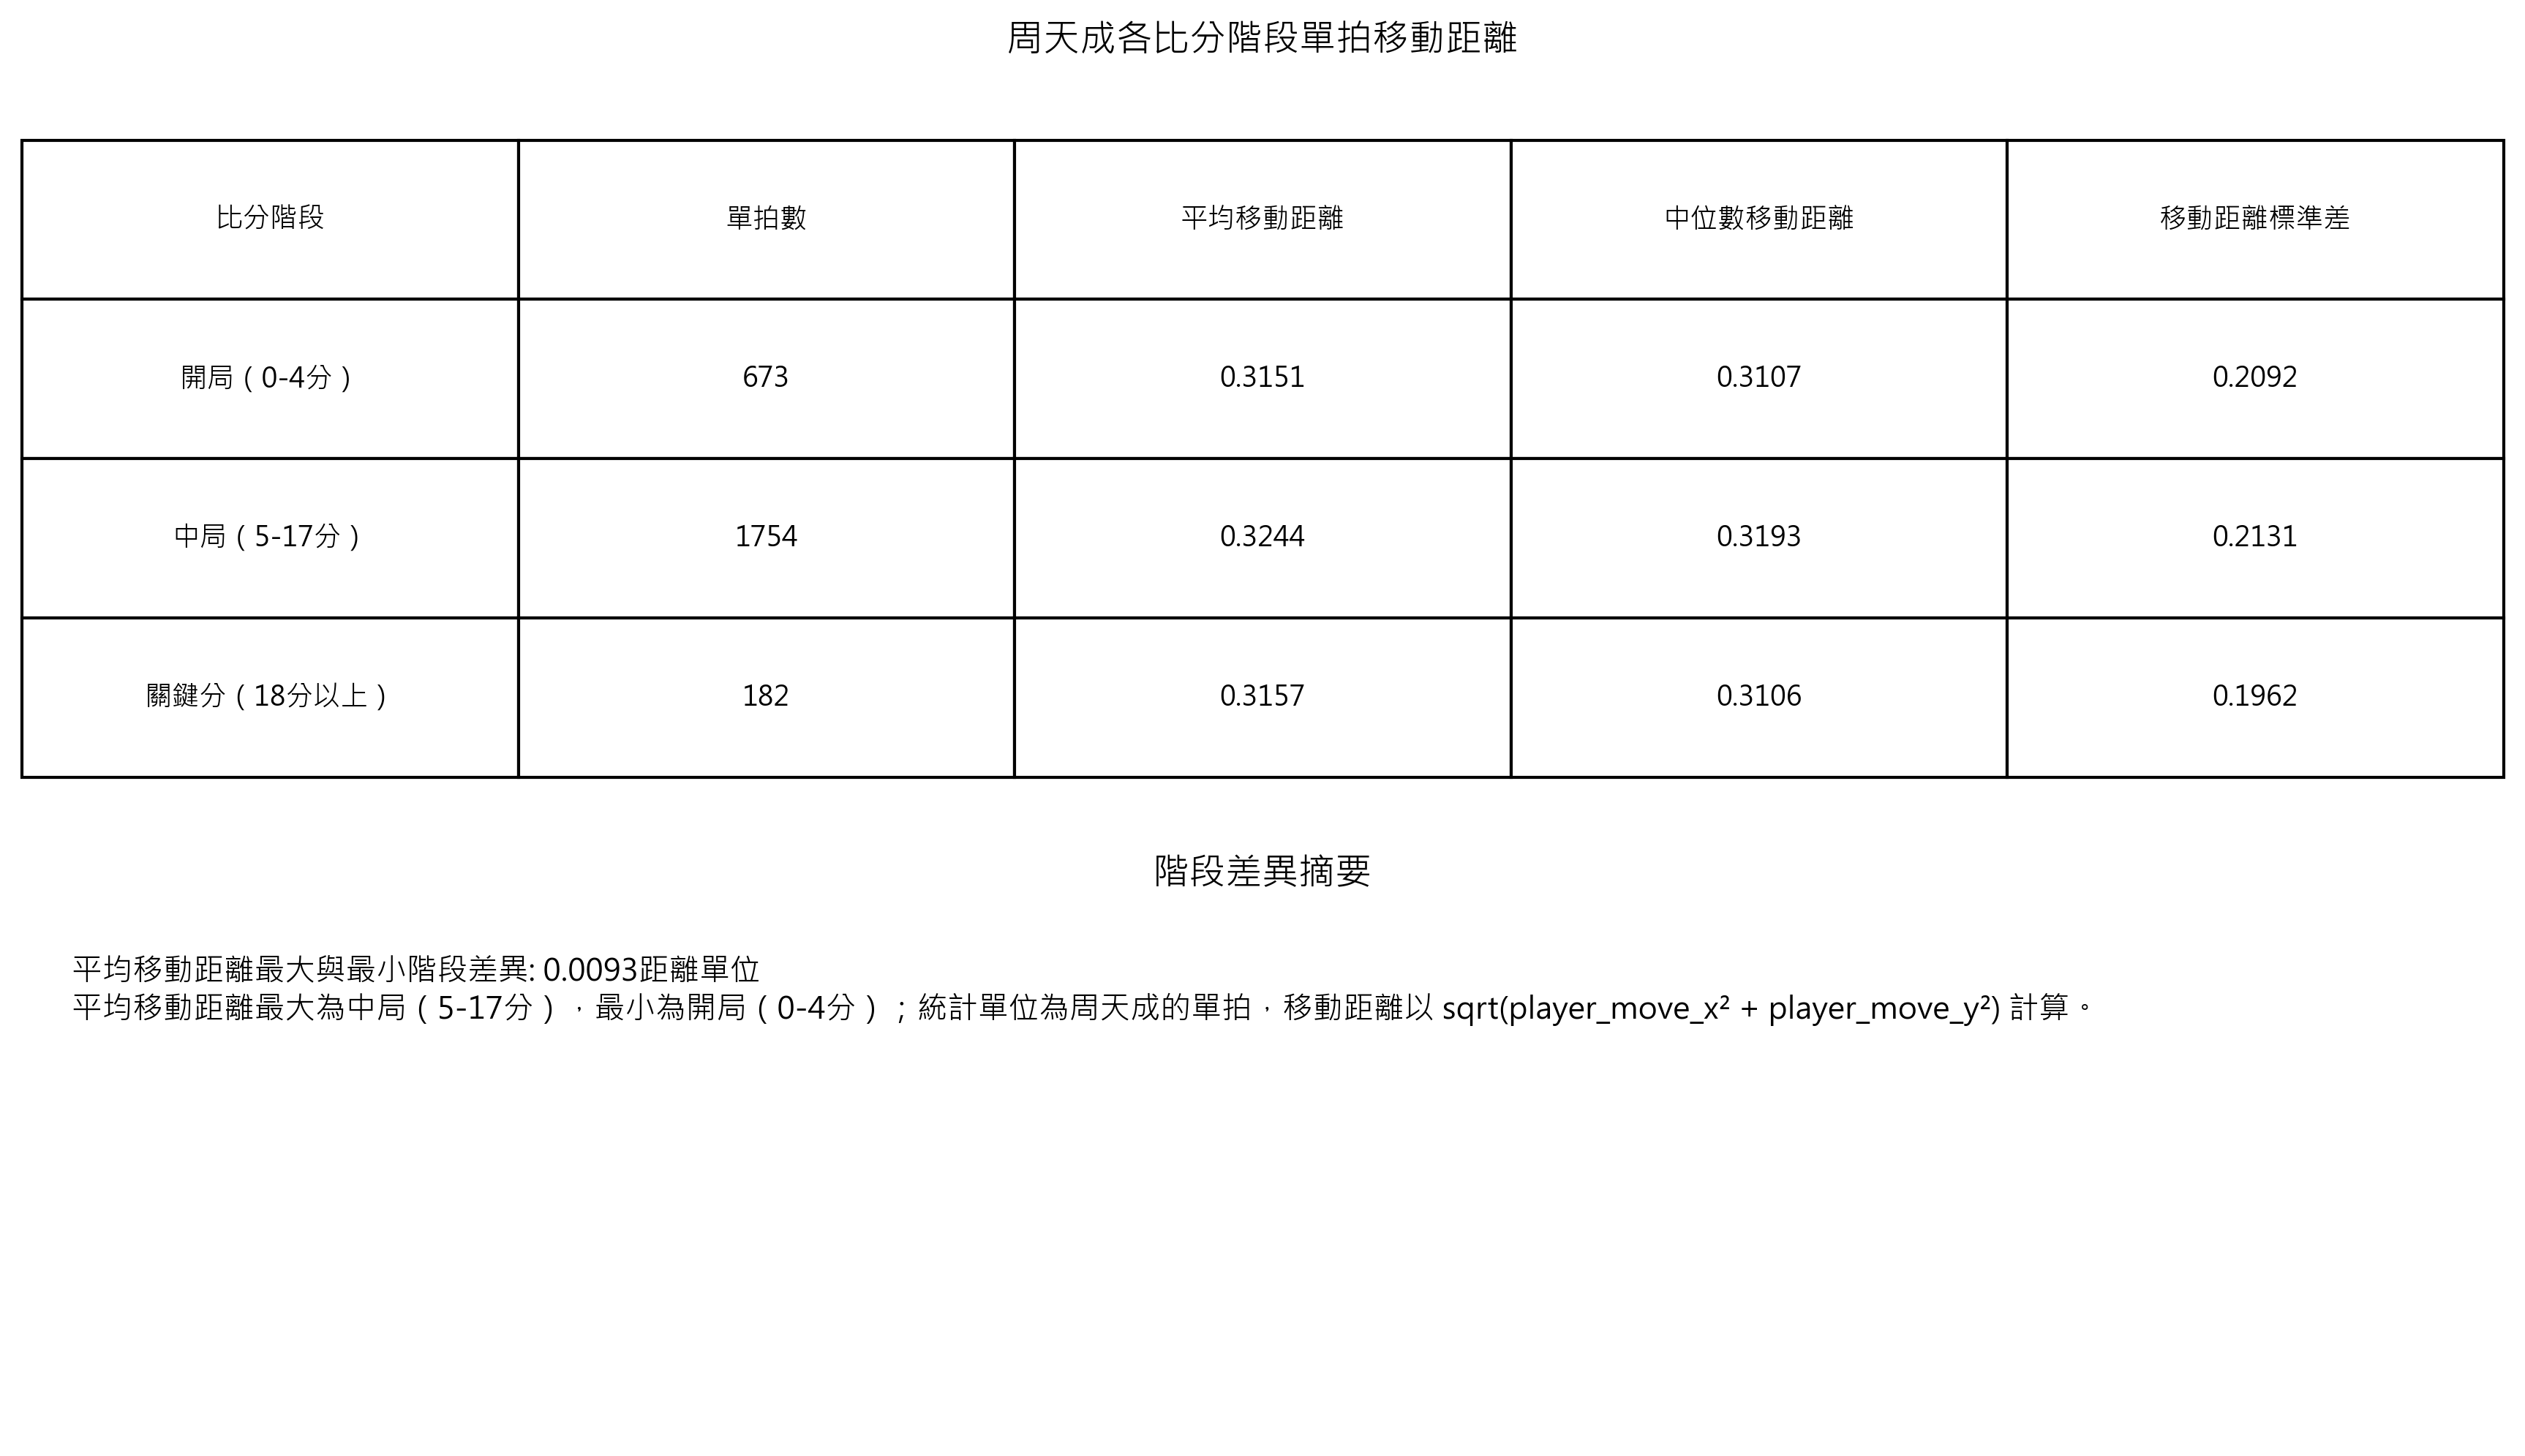

In [ ]:
required_cols = [
    "player", "CHOU Tien Chen_score",
    "player_move_x", "player_move_y"
]

if len(df) == 0:
    table_payload = {
        "columns": ["比分階段", "單拍數", "平均移動距離", "中位數移動距離", "移動距離標準差"],
        "rows": []
    }
    text_payload = {
        "label": "資料狀態",
        "value": "無資料",
        "unit": "",
        "note": "df 為空，無法分析周天成三個比分階段的移動距離。"
    }
else:
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        table_payload = {
            "columns": ["資料狀態", "缺少欄位"],
            "rows": [["無法分析", "、".join(missing_cols)]]
        }
        text_payload = {
            "label": "資料狀態",
            "value": "欄位不足",
            "unit": "",
            "note": "缺少分析所需欄位，無法計算移動距離。"
        }
    else:
        movement_df = df.loc[
            df["player"].eq("CHOU Tien Chen"),
            required_cols
        ].copy()

        movement_df = movement_df.dropna(
            subset=[
                "CHOU Tien Chen_score",
                "player_move_x",
                "player_move_y"
            ]
        )

        movement_df["CHOU Tien Chen_score"] = pd.to_numeric(
            movement_df["CHOU Tien Chen_score"],
            errors="coerce"
        )
        movement_df["player_move_x"] = pd.to_numeric(
            movement_df["player_move_x"],
            errors="coerce"
        )
        movement_df["player_move_y"] = pd.to_numeric(
            movement_df["player_move_y"],
            errors="coerce"
        )
        movement_df = movement_df.dropna(
            subset=[
                "CHOU Tien Chen_score",
                "player_move_x",
                "player_move_y"
            ]
        )

        movement_df["移動距離"] = (
            movement_df["player_move_x"] ** 2
            + movement_df["player_move_y"] ** 2
        ) ** 0.5

        movement_df["比分階段"] = pd.cut(
            movement_df["CHOU Tien Chen_score"],
            bins=[-float("inf"), 4, 17, float("inf")],
            labels=["開局（0-4分）", "中局（5-17分）", "關鍵分（18分以上）"],
            right=True
        )

        stage_order = [
            "開局（0-4分）",
            "中局（5-17分）",
            "關鍵分（18分以上）"
        ]

        summary = (
            movement_df.groupby(
                "比分階段",
                observed=False
            )["移動距離"]
            .agg(
                單拍數="count",
                平均移動距離="mean",
                中位數移動距離="median",
                移動距離標準差=lambda s: s.std(ddof=0)
            )
            .reindex(stage_order)
            .reset_index()
        )

        summary["單拍數"] = summary["單拍數"].fillna(0).astype(int)
        numeric_cols = [
            "平均移動距離",
            "中位數移動距離",
            "移動距離標準差"
        ]
        summary[numeric_cols] = summary[numeric_cols].round(4)

        table_payload = {
            "columns": [
                "比分階段",
                "單拍數",
                "平均移動距離",
                "中位數移動距離",
                "移動距離標準差"
            ],
            "rows": summary[
                [
                    "比分階段",
                    "單拍數",
                    "平均移動距離",
                    "中位數移動距離",
                    "移動距離標準差"
                ]
            ].where(summary.notna(), None).values.tolist()
        }

        valid_summary = summary.dropna(subset=["平均移動距離"])

        if len(valid_summary) > 0:
            max_row = valid_summary.loc[
                valid_summary["平均移動距離"].idxmax()
            ]
            min_row = valid_summary.loc[
                valid_summary["平均移動距離"].idxmin()
            ]
            mean_difference = round(
                float(
                    max_row["平均移動距離"]
                    - min_row["平均移動距離"]
                ),
                4
            )
            text_payload = {
                "label": "平均移動距離最大與最小階段差異",
                "value": mean_difference,
                "unit": "距離單位",
                "note": (
                    f"平均移動距離最大為{max_row['比分階段']}，"
                    f"最小為{min_row['比分階段']}；"
                    "統計單位為周天成的單拍，移動距離以 "
                    "sqrt(player_move_x² + player_move_y²) 計算。"
                )
            }
        else:
            text_payload = {
                "label": "資料狀態",
                "value": "無有效資料",
                "unit": "",
                "note": "沒有可用的周天成比分與移動座標資料。"
            }

payload = {
    "items": [
        {
            "kind": "table",
            "payload": table_payload,
            "title": "周天成各比分階段單拍移動距離"
        },
        {
            "kind": "text",
            "payload": text_payload,
            "title": "階段差異摘要"
        }
    ]
}

template_output = render_output(
    kind="composite",
    payload=payload,
    title="周天成開局、中局與關鍵分移動距離比較"
)


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 22
**問題**: 分析周天成在不同比分階段(開局:0-4分,中局:5-17分,關鍵分:18分以上)中，使用不同球種的頻率變化趨勢
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：table, line；renderer：renderer / completed


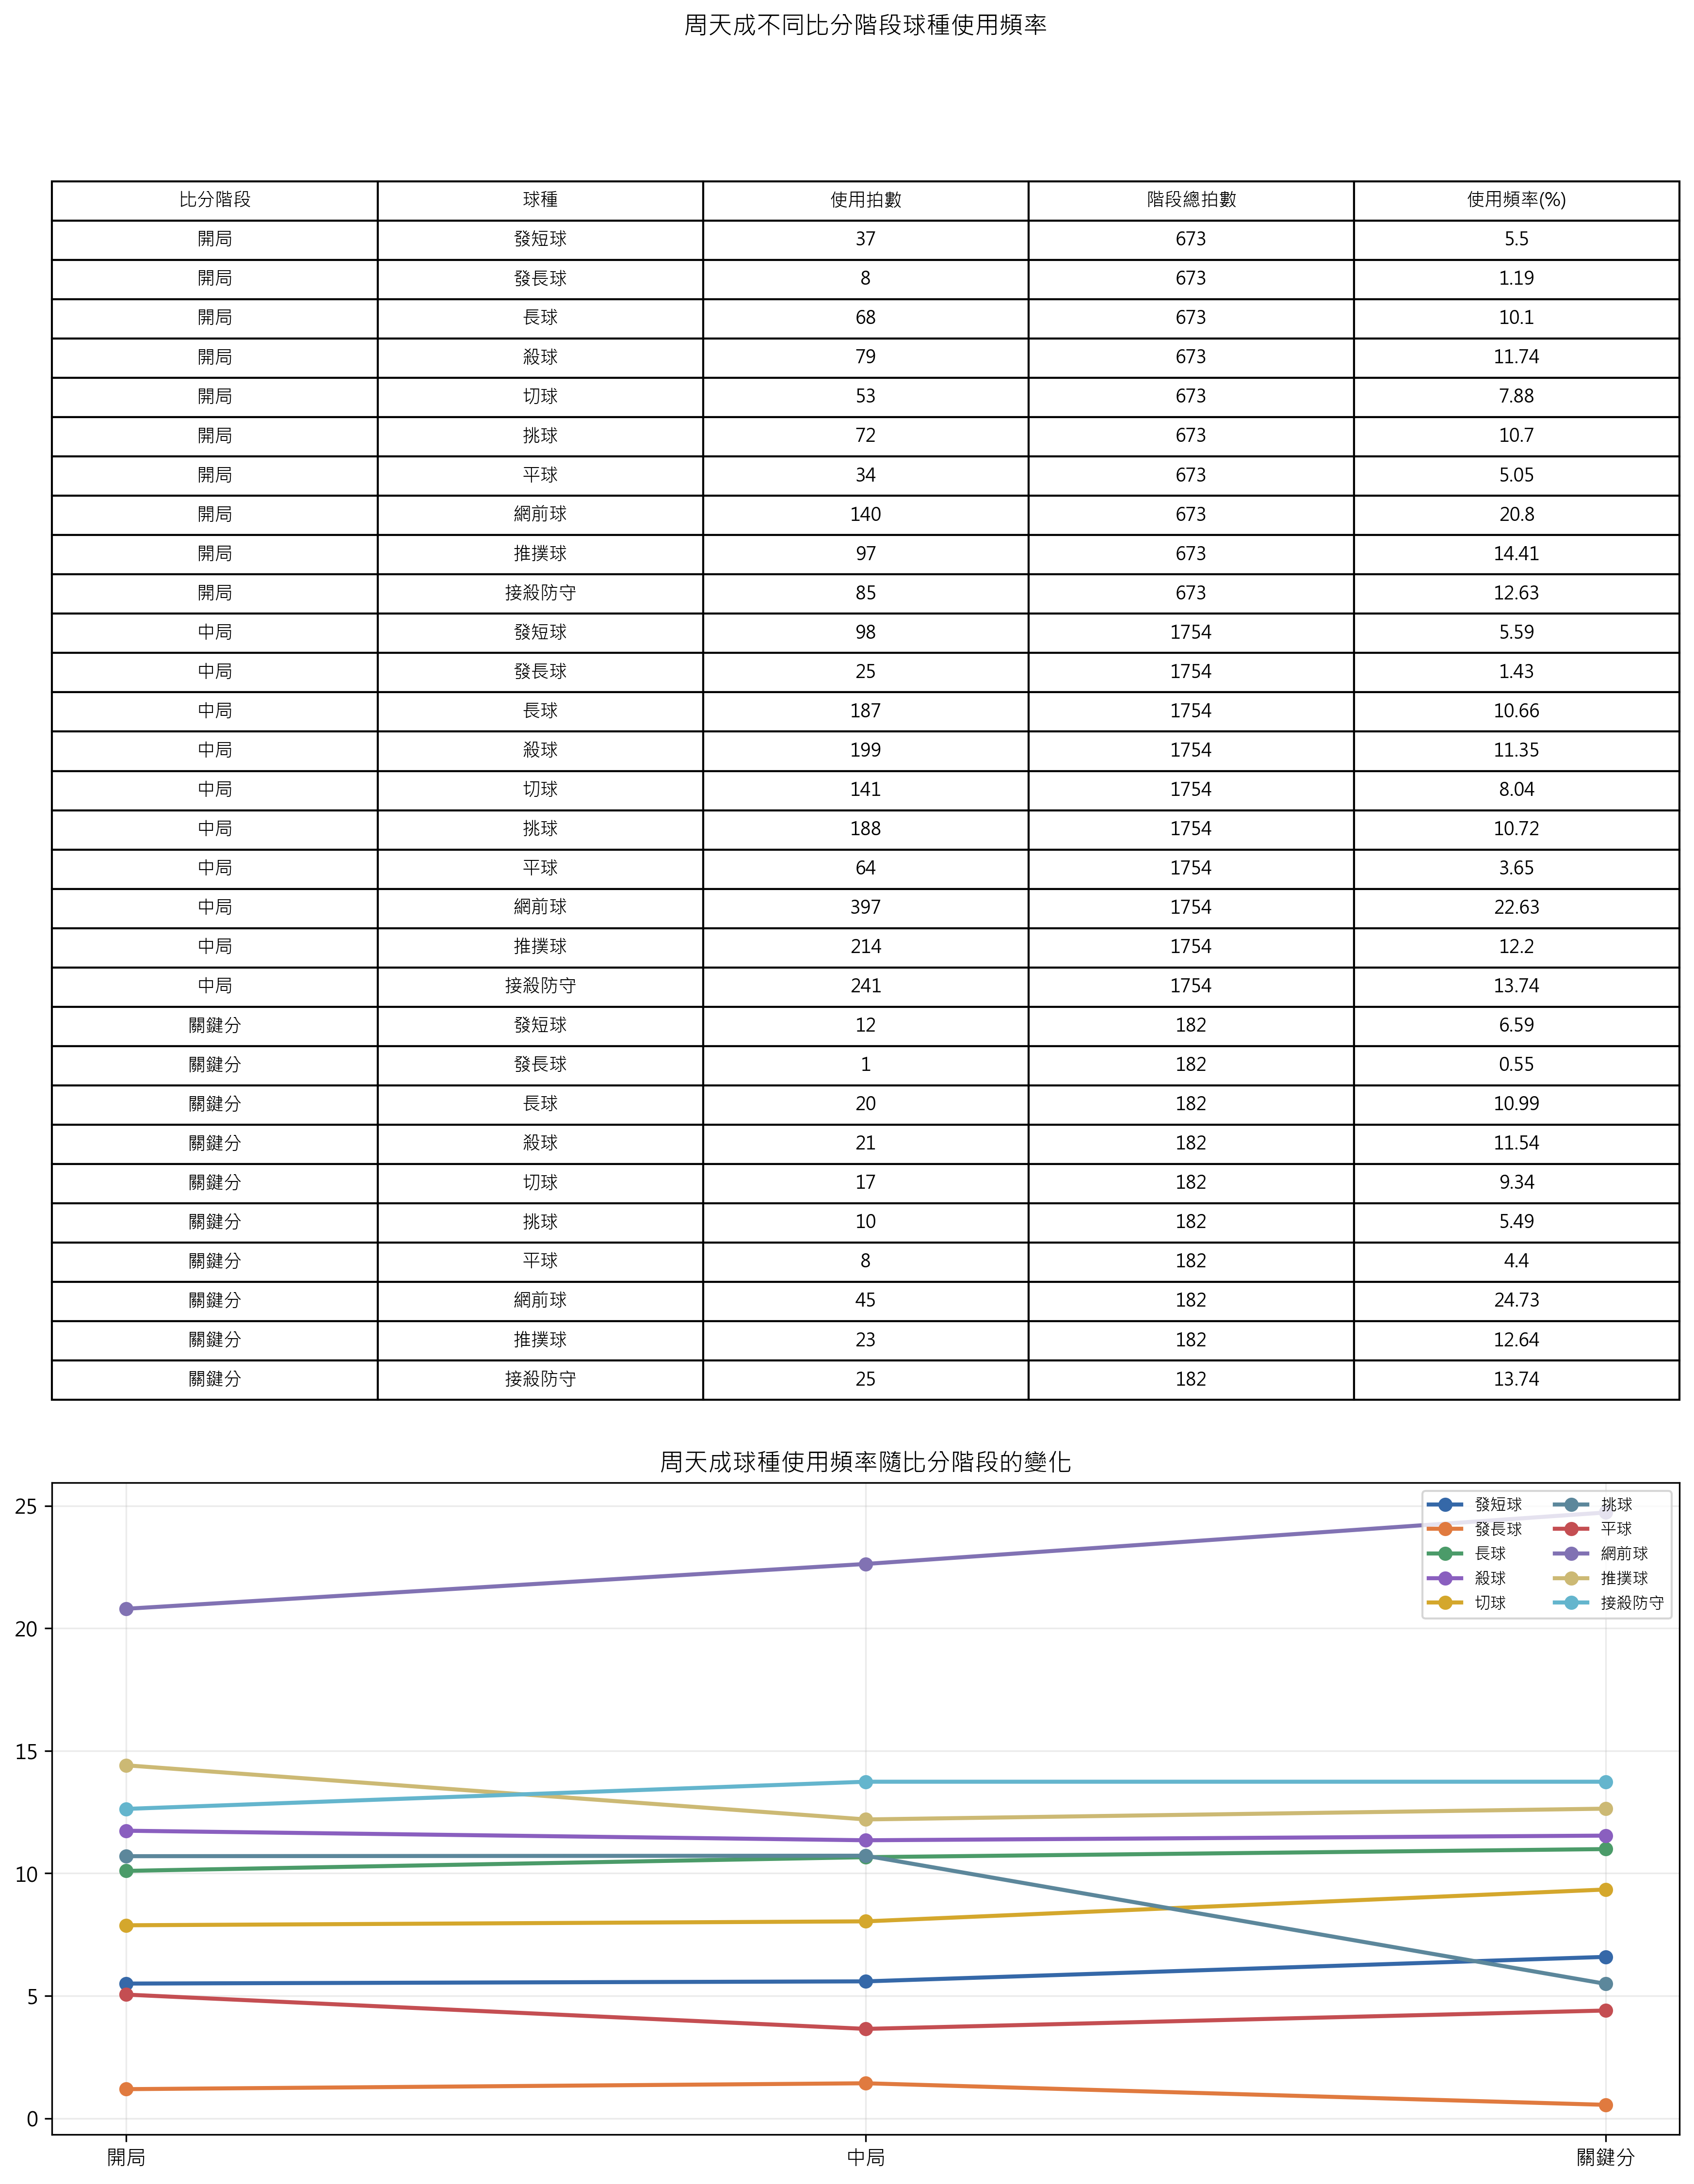

In [ ]:
required_cols = ['player', 'CHOU Tien Chen_score', 'type']
missing_cols = [col for col in required_cols if col not in df.columns]

if len(df) == 0:
    print("資料為空，無法分析。")
elif missing_cols:
    print(f"缺少必要欄位：{missing_cols}")
else:
    phase_order = ['開局', '中局', '關鍵分']
    shot_order = ['發短球', '發長球', '長球', '殺球', '切球',
                  '挑球', '平球', '網前球', '推撲球', '接殺防守', '接不到']

    analysis_df = df.loc[
        df['player'].eq('CHOU Tien Chen'),
        ['CHOU Tien Chen_score', 'type']
    ].dropna(subset=['CHOU Tien Chen_score', 'type']).copy()

    analysis_df['比分階段'] = pd.cut(
        analysis_df['CHOU Tien Chen_score'],
        bins=[-float('inf'), 4, 17, float('inf')],
        labels=phase_order,
        right=True
    )

    analysis_df = analysis_df.dropna(subset=['比分階段'])
    analysis_df['比分階段'] = pd.Categorical(
        analysis_df['比分階段'],
        categories=phase_order,
        ordered=True
    )

    phase_totals = (
        analysis_df.groupby('比分階段', observed=False)
        .size()
        .reindex(phase_order, fill_value=0)
        .rename('階段總拍數')
    )

    summary = (
        analysis_df.groupby(['比分階段', 'type'], observed=False)
        .size()
        .rename('使用拍數')
        .reset_index()
    )

    summary['階段總拍數'] = summary['比分階段'].map(phase_totals).astype(int)
    summary['使用頻率(%)'] = (
        summary['使用拍數']
        .div(summary['階段總拍數'].replace(0, pd.NA))
        .mul(100)
        .fillna(0)
        .round(2)
    )

    summary = summary.rename(columns={'type': '球種'})
    summary['球種'] = summary['球種'].astype(str)
    summary['球種排序'] = summary['球種'].map(
        {shot: idx for idx, shot in enumerate(shot_order)}
    ).fillna(len(shot_order))
    summary = summary.sort_values(
        ['比分階段', '球種排序', '球種']
    ).drop(columns='球種排序')

    table_rows = [
        [
            row['比分階段'],
            row['球種'],
            int(row['使用拍數']),
            int(row['階段總拍數']),
            float(row['使用頻率(%)'])
        ]
        for _, row in summary.iterrows()
    ]

    frequency_pivot = (
        summary.pivot(
            index='比分階段',
            columns='球種',
            values='使用頻率(%)'
        )
        .reindex(index=phase_order)
        .fillna(0)
    )

    available_shots = [
        shot for shot in shot_order
        if shot in frequency_pivot.columns
    ]
    available_shots += [
        shot for shot in frequency_pivot.columns
        if shot not in available_shots
    ]

    line_series = [
        {
            'name': str(shot),
            'labels': phase_order,
            'values': [
                float(frequency_pivot.loc[phase, shot])
                for phase in phase_order
            ]
        }
        for shot in available_shots
    ]

    payload = {
        'items': [
            {
                'kind': 'table',
                'title': '周天成不同比分階段球種使用頻率',
                'payload': {
                    'columns': ['比分階段', '球種', '使用拍數', '階段總拍數', '使用頻率(%)'],
                    'rows': table_rows
                }
            },
            {
                'kind': 'line',
                'title': '周天成球種使用頻率隨比分階段的變化',
                'payload': {
                    'series': line_series
                }
            }
        ]
    }

    template_output = render_output(
        kind='composite',
        payload=payload,
        title='周天成不同比分階段的球種使用頻率分析'
    )


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 25
**問題**: 當對手靠球場兩側時，周天成較常讓球落點到哪些區域？繪製熱區圖。
> **使用的資料欄位群組**: `game_structure, coordinates, player_location`


### 流程摘要

- 場地資訊：完整場地資訊（判定來源：llm+semantic_guard）
- 輸出：text, heatmap；renderer：renderer / completed


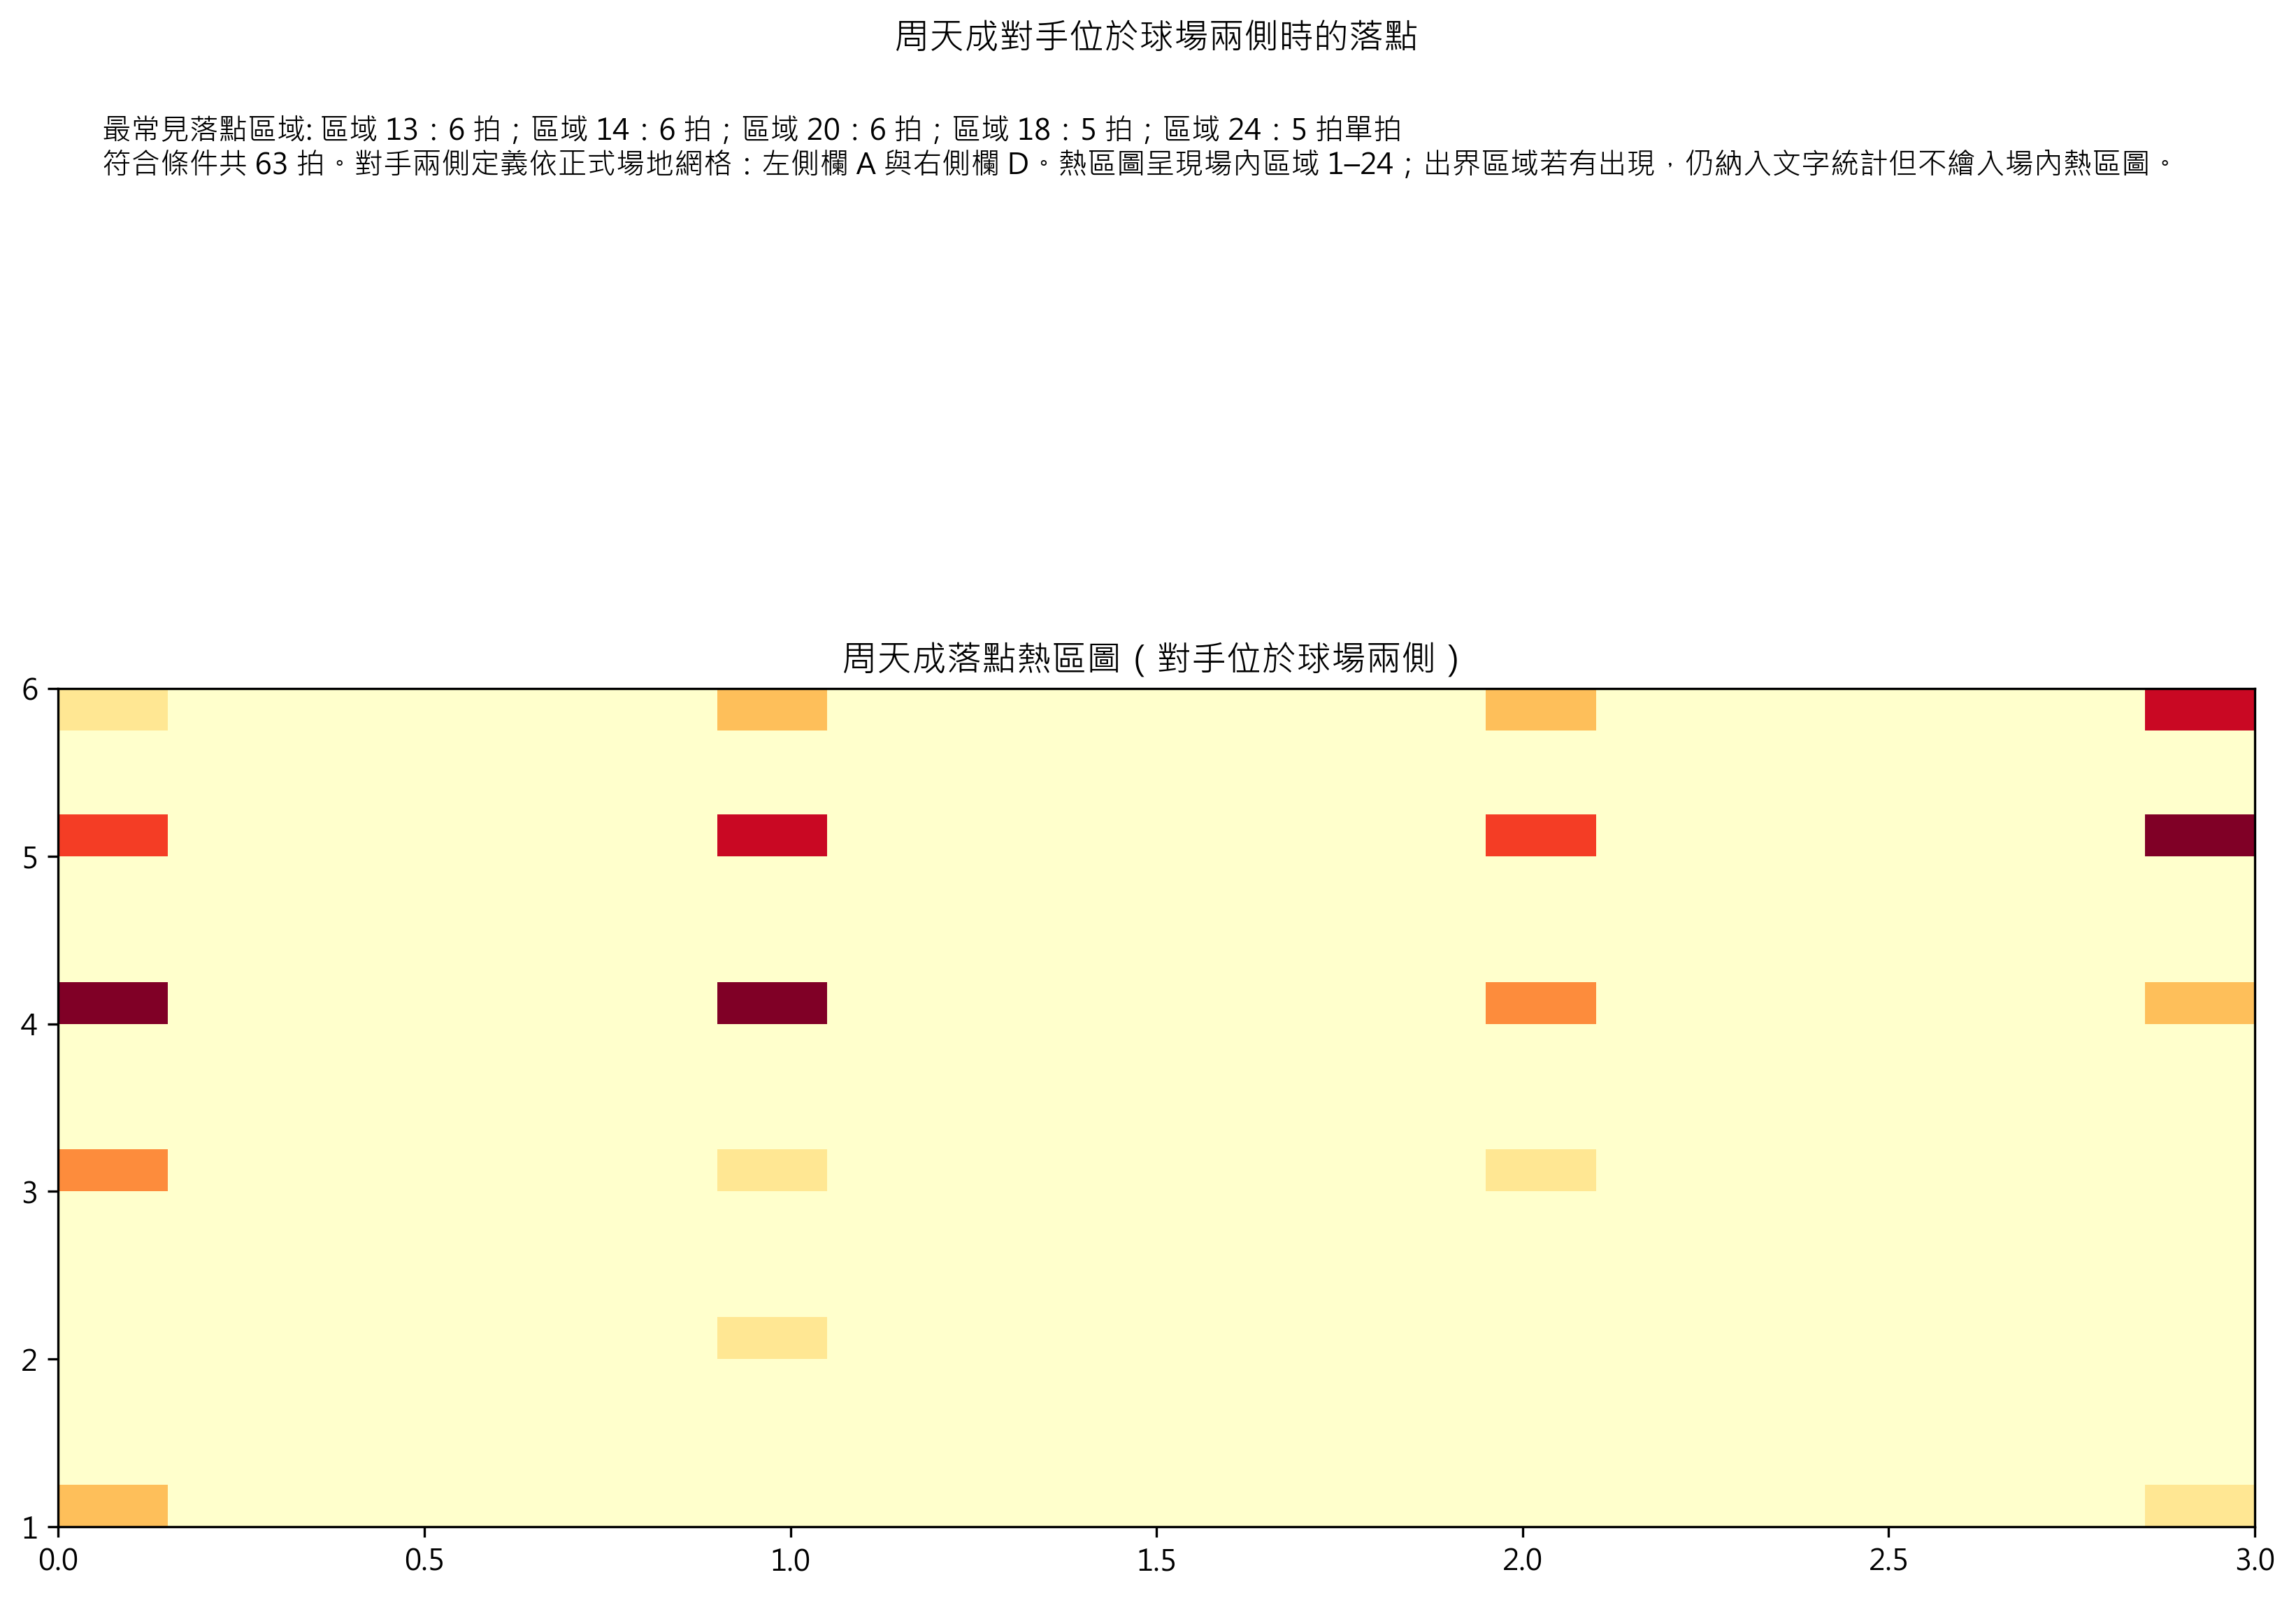

In [ ]:
required_cols = [
    "match_id", "set", "rally", "ball_round", "player",
    "opponent_location_area", "landing_area"
]

if len(df) == 0:
    payload = {
        "items": [{
            "kind": "text",
            "payload": {
                "label": "分析結果",
                "value": "資料為空",
                "unit": "",
                "note": "無法進行統計。"
            },
            "title": "周天成對手位於球場兩側時的落點"
        }]
    }
else:
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        payload = {
            "items": [{
                "kind": "text",
                "payload": {
                    "label": "欄位不足",
                    "value": "、".join(missing_cols),
                    "unit": "",
                    "note": "缺少必要欄位，無法完成分析。"
                },
                "title": "周天成對手位於球場兩側時的落點"
            }]
        }
    else:
        work = df[required_cols].copy()
        work = work.dropna(subset=[
            "player", "opponent_location_area", "landing_area"
        ])

        left_side_zones = [1, 5, 9, 13, 17, 21]
        right_side_zones = [4, 8, 12, 16, 20, 24]
        opponent_side_zones = left_side_zones + right_side_zones

        filtered = work[
            (work["player"] == "CHOU Tien Chen") &
            (work["opponent_location_area"].isin(opponent_side_zones))
        ].copy()

        landing_counts = (
            filtered.groupby("landing_area", as_index=False)
            .size()
            .rename(columns={"size": "單拍數"})
            .sort_values(["單拍數", "landing_area"], ascending=[False, True])
        )

        if len(landing_counts) == 0:
            payload = {
                "items": [{
                    "kind": "text",
                    "payload": {
                        "label": "分析結果",
                        "value": "沒有符合條件的單拍資料",
                        "unit": "",
                        "note": (
                            "條件：擊球者為 CHOU Tien Chen，且對手站在正式球場網格的左右邊界欄位；"
                            "左側區域為 1、5、9、13、17、21，右側區域為 4、8、12、16、20、24。"
                        )
                    },
                    "title": "周天成對手位於球場兩側時的落點"
                }]
            }
        else:
            top_rows = landing_counts.head(5)
            top_text = "；".join(
                f"區域 {int(row['landing_area'])}：{int(row['單拍數'])} 拍"
                for _, row in top_rows.iterrows()
            )

            court_zone_coordinates = {
                1: (0, 1), 2: (1, 1), 3: (2, 1), 4: (3, 1),
                5: (0, 2), 6: (1, 2), 7: (2, 2), 8: (3, 2),
                9: (0, 3), 10: (1, 3), 11: (2, 3), 12: (3, 3),
                13: (0, 4), 14: (1, 4), 15: (2, 4), 16: (3, 4),
                17: (0, 5), 18: (1, 5), 19: (2, 5), 20: (3, 5),
                21: (0, 6), 22: (1, 6), 23: (2, 6), 24: (3, 6)
            }

            heatmap_rows = []
            for zone, (x, y) in court_zone_coordinates.items():
                count = landing_counts.loc[
                    landing_counts["landing_area"] == zone, "單拍數"
                ]
                heatmap_rows.append({
                    "x": x,
                    "y": y,
                    "weights": int(count.iloc[0]) if len(count) > 0 else 0
                })

            heatmap_payload = {
                "x": [row["x"] for row in heatmap_rows],
                "y": [row["y"] for row in heatmap_rows],
                "weights": [row["weights"] for row in heatmap_rows]
            }

            payload = {
                "items": [
                    {
                        "kind": "text",
                        "payload": {
                            "label": "最常見落點區域",
                            "value": top_text,
                            "unit": "單拍",
                            "note": (
                                f"符合條件共 {len(filtered)} 拍。"
                                "對手兩側定義依正式場地網格：左側欄 A 與右側欄 D。"
                                "熱區圖呈現場內區域 1–24；出界區域若有出現，仍納入文字統計但不繪入場內熱區圖。"
                            )
                        },
                        "title": "周天成對手位於球場兩側時的落點"
                    },
                    {
                        "kind": "heatmap",
                        "payload": heatmap_payload,
                        "title": "周天成落點熱區圖（對手位於球場兩側）"
                    }
                ]
            }

template_output = render_output(
    kind="composite",
    payload=payload,
    title="周天成對手位於球場兩側時的落點分析"
)


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 30
**問題**: 周天成在比賽後段（第 2、3 局）移動距離與失誤率的關聯分析。
> **使用的資料欄位群組**: `game_structure, player_movement, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：text, scatter；renderer：renderer / completed


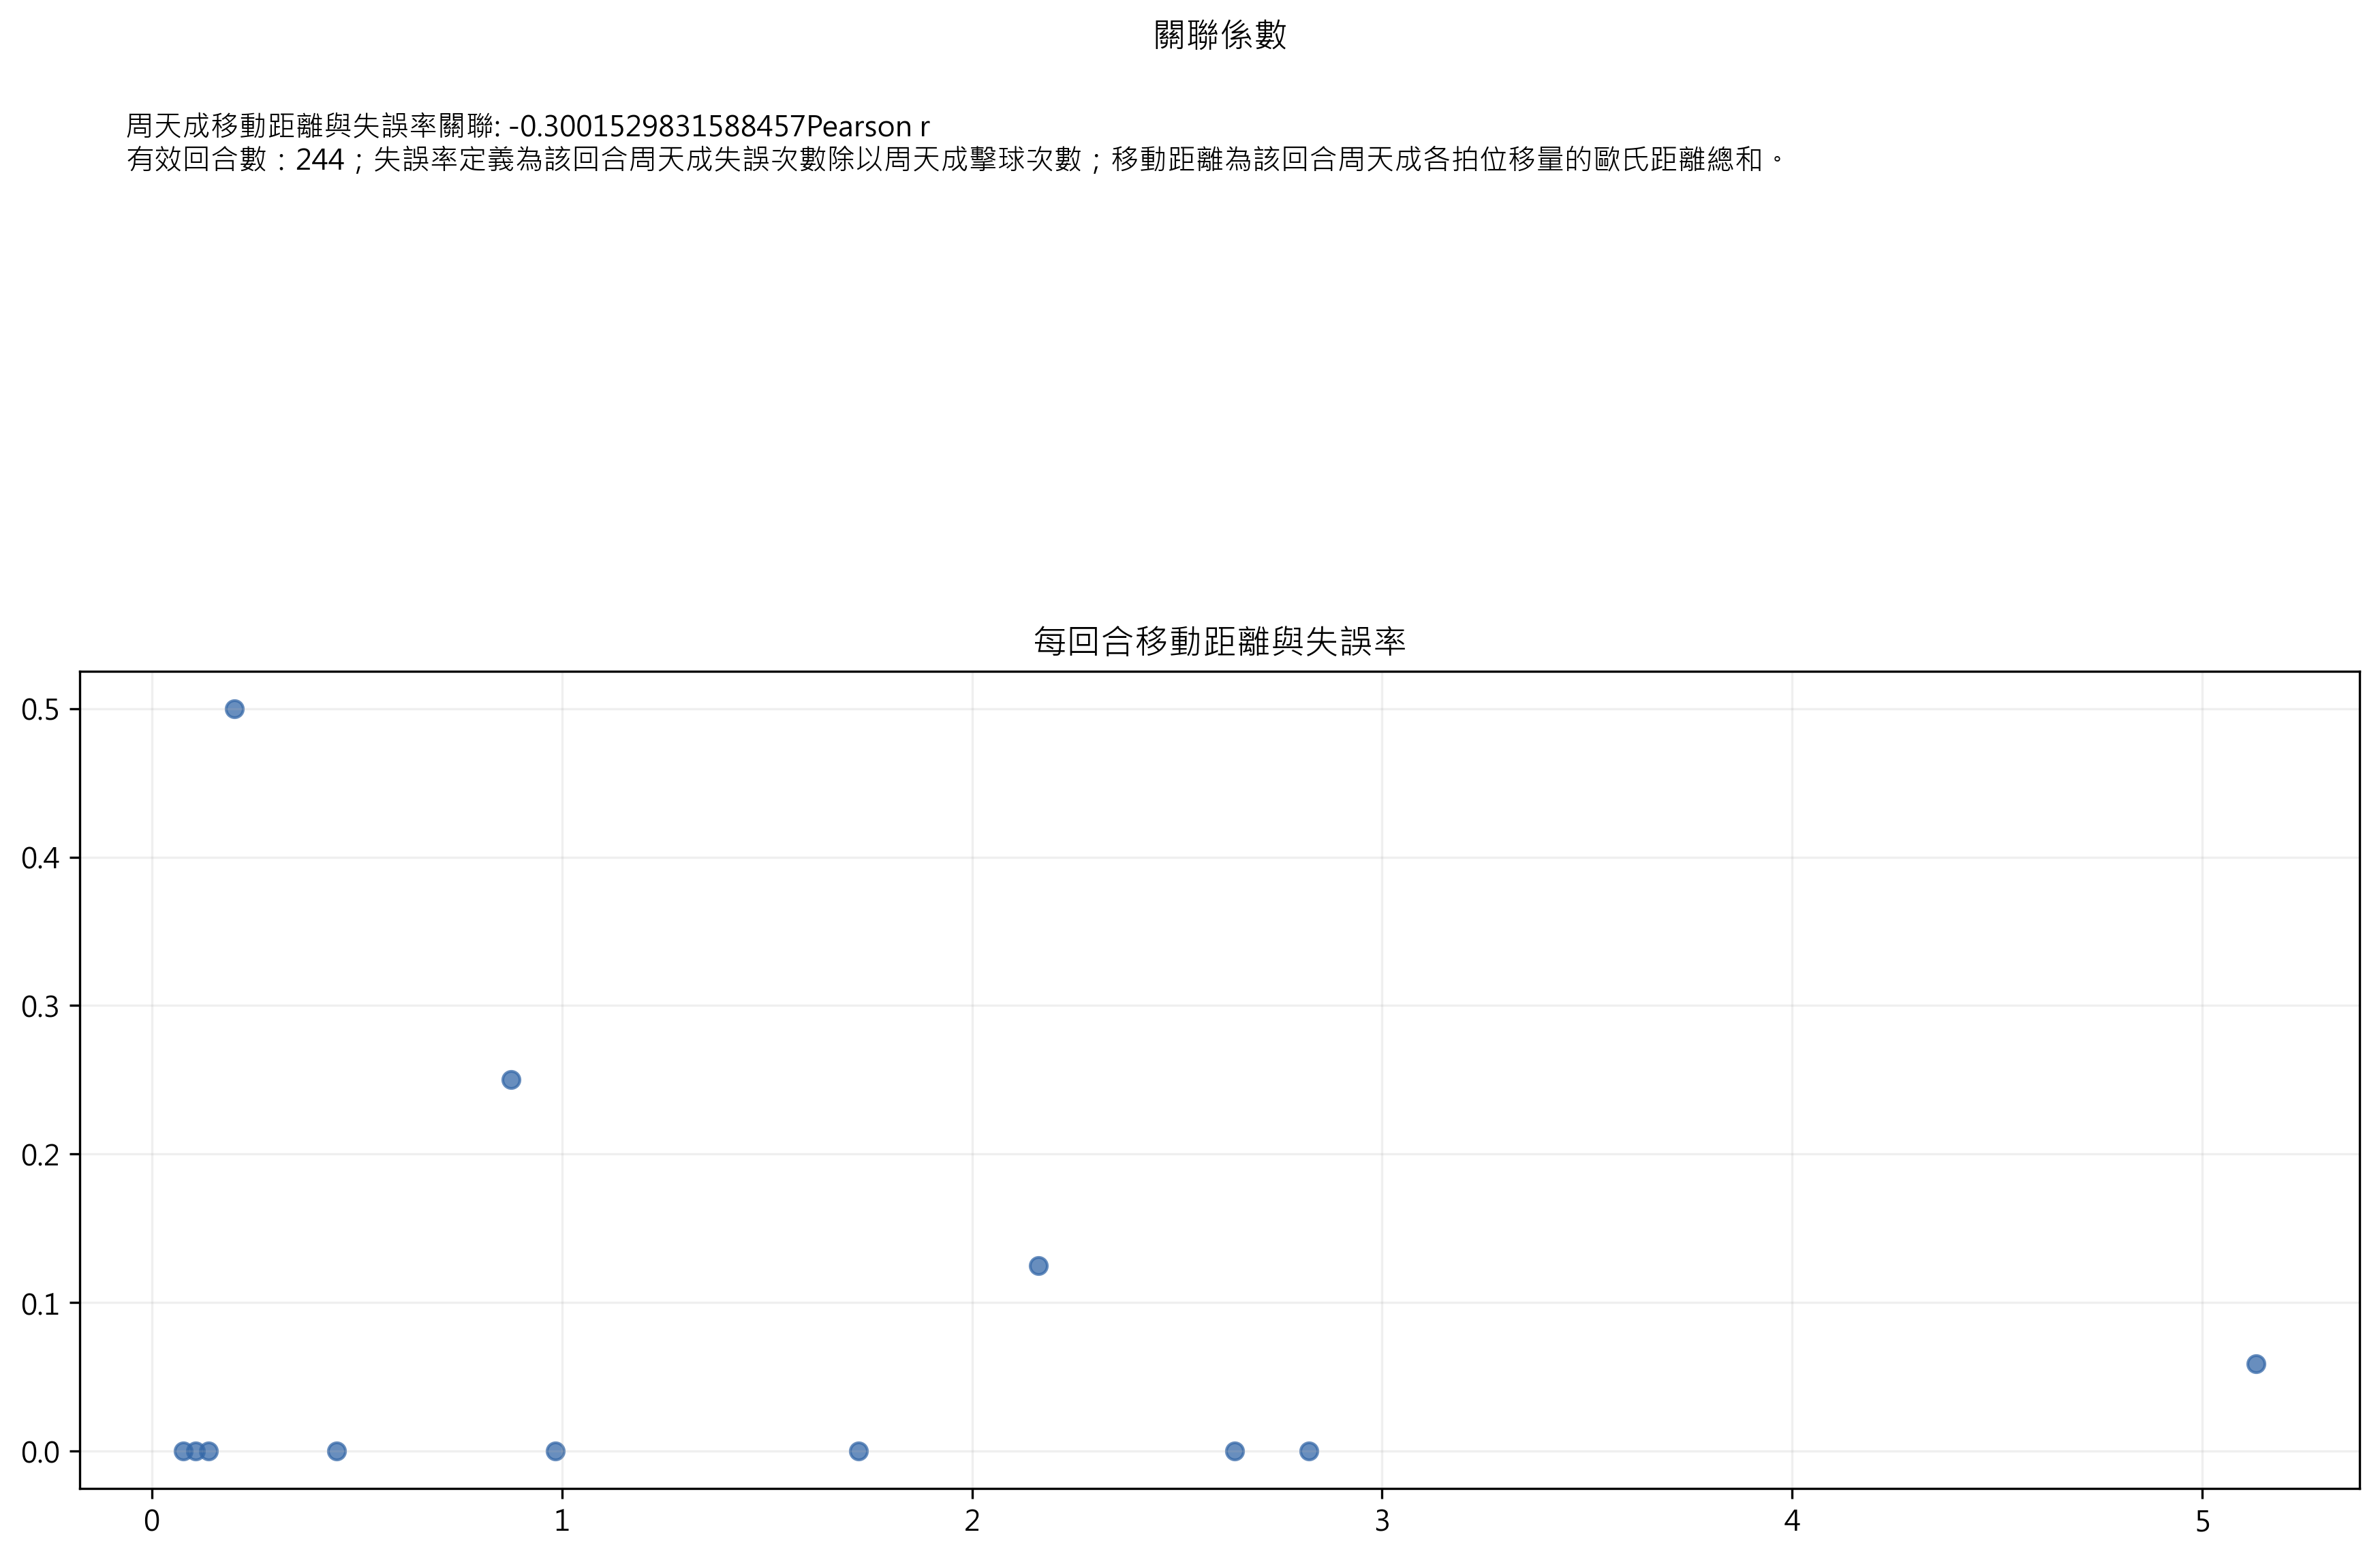

In [ ]:
required_columns = {
    "match_id", "set", "rally", "ball_round", "player", "opponent",
    "getpoint_player", "player_move_x", "player_move_y"
}

if len(df) == 0:
    payload = {
        "text": {
            "label": "周天成移動距離與失誤率關聯",
            "value": None,
            "unit": "Pearson r",
            "note": "資料為空，無法計算。"
        },
        "scatter": {
            "series": []
        }
    }
else:
    missing_columns = sorted(required_columns - set(df.columns))

    if missing_columns:
        payload = {
            "text": {
                "label": "周天成移動距離與失誤率關聯",
                "value": None,
                "unit": "Pearson r",
                "note": f"缺少必要欄位：{', '.join(missing_columns)}"
            },
            "scatter": {
                "series": []
            }
        }
    else:
        player_name = "CHOU Tien Chen"
        group_columns = ["match_id", "set", "rally"]

        work = df.loc[
            df["set"].isin([2, 3]),
            group_columns + [
                "ball_round", "player", "opponent", "getpoint_player",
                "player_move_x", "player_move_y"
            ]
        ].copy()

        work = work.sort_values(group_columns + ["ball_round"])

        if len(work) == 0:
            payload = {
                "text": {
                    "label": "周天成移動距離與失誤率關聯",
                    "value": None,
                    "unit": "Pearson r",
                    "note": "第 2、3 局沒有資料。"
                },
                "scatter": {
                    "series": []
                }
            }
        else:
            work["is_chou_shot"] = work["player"].eq(player_name)
            work["shot_movement_distance"] = (
                work["player_move_x"].pow(2) +
                work["player_move_y"].pow(2)
            ).pow(0.5)

            shot_summary = (
                work.groupby(group_columns, as_index=False)
                .agg(
                    chou_shot_count=("is_chou_shot", "sum"),
                    chou_movement_distance=(
                        "shot_movement_distance",
                        lambda s: s[work.loc[s.index, "is_chou_shot"]].sum()
                    )
                )
            )

            final_rows = (
                work.groupby(group_columns, as_index=False, sort=False)
                .tail(1)
                .copy()
            )

            final_rows["chou_error"] = (
                final_rows["player"].eq(player_name) &
                final_rows["getpoint_player"].eq(final_rows["opponent"])
            )

            rally_summary = final_rows[group_columns + ["chou_error"]].merge(
                shot_summary,
                on=group_columns,
                how="inner"
            )

            rally_summary = rally_summary.loc[
                rally_summary["chou_shot_count"] > 0
            ].copy()

            rally_summary["error_rate"] = (
                rally_summary["chou_error"].astype(int) /
                rally_summary["chou_shot_count"]
            )

            if len(rally_summary) < 2:
                correlation = None
                note = (
                    f"有效回合數：{len(rally_summary)}；"
                    "至少需要 2 個有效回合才能計算關聯。"
                )
                scatter_series = []
            else:
                correlation_value = rally_summary[
                    ["chou_movement_distance", "error_rate"]
                ].corr().iloc[0, 1]

                correlation = (
                    None
                    if pd.isna(correlation_value)
                    else float(correlation_value)
                )

                if correlation is None:
                    note = (
                        f"有效回合數：{len(rally_summary)}；"
                        "移動距離或失誤率沒有足夠變異，無法計算 Pearson 相關係數。"
                    )
                else:
                    note = (
                        f"有效回合數：{len(rally_summary)}；"
                        "失誤率定義為該回合周天成失誤次數除以周天成擊球次數；"
                        "移動距離為該回合周天成各拍位移量的歐氏距離總和。"
                    )

                plot_data = rally_summary.head(12)
                scatter_series = [{
                    "name": "第 2、3 局每回合",
                    "labels": [
                        round(float(x), 4)
                        for x in plot_data["chou_movement_distance"]
                    ],
                    "values": [
                        round(float(y), 4)
                        for y in plot_data["error_rate"]
                    ]
                }]

            payload = {
                "text": {
                    "label": "周天成移動距離與失誤率關聯",
                    "value": correlation,
                    "unit": "Pearson r",
                    "note": note
                },
                "scatter": {
                    "series": scatter_series
                }
            }

template_output = render_output(
    kind="composite",
    payload={
        "items": [
            {
                "kind": "text",
                "payload": payload["text"],
                "title": "關聯係數"
            },
            {
                "kind": "scatter",
                "payload": payload["scatter"],
                "title": "每回合移動距離與失誤率"
            }
        ]
    },
    title="周天成第 2、3 局移動距離與失誤率分析"
)


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 31
**問題**: 分析周天成使用殺球，對手都用什麼球種反擊，繪製圓餅圖
> **使用的資料欄位群組**: `game_structure, shot_type`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：pie, text；renderer：renderer / completed


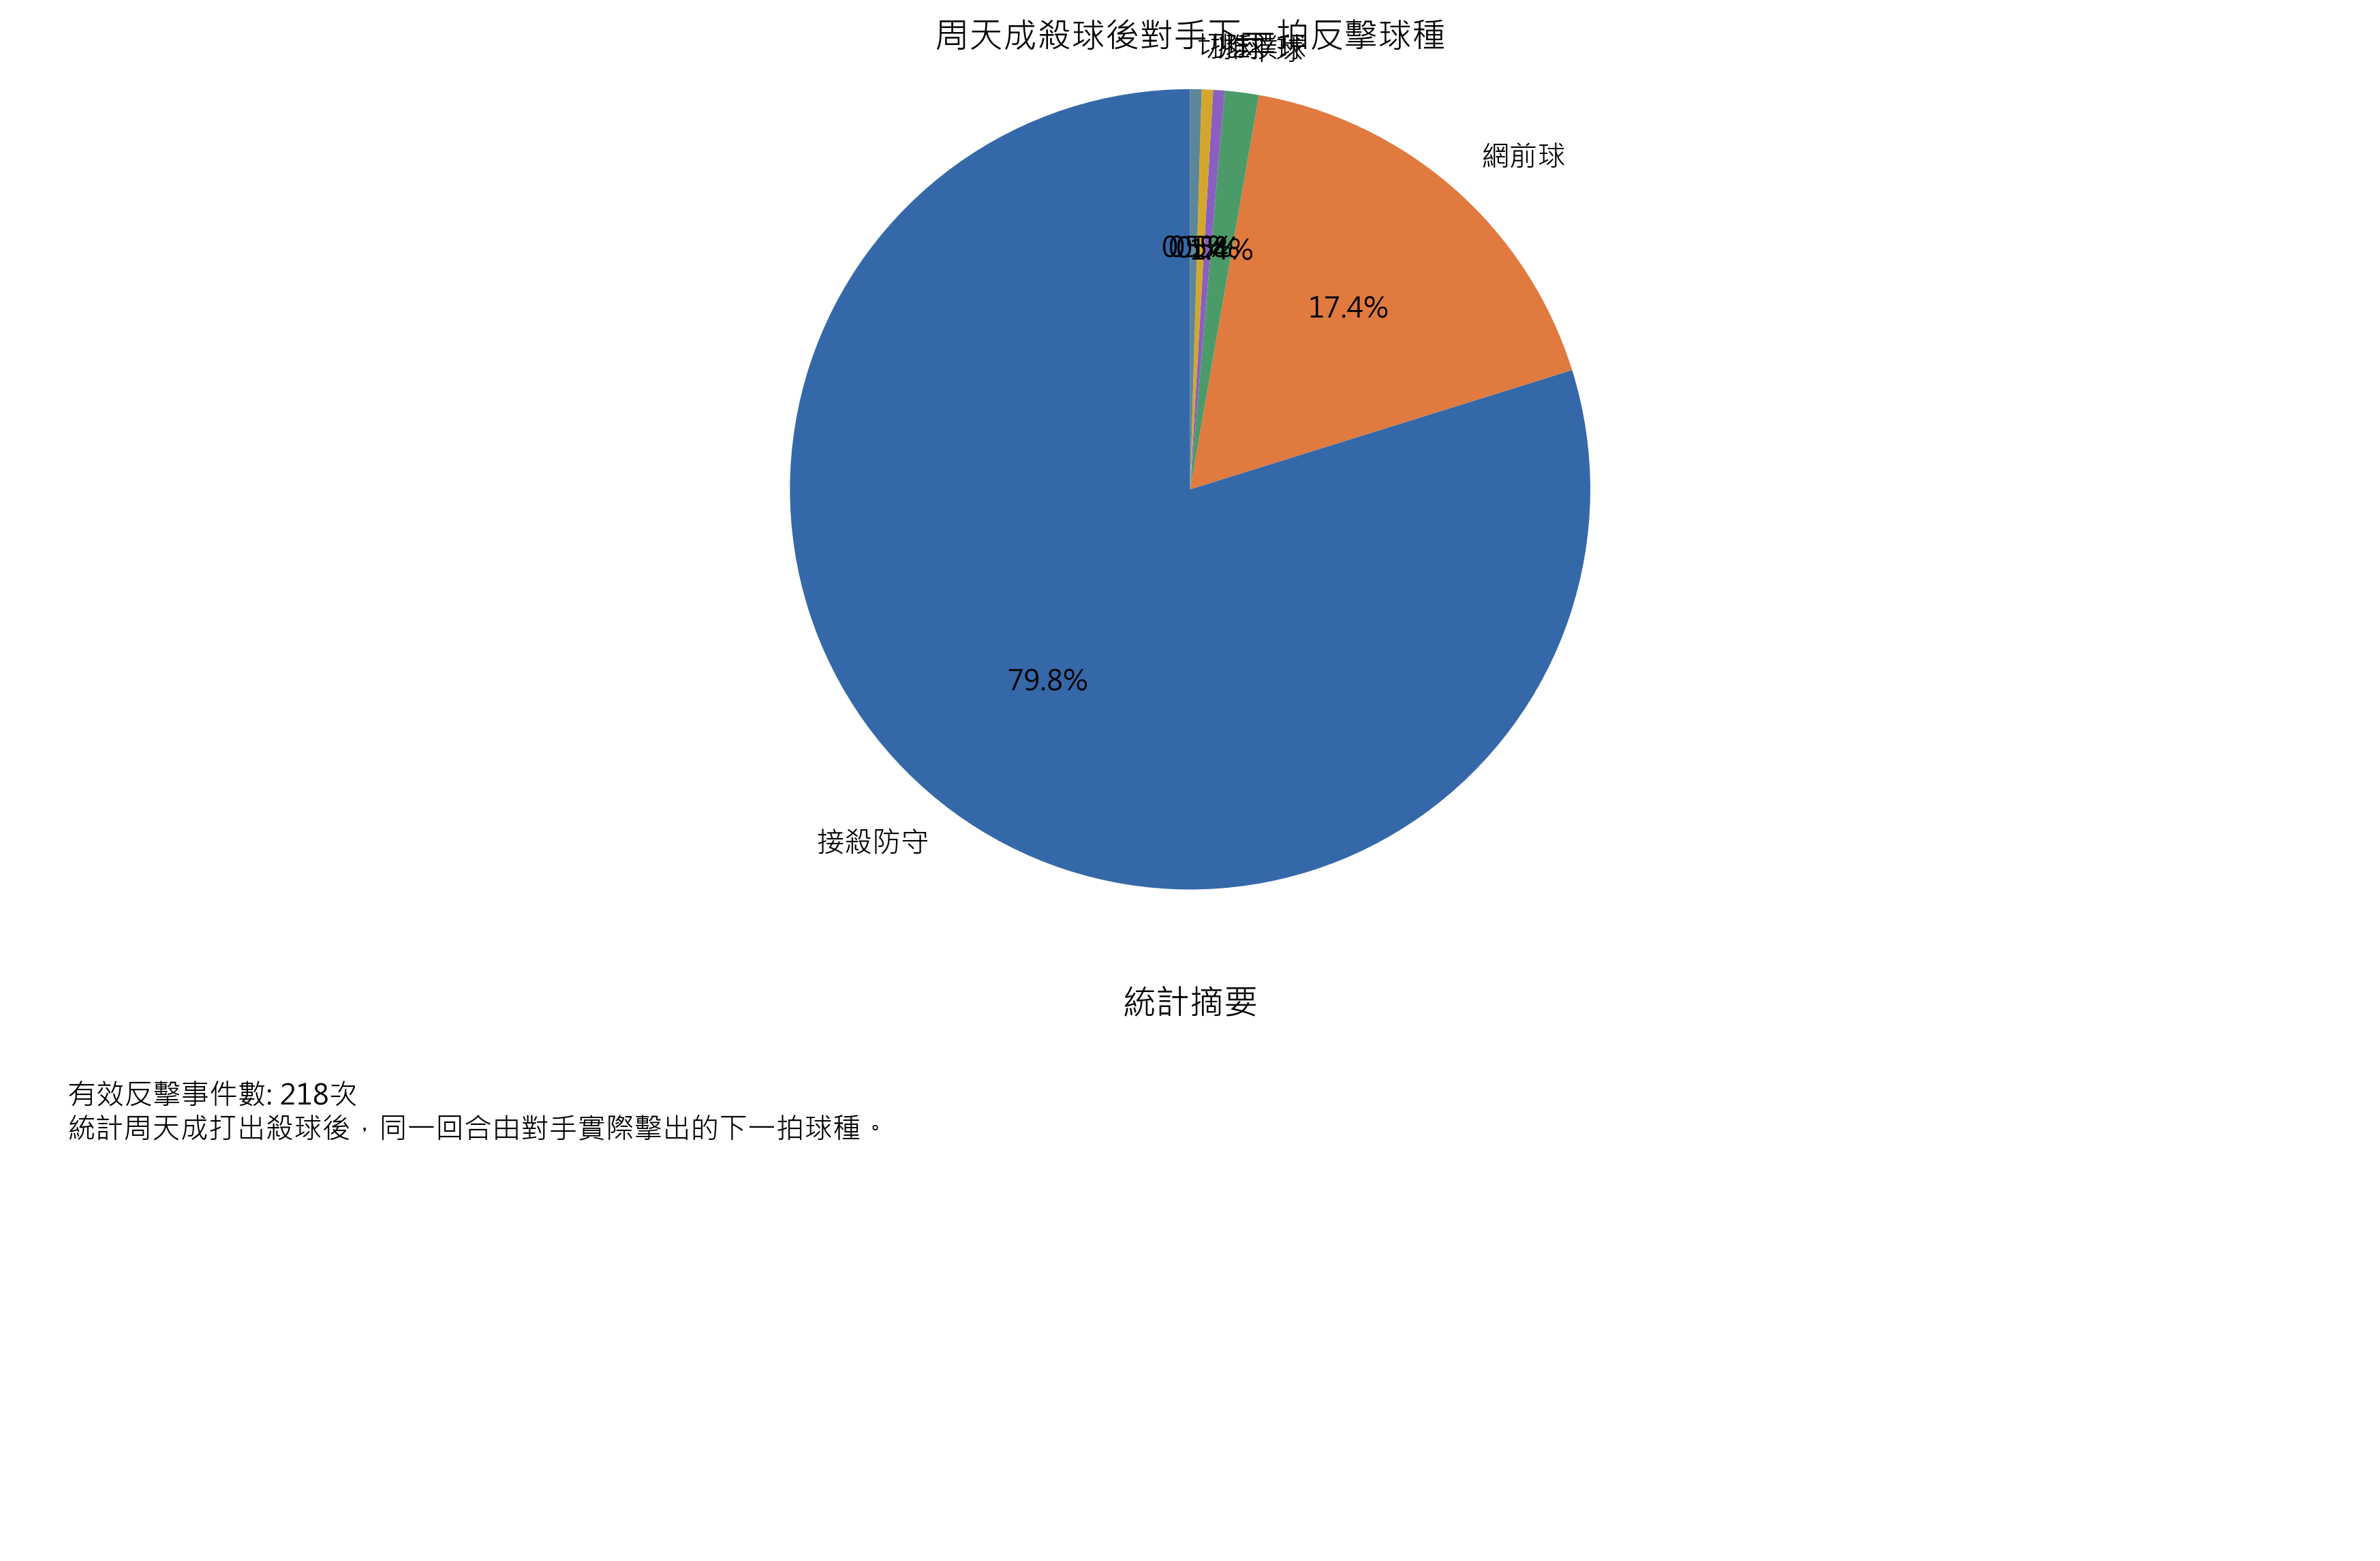

In [ ]:
required_columns = {"match_id", "set", "rally", "player", "opponent", "type"}
missing_columns = required_columns - set(df.columns)

if missing_columns:
    payload = {
        "items": [
            {
                "kind": "text",
                "payload": {
                    "label": "資料欄位不足",
                    "value": 0,
                    "unit": "欄位",
                    "note": f"缺少欄位：{', '.join(sorted(missing_columns))}"
                },
                "title": "分析結果"
            }
        ]
    }
else:
    if len(df) == 0:
        payload = {
            "items": [
                {
                    "kind": "pie",
                    "payload": {
                        "series": [
                            {
                                "name": "對手反擊球種",
                                "labels": [],
                                "values": []
                            }
                        ]
                    },
                    "title": "周天成殺球後對手下一拍反擊球種"
                },
                {
                    "kind": "text",
                    "payload": {
                        "label": "有效事件數",
                        "value": 0,
                        "unit": "次",
                        "note": "資料表為空，無法進行分析。"
                    },
                    "title": "統計摘要"
                }
            ]
        }
    else:
        work = df.sort_values(
            ["match_id", "set", "rally", "ball_round"],
            kind="mergesort"
        ).copy()

        rally_groups = work.groupby(
            ["match_id", "set", "rally"],
            sort=False
        )

        work["next_player"] = rally_groups["player"].shift(-1)
        work["next_type"] = rally_groups["type"].shift(-1)

        target_player = "CHOU Tien Chen"

        valid_events = work[
            work["player"].eq(target_player)
            & work["type"].eq("殺球")
            & work["next_player"].eq(work["opponent"])
            & work["next_type"].notna()
        ].copy()

        response_counts = (
            valid_events["next_type"]
            .astype(str)
            .value_counts()
            .sort_values(ascending=False)
        )

        labels = response_counts.index.tolist()
        values = response_counts.astype(int).tolist()
        total_events = int(response_counts.sum())

        payload = {
            "items": [
                {
                    "kind": "pie",
                    "payload": {
                        "series": [
                            {
                                "name": "對手反擊球種",
                                "labels": labels,
                                "values": values
                            }
                        ]
                    },
                    "title": "周天成殺球後對手下一拍反擊球種"
                },
                {
                    "kind": "text",
                    "payload": {
                        "label": "有效反擊事件數",
                        "value": total_events,
                        "unit": "次",
                        "note": "統計周天成打出殺球後，同一回合由對手實際擊出的下一拍球種。"
                    },
                    "title": "統計摘要"
                }
            ]
        }

template_output = render_output(
    kind="composite",
    payload=payload,
    title="周天成使用殺球後的對手反擊分析"
)


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 34
**問題**: 分析周天成前一拍打什麼球種最容易造成對手未過網？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：text；renderer：renderer / completed


In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player',
    'getpoint_player', 'lose_reason', 'type'
]

if len(df) == 0:
    payload = {
        "label": "分析結果",
        "value": "無資料",
        "unit": "",
        "note": "DataFrame 為空，無法分析。"
    }
else:
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        payload = {
            "label": "分析結果",
            "value": "欄位不足",
            "unit": "",
            "note": f"缺少必要欄位：{missing_cols}"
        }
    else:
        target_player = 'CHOU Tien Chen'
        group_cols = ['match_id', 'set', 'rally']

        work = df.sort_values(
            group_cols + ['ball_round']
        ).copy()

        # 在完整回合資料上建立前一拍資訊，避免先篩選造成時序錯位
        grouped = work.groupby(group_cols, sort=False)
        work['prev_player'] = grouped['player'].shift(1)
        work['prev_type'] = grouped['type'].shift(1)
        work['prev_ball_round'] = grouped['ball_round'].shift(1)

        # 以回合最後一拍作為得分結果，並確認前一拍確實存在於同一回合
        rally_result = (
            work.groupby(group_cols, sort=False)
            .tail(1)
            .copy()
        )

        rally_result['prev_player'] = (
            rally_result.groupby(group_cols, sort=False)['prev_player']
            .transform('first')
        )
        rally_result['prev_type'] = (
            rally_result.groupby(group_cols, sort=False)['prev_type']
            .transform('first')
        )
        rally_result['prev_ball_round'] = (
            rally_result.groupby(group_cols, sort=False)['prev_ball_round']
            .transform('first')
        )

        # 目標情境：對手最後一拍未過網，周天成取得該回合分數
        opponent_failed = (
            rally_result['player'].notna()
            & rally_result['getpoint_player'].eq(target_player)
            & rally_result['player'].ne(target_player)
            & rally_result['lose_reason'].eq('未過網')
            & rally_result['prev_player'].eq(target_player)
            & rally_result['prev_type'].notna()
            & rally_result['prev_ball_round'].notna()
        )

        # 依題目指定的 Active Win 口徑，必須是擊球者本人直接得分。
        # 「對手未過網」在欄位定義下屬於對手失誤造成的被動得分，
        # 與 Active Win 不同，因此不納入 Active Win 統計。
        active_win = (
            rally_result['player'].eq(target_player)
            & rally_result['getpoint_player'].eq(target_player)
        )

        valid_target_events = rally_result[opponent_failed & active_win].copy()

        if len(valid_target_events) == 0:
            payload = {
                "label": "周天成前一拍最容易造成對手未過網的球種",
                "value": "無符合資料",
                "unit": "",
                "note": (
                    "依指定的 Active Win 口徑，周天成直接得分必須同時滿足 "
                    "player == getpoint_player；但對手未過網的資料型態是 "
                    "player == 對手、getpoint_player == 周天成，屬於對手失誤造成的被動得分，"
                    "因此沒有同時符合兩種條件的事件。"
                )
            }
        else:
            # 統計單位為前一拍；每個有效回合只計一次
            event_counts = (
                valid_target_events.groupby('prev_type')
                .size()
                .sort_values(ascending=False)
            )

            top_type = event_counts.index[0]
            top_count = int(event_counts.iloc[0])

            payload = {
                "label": "周天成前一拍最容易造成對手未過網的球種",
                "value": str(top_type),
                "unit": f"{top_count} 個 Active Win 回合",
                "note": (
                    "統計單位為回合最後一拍的前一拍；已限制同一 match_id、set、rally，"
                    "並依 Active Win 條件 player == getpoint_player 篩選。"
                )
            }

template_output = render_output(
    kind='text',
    payload=payload,
    title='周天成前一拍球種與對手未過網分析'
)


周天成前一拍最容易造成對手未過網的球種: 無符合資料
依指定的 Active Win 口徑，周天成直接得分必須同時滿足 player == getpoint_player；但對手未過網的資料型態是 player == 對手、getpoint_player == 周天成，屬於對手失誤造成的被動得分，因此沒有同時符合兩種條件的事件。


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 37
**問題**: 分析周天成使用殺球造成失誤，請繪製失誤原因的圓餅圖
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：pie；renderer：renderer / completed


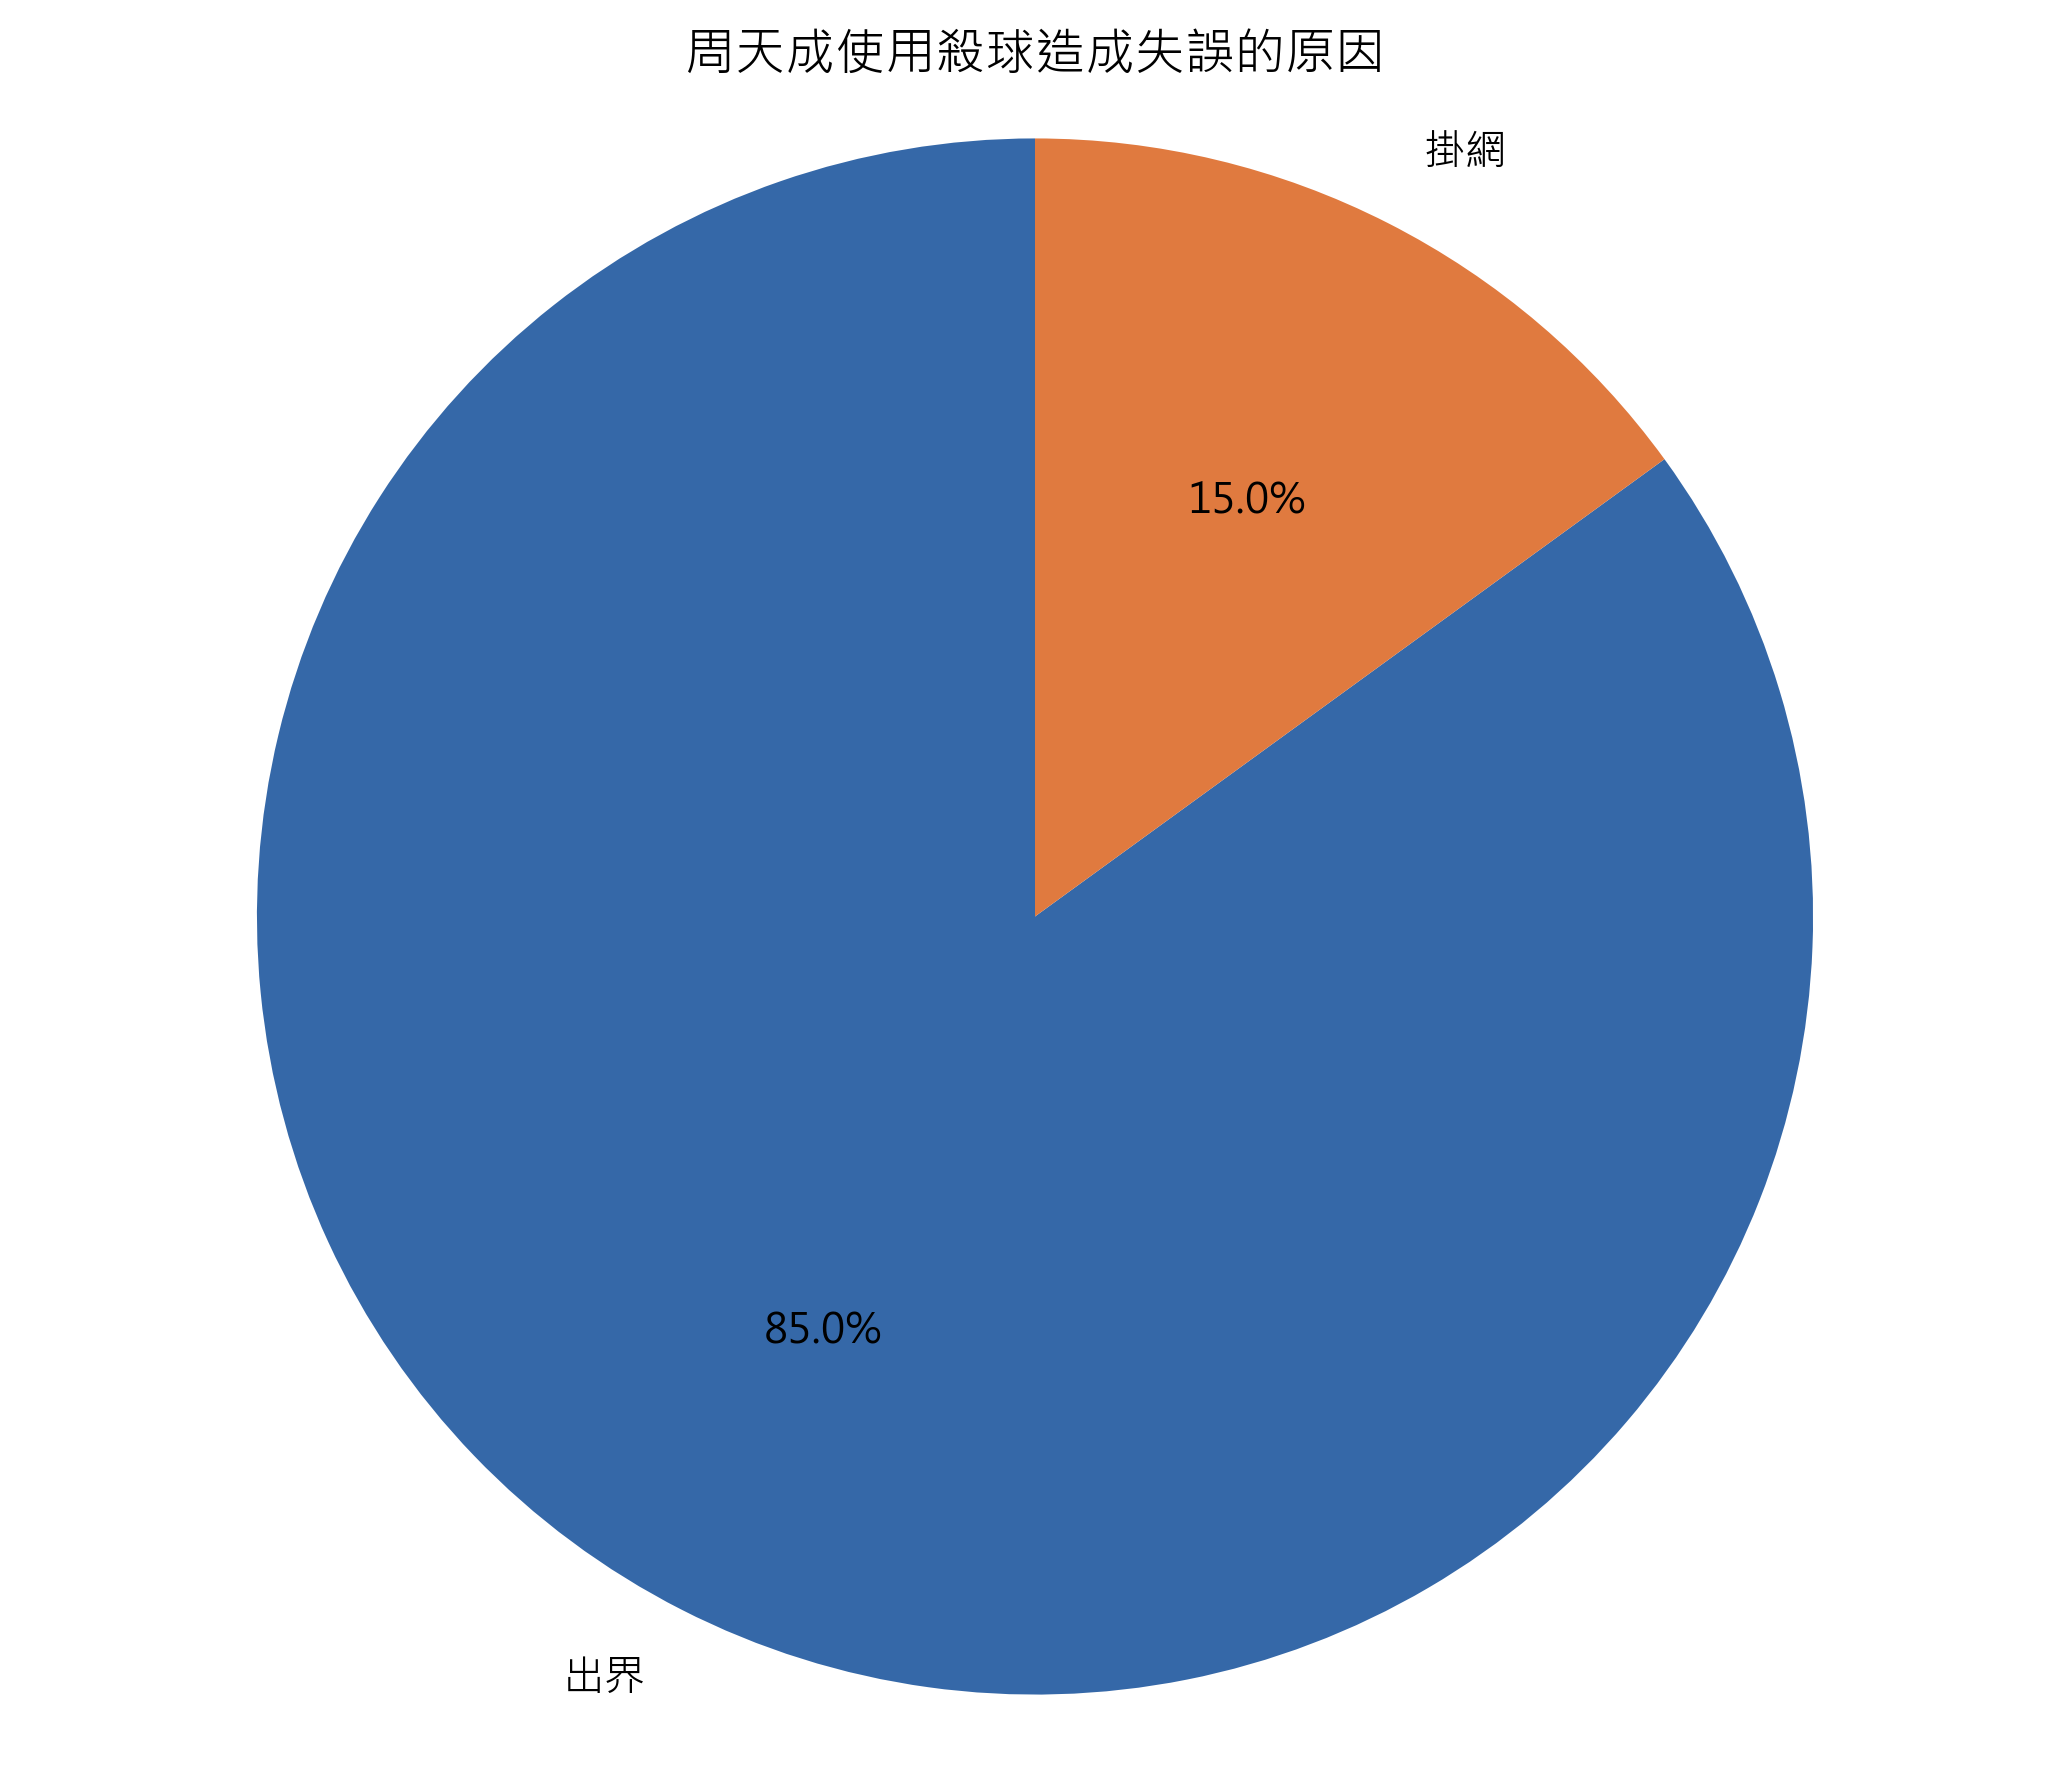

In [ ]:
required_columns = [
    'match_id', 'set', 'rally', 'ball_round',
    'player', 'opponent', 'type', 'getpoint_player', 'lose_reason'
]

if len(df) == 0:
    payload = {
        "series": [{"name": "周天成殺球失誤原因", "labels": [], "values": []}]
    }
elif not set(required_columns).issubset(df.columns):
    missing_columns = sorted(set(required_columns) - set(df.columns))
    print(f"缺少必要欄位：{missing_columns}")
    payload = {
        "series": [{"name": "周天成殺球失誤原因", "labels": [], "values": []}]
    }
else:
    error_df = df[
        (df['player'] == 'CHOU Tien Chen') &
        (df['type'] == '殺球') &
        (df['getpoint_player'] == df['opponent']) &
        (df['lose_reason'].notna())
    ][['match_id', 'set', 'rally', 'ball_round', 'lose_reason']].copy()

    reason_counts = (
        error_df['lose_reason']
        .astype(str)
        .value_counts()
        .sort_values(ascending=False)
    )

    payload = {
        "series": [{
            "name": "周天成殺球失誤原因",
            "labels": reason_counts.index.tolist(),
            "values": reason_counts.astype(int).tolist()
        }]
    }

template_output = render_output(
    kind='pie',
    payload=payload,
    title='周天成使用殺球造成失誤的原因'
)


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 38
**問題**: 在周天成的所有失分中，有多少百分比是因為對手的殺球導致的？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：text；renderer：renderer / completed


In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round',
    'player', 'type', 'getpoint_player'
]

missing_cols = [col for col in required_cols if col not in df.columns]

if len(df) == 0:
    payload = {
        "label": "周天成失分中對手殺球導致的比例",
        "value": None,
        "unit": "%",
        "note": "資料為空，無法計算。"
    }
elif missing_cols:
    raise ValueError(f"缺少必要欄位：{missing_cols}")
else:
    target_player = "CHOU Tien Chen"
    opponent_player = "Kento MOMOTA"
    group_cols = ['match_id', 'set', 'rally']

    data = df.sort_values(
        ['match_id', 'set', 'rally', 'ball_round']
    ).copy()

    data['prev_player'] = data.groupby(group_cols)['player'].shift(1)
    data['prev_type'] = data.groupby(group_cols)['type'].shift(1)

    rally_last = data.groupby(group_cols, sort=False).tail(1).copy()

    chou_loss_events = rally_last[
        rally_last['getpoint_player'].eq(opponent_player)
    ]

    opponent_smash_loss_events = chou_loss_events[
        chou_loss_events['player'].eq(opponent_player)
        & chou_loss_events['type'].eq('殺球')
        & chou_loss_events['getpoint_player'].eq(opponent_player)
        & chou_loss_events['prev_player'].eq(target_player)
    ]

    total_loss_count = len(chou_loss_events)
    opponent_smash_loss_count = len(opponent_smash_loss_events)

    percentage = (
        opponent_smash_loss_count / total_loss_count * 100
        if total_loss_count > 0 else None
    )

    payload = {
        "label": "周天成失分中對手殺球導致的比例",
        "value": round(percentage, 2) if percentage is not None else None,
        "unit": "%",
        "note": (
            f"失分事件數：{opponent_smash_loss_count} / {total_loss_count}；"
            "分子限定為對手以殺球主動得分，並確認前一拍為周天成擊球。"
            if percentage is not None
            else "周天成沒有可辨識的失分事件，比例無法計算。"
        )
    }

template_output = render_output(
    kind='text',
    payload=payload,
    title='周天成失分原因分析'
)


周天成失分中對手殺球導致的比例: 12.44%
失分事件數：27 / 217；分子限定為對手以殺球主動得分，並確認前一拍為周天成擊球。


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 42
**問題**: 分析周天成在開局（自己0-4 分）、中局（自己5-17 分）和關鍵分（自己18 分以上）三個比分階中，他的「殺球」使用比例以及得分率，是否有顯著變化？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：table；renderer：renderer / completed


In [ ]:
import math

required_columns = {
    'player', 'type', 'getpoint_player',
    'CHOU Tien Chen_score'
}

if len(df) == 0:
    payload = {
        "columns": ["結果"],
        "rows": [["資料為空，無法分析"]]
    }
elif not required_columns.issubset(df.columns):
    missing = sorted(required_columns - set(df.columns))
    payload = {
        "columns": ["結果"],
        "rows": [[f"缺少必要欄位：{', '.join(missing)}"]]
    }
else:
    player_name = 'CHOU Tien Chen'
    score_column = 'CHOU Tien Chen_score'
    stage_order = ['開局（0–4分）', '中局（5–17分）', '關鍵分（18分以上）']

    work = df.loc[
        (df['player'] == player_name) &
        df[score_column].notna() &
        df['type'].notna()
    ].copy()

    def assign_stage(score):
        if 0 <= score <= 4:
            return '開局（0–4分）'
        if 5 <= score <= 17:
            return '中局（5–17分）'
        if score >= 18:
            return '關鍵分（18分以上）'
        return pd.NA

    work['比分階段'] = work[score_column].apply(assign_stage)
    work = work[work['比分階段'].notna()].copy()

    work['是否殺球'] = work['type'].eq('殺球')
    work['是否殺球主動得分'] = (
        work['是否殺球'] &
        work['player'].eq(work['getpoint_player'])
    )

    result_rows = []
    usage_table = []
    scoring_table = []

    for stage in stage_order:
        stage_df = work[work['比分階段'] == stage]

        total_shots = len(stage_df)
        smash_shots = int(stage_df['是否殺球'].sum())
        active_smash_wins = int(stage_df['是否殺球主動得分'].sum())

        usage_rate = (
            smash_shots / total_shots * 100
            if total_shots > 0 else None
        )
        scoring_rate = (
            active_smash_wins / smash_shots * 100
            if smash_shots > 0 else None
        )

        usage_table.append((smash_shots, total_shots - smash_shots))
        scoring_table.append((active_smash_wins, smash_shots - active_smash_wins))

        result_rows.append([
            stage,
            total_shots,
            smash_shots,
            round(usage_rate, 2) if usage_rate is not None else None,
            active_smash_wins,
            round(scoring_rate, 2) if scoring_rate is not None else None,
            None,
            None,
            None
        ])

    def chi_square_p_value(contingency_table):
        valid_rows = [
            row for row in contingency_table
            if sum(row) > 0
        ]

        if len(valid_rows) < 2:
            return None

        column_totals = [
            sum(row[column_index] for row in valid_rows)
            for column_index in range(len(valid_rows[0]))
        ]
        valid_columns = [
            column_index
            for column_index, total in enumerate(column_totals)
            if total > 0
        ]

        if len(valid_columns) < 2:
            return 1.0

        table = [
            [row[column_index] for column_index in valid_columns]
            for row in valid_rows
        ]

        grand_total = sum(sum(row) for row in table)
        row_totals = [sum(row) for row in table]
        column_totals = [
            sum(table[row_index][column_index] for row_index in range(len(table)))
            for column_index in range(len(valid_columns))
        ]

        chi_square = 0.0
        for row_index, row_total in enumerate(row_totals):
            for column_index, column_total in enumerate(column_totals):
                expected = row_total * column_total / grand_total
                observed = table[row_index][column_index]
                if expected > 0:
                    chi_square += (observed - expected) ** 2 / expected

        degrees_of_freedom = (len(table) - 1) * (len(valid_columns) - 1)

        if degrees_of_freedom == 1:
            p_value = math.erfc(math.sqrt(chi_square / 2))
        elif degrees_of_freedom == 2:
            p_value = math.exp(-chi_square / 2)
        else:
            p_value = None

        return p_value

    usage_p = chi_square_p_value(usage_table)
    scoring_p = chi_square_p_value(scoring_table)

    usage_significant = usage_p is not None and usage_p < 0.05
    scoring_significant = scoring_p is not None and scoring_p < 0.05

    result_rows.append([
        '三階段整體檢定',
        None,
        None,
        None,
        None,
        None,
        round(usage_p, 6) if usage_p is not None else None,
        round(scoring_p, 6) if scoring_p is not None else None,
        (
            f"使用比例：{'有顯著變化' if usage_significant else '無顯著變化'}；"
            f"得分率：{'有顯著變化' if scoring_significant else '無顯著變化'}"
        )
    ])

    payload = {
        "columns": [
            "比分階段",
            "周天成總擊球數",
            "殺球數",
            "殺球使用比例（%）",
            "殺球主動得分數",
            "殺球得分率（%）",
            "使用比例整體檢定 p 值",
            "得分率整體檢定 p 值",
            "顯著變化判定（α=0.05）"
        ],
        "rows": result_rows
    }

template_output = render_output(
    kind="table",
    payload=payload,
    title="周天成不同比分階段的殺球使用比例與主動得分率"
)


比分階段  周天成總擊球數   殺球數  殺球使用比例（%）  殺球主動得分數  殺球得分率（%）  使用比例整體檢定 p 值  得分率整體檢定 p 值       顯著變化判定（α=0.05）
  開局（0–4分）    673.0  79.0      11.74     20.0     25.32           NaN          NaN                 None
 中局（5–17分）   1754.0 199.0      11.35     37.0     18.59           NaN          NaN                 None
關鍵分（18分以上）    182.0  21.0      11.54      4.0     19.05           NaN          NaN                 None
   三階段整體檢定      NaN   NaN        NaN      NaN       NaN      0.963095     0.449398 使用比例：無顯著變化；得分率：無顯著變化


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 45
**問題**: 統整周天成每個場次中各局的表現(例如，球種變化、殺球頻與失誤率、失誤原因等等)
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：table；renderer：renderer / completed


In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
    'type', 'getpoint_player', 'lose_reason', 'win_reason'
]

output_columns = [
    '場次', '局數', '周天成擊球數', '回合數', '周天成得分回合',
    '周天成失誤回合', '失誤率', '殺球次數', '殺球頻率',
    '球種分布', '失誤原因分布'
]

if len(df) == 0:
    payload = {
        "columns": output_columns,
        "rows": []
    }
else:
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        payload = {
            "columns": ['說明'],
            "rows": [[f"缺少必要欄位：{', '.join(missing_cols)}"]]
        }
    else:
        target_player = 'CHOU Tien Chen'
        data = df.copy()

        data = data.sort_values(
            ['match_id', 'set', 'rally', 'ball_round']
        ).reset_index(drop=True)

        required_player_mask = (
            data['player'].notna()
            & data['getpoint_player'].notna()
        )

        target_strokes = data[data['player'] == target_player].copy()

        group_keys = ['match_id', 'set']
        rows = []

        for (match_id, set_no), group in target_strokes.groupby(
            group_keys, sort=True, dropna=False
        ):
            total_strokes = len(group)
            rally_count = group[['match_id', 'set', 'rally']].drop_duplicates().shape[0]

            smash_count = int((group['type'] == '殺球').sum())
            smash_rate = smash_count / total_strokes if total_strokes > 0 else 0.0

            type_counts = group['type'].value_counts(dropna=False)
            type_distribution = '；'.join(
                f'{str(shot_type)} {int(count)}次 '
                f'({count / total_strokes:.1%})'
                for shot_type, count in type_counts.items()
            )

            error_mask = (
                (group['player'] == target_player)
                & group['getpoint_player'].notna()
                & (group['getpoint_player'] != target_player)
            )
            error_rows = group[error_mask].copy()
            error_count = len(error_rows)
            error_rate = error_count / total_strokes if total_strokes > 0 else 0.0

            error_reason_counts = error_rows['lose_reason'].dropna().value_counts()
            if len(error_reason_counts) > 0:
                error_reason_distribution = '；'.join(
                    f'{str(reason)} {int(count)}次 '
                    f'({count / error_count:.1%})'
                    for reason, count in error_reason_counts.items()
                )
            else:
                error_reason_distribution = '未記錄'

            rally_results = (
                data[
                    (data['match_id'] == match_id)
                    & (data['set'] == set_no)
                    & data['getpoint_player'].notna()
                ][['match_id', 'set', 'rally', 'getpoint_player']]
                .drop_duplicates(['match_id', 'set', 'rally'])
            )

            target_points = int(
                (rally_results['getpoint_player'] == target_player).sum()
            )

            rows.append([
                int(match_id) if pd.notna(match_id) else match_id,
                int(set_no) if pd.notna(set_no) else set_no,
                int(total_strokes),
                int(rally_count),
                target_points,
                int(error_count),
                f'{error_rate:.1%}',
                int(smash_count),
                f'{smash_rate:.1%}',
                type_distribution,
                error_reason_distribution
            ])

        result_table = pd.DataFrame(rows, columns=output_columns)

        if len(result_table) == 0:
            payload = {
                "columns": output_columns,
                "rows": []
            }
        else:
            payload = {
                "columns": output_columns,
                "rows": result_table.values.tolist()
            }

template_output = render_output(
    kind='table',
    payload=payload,
    title='周天成各場次各局表現統整'
)


場次  局數  周天成擊球數  回合數  周天成得分回合  周天成失誤回合  失誤率  殺球次數  殺球頻率                                                                                                                                                  球種分布                                     失誤原因分布
  1   1     261   35       14       19 7.3%    32 12.3%  長球 51次 (19.5%)；推撲球 51次 (19.5%)；網前球 40次 (15.3%)；殺球 32次 (12.3%)；接殺防守 31次 (11.9%)；挑球 16次 (6.1%)；平球 14次 (5.4%)；切球 12次 (4.6%)；發短球 8次 (3.1%)；發長球 6次 (2.3%) 掛網 9次 (47.4%)；出界 6次 (31.6%)；未過網 4次 (21.1%)
  1   2     225   33       18        8 3.6%    21  9.3%  接殺防守 40次 (17.8%)；網前球 40次 (17.8%)；切球 28次 (12.4%)；長球 27次 (12.0%)；挑球 26次 (11.6%)；殺球 21次 (9.3%)；推撲球 20次 (8.9%)；發短球 11次 (4.9%)；平球 7次 (3.1%)；發長球 5次 (2.2%)                出界 4次 (50.0%)；掛網 4次 (50.0%)
  1   3     293   39       18       17 5.8%    28  9.6%  接殺防守 64次 (21.8%)；網前球 55次 (18.8%)；長球 30次 (10.2%)；推撲球 30次 (10.2%)；殺球 28次 (9.6%)；挑球 27次 (9.2%)；切球 24次 (8.2%)；平球 16次 (5.5%)；發長球 14次 (4.8%)；發短球 5次 (1.7%) 掛網 7次 (41.2%)；出界 6次 (35.3%)；未過網 4次 (23.5%)
  3  

### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 47
**問題**: 比較周天成與他的對手的球種使用頻率與其得分率。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：table；renderer：renderer / completed


In [ ]:
required_cols = {"player", "type", "getpoint_player"}
missing_cols = required_cols - set(df.columns)

if len(df) == 0:
    print("資料為空，無法進行分析。")
elif missing_cols:
    print(f"缺少必要欄位：{sorted(missing_cols)}")
else:
    chou = "CHOU Tien Chen"

    analysis_df = df.loc[
        df["player"].notna() & df["type"].notna(),
        ["player", "type", "getpoint_player"]
    ].copy()

    if len(analysis_df) == 0:
        print("沒有可用的球員與球種資料。")
    else:
        analysis_df["分析對象"] = analysis_df["player"].where(
            analysis_df["player"].eq(chou),
            "對手"
        )
        analysis_df["主動得分"] = (
            analysis_df["getpoint_player"].notna()
            & analysis_df["getpoint_player"].eq(analysis_df["player"])
        )

        usage = (
            analysis_df.groupby(["分析對象", "type"], as_index=False)
            .size()
            .rename(columns={"size": "使用拍數"})
        )

        total_usage = (
            analysis_df.groupby("分析對象")
            .size()
            .rename("總使用拍數")
            .reset_index()
        )

        active_wins = (
            analysis_df.loc[analysis_df["主動得分"]]
            .groupby(["分析對象", "type"])
            .size()
            .rename("主動得分拍數")
            .reset_index()
        )

        result = (
            usage.merge(total_usage, on="分析對象", how="left")
            .merge(active_wins, on=["分析對象", "type"], how="left")
        )

        result["主動得分拍數"] = result["主動得分拍數"].fillna(0).astype(int)
        result["使用頻率"] = result["使用拍數"] / result["總使用拍數"] * 100
        result["得分率"] = result["主動得分拍數"] / result["使用拍數"] * 100

        result = result.sort_values(
            ["分析對象", "使用頻率", "type"],
            ascending=[True, False, True]
        ).reset_index(drop=True)

        result["使用頻率"] = result["使用頻率"].round(2)
        result["得分率"] = result["得分率"].round(2)

        output_rows = result[
            [
                "分析對象",
                "type",
                "使用拍數",
                "總使用拍數",
                "使用頻率",
                "主動得分拍數",
                "得分率",
            ]
        ].values.tolist()

        payload = {
            "columns": [
                "分析對象",
                "球種",
                "使用拍數",
                "該對象總使用拍數",
                "使用頻率(%)",
                "主動得分拍數",
                "得分率(%)",
            ],
            "rows": output_rows,
        }

        template_output = render_output(
            kind="table",
            payload=payload,
            title="周天成與對手的球種使用頻率及主動得分率"
        )


分析對象   球種  使用拍數  該對象總使用拍數  使用頻率(%)  主動得分拍數  得分率(%)
CHOU Tien Chen  網前球   582      2609    22.31       4    0.69
CHOU Tien Chen 接殺防守   351      2609    13.45       5    1.42
CHOU Tien Chen  推撲球   334      2609    12.80       9    2.69
CHOU Tien Chen   殺球   299      2609    11.46      61   20.40
CHOU Tien Chen   長球   275      2609    10.54       2    0.73
CHOU Tien Chen   挑球   270      2609    10.35       0    0.00
CHOU Tien Chen   切球   211      2609     8.09       2    0.95
CHOU Tien Chen  發短球   147      2609     5.63       0    0.00
CHOU Tien Chen   平球   106      2609     4.06       2    1.89
CHOU Tien Chen  發長球    34      2609     1.30       0    0.00
            對手  網前球   456      2595    17.57       6    1.32
            對手   挑球   435      2595    16.76       2    0.46
            對手 接殺防守   362      2595    13.95       3    0.83
            對手   切球   325      2595    12.52       4    1.23
            對手   殺球   296      2595    11.41      31   10.47
            對手  推撲球   220      259

### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 50
**問題**: 分析周天成接發球策略：長球、網前球、平球的比例與得分影響。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：table；renderer：generic_text_fallback / fallback；fallback：TypeError: rows[4][6] 只能是 JSON scalar


In [ ]:
required_cols = {
    'match_id', 'set', 'rally', 'ball_round',
    'player', 'type', 'getpoint_player'
}

if len(df) == 0:
    payload = {
        "columns": ["說明"],
        "rows": [["資料為空，無法分析接發球策略。"]]
    }
    title = "周天成接發球策略分析"
else:
    missing_cols = sorted(required_cols - set(df.columns))

    if missing_cols:
        payload = {
            "columns": ["說明"],
            "rows": [[f"缺少必要欄位：{', '.join(missing_cols)}"]]
        }
        title = "周天成接發球策略分析"
    else:
        work = df.sort_values(
            ['match_id', 'set', 'rally', 'ball_round']
        ).copy()

        group_cols = ['match_id', 'set', 'rally']

        # 每個回合的最終得分者；getpoint_player 僅在回合最後一拍記錄
        work['rally_getpoint_player'] = (
            work.groupby(group_cols)['getpoint_player']
            .transform('last')
        )

        # 接發球單拍：每回合第 2 拍，且擊球者為周天成
        receive_df = work[
            (work['player'] == 'CHOU Tien Chen') &
            (work['ball_round'] == 2) &
            (work['type'].notna())
        ].copy()

        strategy_types = ['長球', '網前球', '平球']
        total_receive_count = len(receive_df)

        if total_receive_count == 0:
            payload = {
                "columns": ["說明"],
                "rows": [["找不到周天成的有效接發球單拍資料。"]]
            }
            title = "周天成接發球策略分析"
        else:
            receive_df['周天成是否贏得回合'] = (
                receive_df['rally_getpoint_player'] == 'CHOU Tien Chen'
            )
            receive_df['對手是否贏得回合'] = (
                receive_df['rally_getpoint_player'] == 'Kento MOMOTA'
            )
            receive_df['回合是否已決定'] = (
                receive_df['rally_getpoint_player'].notna()
            )

            rows = []

            for shot_type in strategy_types:
                subset = receive_df[receive_df['type'] == shot_type]
                count = len(subset)
                chou_win_count = int(subset['周天成是否贏得回合'].sum())
                opponent_win_count = int(subset['對手是否贏得回合'].sum())
                undecided_count = int((~subset['回合是否已決定']).sum())

                rows.append([
                    shot_type,
                    count,
                    round(count / total_receive_count * 100, 2),
                    chou_win_count,
                    opponent_win_count,
                    undecided_count,
                    round(chou_win_count / count * 100, 2) if count > 0 else None
                ])

            target_count = int(receive_df['type'].isin(strategy_types).sum())
            target_chou_win_count = int(
                (
                    receive_df['type'].isin(strategy_types) &
                    receive_df['周天成是否贏得回合']
                ).sum()
            )
            target_opponent_win_count = int(
                (
                    receive_df['type'].isin(strategy_types) &
                    receive_df['對手是否贏得回合']
                ).sum()
            )
            target_undecided_count = int(
                (
                    receive_df['type'].isin(strategy_types) &
                    (~receive_df['回合是否已決定'])
                ).sum()
            )

            rows.append([
                '三種策略合計',
                target_count,
                round(target_count / total_receive_count * 100, 2),
                target_chou_win_count,
                target_opponent_win_count,
                target_undecided_count,
                round(
                    target_chou_win_count / target_count * 100, 2
                ) if target_count > 0 else None
            ])

            rows.append([
                '全部接發球',
                total_receive_count,
                100.0,
                int(receive_df['周天成是否贏得回合'].sum()),
                int(receive_df['對手是否贏得回合'].sum()),
                int((~receive_df['回合是否已決定']).sum()),
                round(
                    receive_df['周天成是否贏得回合'].sum()
                    / total_receive_count * 100,
                    2
                )
            ])

            payload = {
                "columns": [
                    "接發球策略",
                    "接發球拍數",
                    "占全部接發球比例(%)",
                    "周天成贏得回合數",
                    "對手贏得回合數",
                    "尚未記錄最終得分者回合數",
                    "周天成最終得分率(%)"
                ],
                "rows": rows
            }
            title = "周天成接發球策略：長球、網前球、平球比例與得分影響"

template_output = render_output(
    kind='table',
    payload=payload,
    title=title
)


表格資料列數: 5


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 51
**問題**: 分析對手殺球到前中後排後，周天成分別會怎麼去反擊？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates`


### 流程摘要

- 場地資訊：完整場地資訊（判定來源：llm）
- 輸出：table；renderer：renderer / completed


In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round',
    'player', 'type', 'landing_area'
]

if len(df) == 0:
    print("資料為空，無法分析。")
elif not set(required_cols).issubset(df.columns):
    missing_cols = [col for col in required_cols if col not in df.columns]
    print(f"缺少必要欄位：{missing_cols}")
else:
    target_player = 'CHOU Tien Chen'
    opponent_player = 'Kento MOMOTA'

    work_df = df.sort_values(
        ['match_id', 'set', 'rally', 'ball_round']
    ).copy()

    group_cols = ['match_id', 'set', 'rally']

    work_df['next_player'] = (
        work_df.groupby(group_cols, sort=False)['player'].shift(-1)
    )
    work_df['next_type'] = (
        work_df.groupby(group_cols, sort=False)['type'].shift(-1)
    )
    work_df['next_ball_round'] = (
        work_df.groupby(group_cols, sort=False)['ball_round'].shift(-1)
    )

    same_rally_next = (
        work_df['next_ball_round'].notna()
        & (work_df['next_ball_round'] == work_df['ball_round'] + 1)
    )

    opponent_smash = (
        (work_df['player'] == opponent_player)
        & (work_df['type'] == '殺球')
        & same_rally_next
        & (work_df['next_player'] == target_player)
        & work_df['landing_area'].notna()
        & work_df['next_type'].notna()
    )

    events = work_df.loc[
        opponent_smash,
        ['match_id', 'set', 'rally', 'ball_round', 'landing_area', 'next_type']
    ].copy()

    def court_category(zone):
        zone = int(zone)
        if zone in [17, 18, 19, 20, 21, 22, 23, 24]:
            return '前排'
        if zone in [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]:
            return '中排'
        if zone in [1, 2, 3, 4]:
            return '後排'
        return '場外或未知'

    if len(events) == 0:
        print("找不到對手殺球後、同一回合下一拍由周天成擊球的有效事件。")
    else:
        events['殺球落點區域'] = events['landing_area'].map(court_category)

        valid_categories = ['前排', '中排', '後排']
        events = events[events['殺球落點區域'].isin(valid_categories)].copy()

        if len(events) == 0:
            print("有效事件的殺球落點皆不在已定義的前、中、後排。")
        else:
            count_table = (
                events.groupby(
                    ['殺球落點區域', 'next_type'],
                    dropna=False
                )
                .size()
                .reset_index(name='事件數')
                .rename(columns={'next_type': '周天成反擊球種'})
            )

            category_totals = (
                events.groupby('殺球落點區域')
                .size()
                .reset_index(name='該落點事件總數')
            )

            result = count_table.merge(
                category_totals,
                on='殺球落點區域',
                how='left'
            )
            result['反擊比例(%)'] = (
                result['事件數'] / result['該落點事件總數'] * 100
            ).round(1)

            category_order = pd.CategoricalDtype(
                categories=valid_categories,
                ordered=True
            )
            result['殺球落點區域'] = result['殺球落點區域'].astype(category_order)
            result = result.sort_values(
                ['殺球落點區域', '事件數', '周天成反擊球種'],
                ascending=[True, False, True]
            ).reset_index(drop=True)

            table_rows = result[
                [
                    '殺球落點區域',
                    '周天成反擊球種',
                    '事件數',
                    '該落點事件總數',
                    '反擊比例(%)'
                ]
            ].values.tolist()

            payload = {
                "table": {
                    "columns": [
                        "對手殺球落點",
                        "周天成下一拍反擊球種",
                        "事件數",
                        "該落點事件總數",
                        "反擊比例(%)"
                    ],
                    "rows": table_rows
                }
            }

            template_output = render_output(
                kind='table',
                payload=payload,
                title='對手殺球落點與周天成下一拍反擊方式'
            )


對手殺球落點 周天成下一拍反擊球種  事件數  該落點事件總數  反擊比例(%)
    前排       接殺防守    1        2     50.0
    前排        網前球    1        2     50.0
    中排       接殺防守  215      246     87.4
    中排        網前球   22      246      8.9
    中排         平球    6      246      2.4
    中排        推撲球    2      246      0.8
    中排         殺球    1      246      0.4


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 60
**問題**: 分析周天成在自己失分回合中，最後一拍前一拍最常使用的球種。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：text；renderer：renderer / completed


In [ ]:
required_cols = [
    "match_id", "set", "rally", "ball_round",
    "player", "getpoint_player", "type"
]

missing_cols = [col for col in required_cols if col not in df.columns]

if len(df) == 0:
    payload = {
        "label": "周天成自己失分回合中，倒數第二拍最常使用的球種",
        "value": "無資料",
        "unit": "",
        "note": "資料表為空。"
    }
elif missing_cols:
    payload = {
        "label": "周天成自己失分回合中，倒數第二拍最常使用的球種",
        "value": "無法分析",
        "unit": "",
        "note": f"缺少必要欄位：{', '.join(missing_cols)}。"
    }
else:
    work = df.sort_values(
        ["match_id", "set", "rally", "ball_round"],
        kind="mergesort"
    ).copy()

    rally_keys = ["match_id", "set", "rally"]
    grouped = work.groupby(rally_keys, sort=False, dropna=False)

    work["_rally_last_getpoint_player"] = grouped["getpoint_player"].transform("last")
    work["_rally_shot_index"] = grouped.cumcount()
    work["_rally_shot_count"] = grouped["ball_round"].transform("size")

    # 周天成失分：該回合最終得分者為對手，而非 NULL。
    # 倒數第二拍：每個回合的 shot_index == rally_shot_count - 2。
    penultimate = work[
        (work["_rally_last_getpoint_player"] == "Kento MOMOTA") &
        (work["_rally_shot_index"] == work["_rally_shot_count"] - 2) &
        work["type"].notna()
    ].copy()

    if len(penultimate) == 0:
        payload = {
            "label": "周天成自己失分回合中，倒數第二拍最常使用的球種",
            "value": "無資料",
            "unit": "",
            "note": "沒有符合條件且具有倒數第二拍球種紀錄的失分回合。"
        }
    else:
        shot_counts = (
            penultimate["type"]
            .astype("string")
            .value_counts()
            .sort_index()
        )
        max_count = shot_counts.max()
        top_shots = shot_counts[shot_counts == max_count].index.tolist()
        top_shot = "、".join(top_shots)

        payload = {
            "label": "周天成自己失分回合中，倒數第二拍最常使用的球種",
            "value": top_shot,
            "unit": "球種",
            "note": (
                f"統計 {len(penultimate)} 個周天成失分回合；"
                f"最高次數為 {int(max_count)} 次。"
            )
        }

template_output = render_output(
    kind="text",
    payload=payload,
    title="周天成失分回合倒數第二拍球種"
)


周天成自己失分回合中，倒數第二拍最常使用的球種: 網前球球種
統計 217 個周天成失分回合；最高次數為 52 次。


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 61
**問題**: 在被對手四角拉吊得回合下，周天成勝率是多少？四角拉吊定義:(同一個球員在場區[1, 4, 21, 24]內跑動，擊球點從其中一角跑到另一角)
> **使用的資料欄位群組**: `game_structure, coordinates, player_movement, scoring_reason`


### 流程摘要

- 場地資訊：完整場地資訊（判定來源：llm+semantic_guard）
- 輸出：text；renderer：renderer / completed


In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round',
    'player', 'hit_area', 'getpoint_player'
]

missing_cols = [col for col in required_cols if col not in df.columns]

if len(df) == 0:
    payload = {
        "label": "周天成在對手四角拉吊回合下的勝率",
        "value": None,
        "unit": "%",
        "note": "資料為空，無法計算。"
    }
elif missing_cols:
    payload = {
        "label": "周天成在對手四角拉吊回合下的勝率",
        "value": None,
        "unit": "%",
        "note": f"缺少必要欄位：{missing_cols}"
    }
else:
    data = df[required_cols].copy()
    data = data.sort_values(
        ['match_id', 'set', 'rally', 'ball_round']
    ).reset_index(drop=True)

    corners = {1, 4, 21, 24}
    opponent = 'Kento MOMOTA'
    target_player = 'CHOU Tien Chen'
    rally_keys = ['match_id', 'set', 'rally']

    data['previous_same_player_hit_area'] = (
        data.groupby(rally_keys + ['player'], sort=False)['hit_area']
        .shift(1)
    )

    data['is_opponent_four_corner_transition'] = (
        (data['player'] == opponent)
        & data['hit_area'].isin(corners)
        & data['previous_same_player_hit_area'].isin(corners)
        & (
            data['hit_area']
            != data['previous_same_player_hit_area']
        )
    )

    qualifying_rallies = (
        data.groupby(rally_keys, sort=False)[
            'is_opponent_four_corner_transition'
        ]
        .any()
        .rename('is_qualifying_rally')
        .reset_index()
    )

    rally_winner = (
        data.groupby(rally_keys, sort=False)['getpoint_player']
        .last()
        .rename('rally_winner')
        .reset_index()
    )

    rally_level = qualifying_rallies.merge(
        rally_winner,
        on=rally_keys,
        how='left'
    )

    qualified = rally_level[
        rally_level['is_qualifying_rally']
        & rally_level['rally_winner'].notna()
    ].copy()

    total_qualified_rallies = len(qualified)
    chou_wins = (
        qualified['rally_winner'] == target_player
    ).sum()

    win_rate = (
        float(chou_wins / total_qualified_rallies * 100)
        if total_qualified_rallies > 0
        else None
    )

    note = (
        f"統計單位為回合；符合對手同一回合中，"
        f"同一球員擊球點由四角 {sorted(corners)} "
        f"的一角移動至另一角的回合。"
        f"有效回合數：{total_qualified_rallies}，"
        f"周天成勝回合數：{chou_wins}。"
    )

    if win_rate is None:
        note += " 沒有可判定最終得分者的有效回合。"

    payload = {
        "label": "周天成在對手四角拉吊回合下的勝率",
        "value": round(win_rate, 2) if win_rate is not None else None,
        "unit": "%",
        "note": note
    }

template_output = render_output(
    kind='text',
    payload=payload,
    title='對手四角拉吊回合分析'
)


周天成在對手四角拉吊回合下的勝率: 42.86%
統計單位為回合；符合對手同一回合中，同一球員擊球點由四角 [1, 4, 21, 24] 的一角移動至另一角的回合。有效回合數：63，周天成勝回合數：27。


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 63
**問題**: 哪些球種組合是周天成最常使用的，反而讓對手主動攻擊？(可能是周天成連續打長球，讓對手抓時機殺球)
> **使用的資料欄位群組**: `game_structure, shot_type`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：table；renderer：renderer / completed


In [ ]:
required_cols = ['match_id', 'set', 'rally', 'ball_round', 'player', 'opponent', 'type']

if len(df) == 0:
    raise ValueError('df 沒有資料，無法進行分析。')

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f'缺少必要欄位：{missing_cols}')

target_player = 'CHOU Tien Chen'
attack_types = {'殺球', '推撲球', '平球'}

work = df[required_cols].copy()
work = work.dropna(subset=[
    'match_id', 'set', 'rally', 'ball_round',
    'player', 'opponent', 'type'
])
work = work.sort_values(
    ['match_id', 'set', 'rally', 'ball_round']
).reset_index(drop=True)

group_cols = ['match_id', 'set', 'rally']
grouped = work.groupby(group_cols, sort=False)

work['next_player'] = grouped['player'].shift(-1)
work['next_type'] = grouped['type'].shift(-1)
work['next_opponent'] = grouped['opponent'].shift(-1)

valid_next_shot = (
    work['next_player'].notna()
    & work['next_type'].notna()
    & (work['next_player'] == work['opponent'])
    & (work['next_opponent'] == work['player'])
)

chou_events = work[
    (work['player'] == target_player)
    & valid_next_shot
].copy()

if len(chou_events) == 0:
    rows = []
else:
    chou_events['對手是否主動攻擊'] = chou_events['next_type'].isin(attack_types)

    combo_stats = (
        chou_events
        .groupby(['type', 'next_type'], as_index=False)
        .agg(
            使用次數=('next_type', 'size'),
            對手主動攻擊次數=('對手是否主動攻擊', 'sum')
        )
    )

    combo_stats['對手主動攻擊率'] = (
        combo_stats['對手主動攻擊次數']
        / combo_stats['使用次數']
        * 100
    ).round(2)

    combo_stats = combo_stats[
        combo_stats['對手主動攻擊次數'] > 0
    ].sort_values(
        ['對手主動攻擊次數', '使用次數', '對手主動攻擊率'],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    combo_stats = combo_stats.rename(columns={
        'type': '周天成球種',
        'next_type': '對手下一拍球種'
    })

    rows = combo_stats[
        [
            '周天成球種',
            '對手下一拍球種',
            '使用次數',
            '對手主動攻擊次數',
            '對手主動攻擊率'
        ]
    ].values.tolist()

payload = {
    'columns': [
        '周天成球種',
        '對手下一拍球種',
        '使用次數',
        '對手主動攻擊次數',
        '對手主動攻擊率(%)'
    ],
    'rows': rows
}

template_output = render_output(
    kind='table',
    payload=payload,
    title='周天成球種與對手下一拍主動攻擊組合'
)


周天成球種 對手下一拍球種  使用次數  對手主動攻擊次數  對手主動攻擊率(%)
   長球      殺球   102       102       100.0
  網前球     推撲球    83        83       100.0
   挑球      殺球    81        81       100.0
  推撲球      殺球    76        76       100.0
 接殺防守     推撲球    55        55       100.0
  發短球     推撲球    45        45       100.0
  推撲球      平球    26        26       100.0
   切球     推撲球    24        24       100.0
  發長球      殺球    19        19       100.0
   平球      平球    18        18       100.0
 接殺防守      殺球    12        12       100.0
 接殺防守      平球    11        11       100.0
   挑球      平球     8         8       100.0
   平球     推撲球     7         7       100.0
   切球      平球     6         6       100.0
   殺球      平球     3         3       100.0
  推撲球     推撲球     2         2       100.0
  網前球      平球     2         2       100.0
   長球      平球     2         2       100.0
…（輸出已截斷；notebook 僅保留重點）


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 65
**問題**: 在周天成連續失分3分(含)以上時，他的打擊策略選擇是否變得激進或過於保守？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：text；renderer：renderer / completed


In [ ]:
required_cols = {
    'match_id', 'set', 'rally', 'ball_round',
    'player', 'type', 'getpoint_player'
}

missing_cols = sorted(required_cols - set(df.columns))

if len(df) == 0:
    payload = {
        "label": "分析結果",
        "value": "資料為空",
        "unit": "",
        "note": "無法進行周天成連續失分後的打擊策略分析。"
    }
elif missing_cols:
    payload = {
        "label": "分析結果",
        "value": "欄位不足",
        "unit": "",
        "note": "缺少必要欄位：" + "、".join(missing_cols)
    }
else:
    player_name = 'CHOU Tien Chen'
    opponent_name = 'Kento MOMOTA'
    group_cols = ['match_id', 'set', 'rally']

    work = df.sort_values(
        ['match_id', 'set', 'rally', 'ball_round']
    ).copy()

    rally_last = (
        work.groupby(group_cols, sort=False, as_index=False)
        .agg(
            rally_last_getpoint=('getpoint_player', lambda s: s.iloc[-1]),
            rally_order=('ball_round', 'max')
        )
        .sort_values(['match_id', 'set', 'rally'])
    )

    rally_last['chou_lost_rally'] = (
        rally_last['rally_last_getpoint'] == opponent_name
    )

    rally_last['prior_loss_streak'] = (
        rally_last.groupby(['match_id', 'set'], sort=False)['chou_lost_rally']
        .transform(
            lambda s: s.astype(int)
            .groupby((~s).cumsum())
            .cumsum()
            .shift(1)
            .fillna(0)
        )
    )

    rally_state = rally_last[group_cols + ['prior_loss_streak']]

    work = work.merge(
        rally_state,
        on=group_cols,
        how='left',
        validate='many_to_one'
    )

    chou_shots = work[
        (work['player'] == player_name) &
        work['type'].notna()
    ].copy()

    if len(chou_shots) == 0:
        payload = {
            "label": "分析結果",
            "value": "無可用擊球資料",
            "unit": "",
            "note": "資料中沒有周天成且球種不為空的擊球紀錄。"
        }
    else:
        aggressive_types = {'殺球', '推撲球', '平球'}
        conservative_types = {'挑球', '接殺防守', '長球'}

        chou_shots['strategy_group'] = '中性或其他'
        chou_shots.loc[
            chou_shots['type'].isin(aggressive_types),
            'strategy_group'
        ] = '較積極'
        chou_shots.loc[
            chou_shots['type'].isin(conservative_types),
            'strategy_group'
        ] = '較保守'

        chou_shots['streak_condition'] = (
            chou_shots['prior_loss_streak'] >= 3
        )

        during_streak = chou_shots[
            chou_shots['streak_condition']
        ]
        baseline = chou_shots[
            ~chou_shots['streak_condition']
        ]

        if len(during_streak) == 0 or len(baseline) == 0:
            payload = {
                "label": "分析結果",
                "value": "資料不足以比較",
                "unit": "",
                "note": (
                    f"連續失分達3分後的周天成擊球數={len(during_streak)}，"
                    f"基準擊球數={len(baseline)}。"
                )
            }
        else:
            during_aggressive_rate = (
                (during_streak['strategy_group'] == '較積極').mean()
            )
            baseline_aggressive_rate = (
                (baseline['strategy_group'] == '較積極').mean()
            )
            during_conservative_rate = (
                (during_streak['strategy_group'] == '較保守').mean()
            )
            baseline_conservative_rate = (
                (baseline['strategy_group'] == '較保守').mean()
            )

            aggressive_diff = (
                during_aggressive_rate - baseline_aggressive_rate
            )
            conservative_diff = (
                during_conservative_rate - baseline_conservative_rate
            )

            threshold = 0.05

            if aggressive_diff >= threshold and aggressive_diff > conservative_diff:
                conclusion = "變得較積極"
            elif conservative_diff >= threshold and conservative_diff > aggressive_diff:
                conclusion = "變得較保守"
            else:
                conclusion = "沒有明顯變得激進或保守"

            type_counts = (
                during_streak['type']
                .value_counts()
                .head(5)
                .to_dict()
            )

            type_summary = "、".join(
                f"{shot_type}:{count}"
                for shot_type, count in type_counts.items()
            )

            payload = {
                "label": "周天成連續失分3分以上後的打擊策略",
                "value": conclusion,
                "unit": "",
                "note": (
                    f"比較口徑：以每個match_id、set、rally為回合單位；"
                    f"失分定義為該回合最終getpoint_player為{opponent_name}。"
                    f"統計周天成在前一回合已連續失分至少3分後的所有擊球，"
                    f"並與其餘擊球比較。"
                    f"連續失分後樣本={len(during_streak)}拍，"
                    f"基準樣本={len(baseline)}拍；"
                    f"較積極球種（殺球、推撲球、平球）比例："
                    f"{during_aggressive_rate:.1%} vs {baseline_aggressive_rate:.1%}，"
                    f"差異={aggressive_diff:+.1%}；"
                    f"較保守球種（挑球、接殺防守、長球）比例："
                    f"{during_conservative_rate:.1%} vs {baseline_conservative_rate:.1%}，"
                    f"差異={conservative_diff:+.1%}。"
                    f"連續失分後主要球種：{type_summary}。"
                )
            }

template_output = render_output(
    kind='text',
    payload=payload,
    title='周天成連續失分後的打擊策略分析'
)


周天成連續失分3分以上後的打擊策略: 變得較保守
比較口徑：以每個match_id、set、rally為回合單位；失分定義為該回合最終getpoint_player為Kento MOMOTA。統計周天成在前一回合已連續失分至少3分後的所有擊球，並與其餘擊球比較。連續失分後樣本=248拍，基準樣本=2361拍；較積極球種（殺球、推撲球、平球）比例：29.8% vs 28.2%，差異=+1.7%；較保守球種（挑球、接殺防守、長球）比例：39.9% vs 33.8%，差異=+6.2%。連續失分後主要球種：網前球:62、接殺防守:38、挑球:37、殺球:34、推撲球:26。


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 66
**問題**: 分析周天成在「領先 3 分以上」時的擊球策略是否更保守？請統計球種比例。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：table；renderer：renderer / completed


In [ ]:
required_cols = {
    'player', 'type', 'Kento MOMOTA_score', 'CHOU Tien Chen_score'
}
missing_cols = required_cols.difference(df.columns)

columns = ['情境', '球種', '拍數', '比例(%)', '領先相對未領先差異(百分點)']

if len(df) == 0:
    payload = {
        "columns": columns,
        "rows": [["無資料", "", 0, None, None]]
    }
elif missing_cols:
    raise ValueError(f"缺少必要欄位：{sorted(missing_cols)}")
else:
    target_player = 'CHOU Tien Chen'
    target_score_col = 'CHOU Tien Chen_score'
    opponent_score_col = 'Kento MOMOTA_score'

    analysis_df = (
        df.loc[
            df['player'].eq(target_player),
            ['match_id', 'set', 'rally', 'ball_round', 'player', 'type',
             target_score_col, opponent_score_col]
        ]
        .dropna(subset=['type', target_score_col, opponent_score_col])
        .copy()
    )

    analysis_df['比分差'] = (
        analysis_df[target_score_col] - analysis_df[opponent_score_col]
    )
    analysis_df['情境'] = analysis_df['比分差'].ge(3).map({
        True: '領先3分以上',
        False: '未領先3分以上'
    })

    shot_order = [
        '發短球', '發長球', '長球', '殺球', '接殺防守',
        '平球', '網前球', '挑球', '切球', '推撲球'
    ]
    observed_types = analysis_df['type'].dropna().astype(str).unique().tolist()
    shot_types = shot_order + sorted(
        [x for x in observed_types if x not in shot_order]
    )

    condition_order = ['領先3分以上', '未領先3分以上']
    counts = (
        analysis_df.groupby(['情境', 'type'])
        .size()
        .unstack(fill_value=0)
        .reindex(index=condition_order, columns=shot_types, fill_value=0)
    )
    totals = counts.sum(axis=1)
    proportions = counts.div(totals.replace(0, pd.NA), axis=0).mul(100)

    rows = []

    for condition in condition_order:
        for shot_type in shot_types:
            rows.append([
                condition,
                shot_type,
                int(counts.loc[condition, shot_type]),
                round(float(proportions.loc[condition, shot_type]), 2)
                if pd.notna(proportions.loc[condition, shot_type]) else None,
                None
            ])

        rows.append([
            condition,
            '總計',
            int(totals.loc[condition]),
            100.0 if totals.loc[condition] > 0 else None,
            None
        ])

    for shot_type in shot_types:
        leading_prop = proportions.loc['領先3分以上', shot_type]
        nonleading_prop = proportions.loc['未領先3分以上', shot_type]
        delta = (
            leading_prop - nonleading_prop
            if pd.notna(leading_prop) and pd.notna(nonleading_prop)
            else None
        )
        rows.append([
            '差異',
            shot_type,
            int(
                counts.loc['領先3分以上', shot_type]
                - counts.loc['未領先3分以上', shot_type]
            ),
            None,
            round(float(delta), 2) if delta is not None else None
        ])

    for condition in condition_order:
        smash_count = int(counts.loc[condition, '殺球'])
        smash_prop = proportions.loc[condition, '殺球']
        rows.append([
            condition,
            '保守程度代理：殺球',
            smash_count,
            round(float(smash_prop), 2) if pd.notna(smash_prop) else None,
            None
        ])

    leading_smash_prop = proportions.loc['領先3分以上', '殺球']
    nonleading_smash_prop = proportions.loc['未領先3分以上', '殺球']
    smash_delta = (
        leading_smash_prop - nonleading_smash_prop
        if pd.notna(leading_smash_prop) and pd.notna(nonleading_smash_prop)
        else None
    )
    rows.append([
        '差異',
        '保守程度代理：殺球',
        int(
            counts.loc['領先3分以上', '殺球']
            - counts.loc['未領先3分以上', '殺球']
        ),
        None,
        round(float(smash_delta), 2) if smash_delta is not None else None
    ])

    payload = {
        "columns": columns,
        "rows": rows
    }

template_output = render_output(
    kind='table',
    payload=payload,
    title='周天成領先3分以上與未領先時的單拍球種比例'
)


情境        球種   拍數  比例(%)  領先相對未領先差異(百分點)
 領先3分以上       發短球   39   8.76             NaN
 領先3分以上       發長球    5   1.12             NaN
 領先3分以上        長球   68  15.28             NaN
 領先3分以上        殺球   34   7.64             NaN
 領先3分以上      接殺防守   52  11.69             NaN
 領先3分以上        平球   16   3.60             NaN
 領先3分以上       網前球   79  17.75             NaN
 領先3分以上        挑球   59  13.26             NaN
 領先3分以上        切球   58  13.03             NaN
 領先3分以上       推撲球   35   7.87             NaN
 領先3分以上        總計  445 100.00             NaN
未領先3分以上       發短球  108   4.99             NaN
未領先3分以上       發長球   29   1.34             NaN
未領先3分以上        長球  207   9.57             NaN
未領先3分以上        殺球  265  12.25             NaN
未領先3分以上      接殺防守  299  13.82             NaN
未領先3分以上        平球   90   4.16             NaN
未領先3分以上       網前球  503  23.24             NaN
未領先3分以上        挑球  211   9.75             NaN
…（輸出已截斷；notebook 僅保留重點）


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 67
**問題**: 當分數差距逐漸縮小時（領先轉膠著），周天成殺球成功率是否下降？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：text；renderer：renderer / completed


In [ ]:
required_columns = {
    'player', 'type', 'getpoint_player',
    'Kento MOMOTA_score', 'CHOU Tien Chen_score'
}

if len(df) == 0:
    payload = {
        "label": "周天成殺球成功率是否下降",
        "value": "無法判定",
        "unit": "",
        "note": "資料為空。"
    }
elif not required_columns.issubset(df.columns):
    missing_columns = sorted(required_columns - set(df.columns))
    payload = {
        "label": "周天成殺球成功率是否下降",
        "value": "無法判定",
        "unit": "",
        "note": f"缺少必要欄位：{', '.join(missing_columns)}。"
    }
else:
    analysis_df = df[
        ['player', 'type', 'getpoint_player',
         'Kento MOMOTA_score', 'CHOU Tien Chen_score']
    ].copy()

    analysis_df['kento_score'] = pd.to_numeric(
        analysis_df['Kento MOMOTA_score'], errors='coerce'
    )
    analysis_df['chou_score'] = pd.to_numeric(
        analysis_df['CHOU Tien Chen_score'], errors='coerce'
    )

    analysis_df = analysis_df.dropna(
        subset=['player', 'type', 'getpoint_player', 'kento_score', 'chou_score']
    )

    chou_smash = analysis_df[
        (analysis_df['player'] == 'CHOU Tien Chen') &
        (analysis_df['type'] == '殺球')
    ].copy()

    chou_smash['score_gap'] = (
        chou_smash['chou_score'] - chou_smash['kento_score']
    )

    chou_leading = chou_smash[chou_smash['score_gap'] > 0].copy()

    if len(chou_leading) == 0:
        payload = {
            "label": "周天成殺球成功率是否下降",
            "value": "無法判定",
            "unit": "",
            "note": "沒有周天成領先時的殺球資料。"
        }
    else:
        chou_leading['領先幅度'] = pd.cut(
            chou_leading['score_gap'],
            bins=[0, 1, 2, 3, float('inf')],
            labels=['領先1分', '領先2分', '領先3分', '領先4分以上'],
            right=True,
            include_lowest=False
        )

        chou_leading['active_win'] = (
            chou_leading['getpoint_player'] == chou_leading['player']
        )

        summary = (
            chou_leading
            .groupby('領先幅度', observed=False)
            .agg(
                殺球次數=('active_win', 'size'),
                主動得分次數=('active_win', 'sum')
            )
            .reindex(['領先1分', '領先2分', '領先3分', '領先4分以上'])
        )

        summary['成功率'] = (
            summary['主動得分次數'] / summary['殺球次數'] * 100
        )

        close_count = summary.loc['領先1分', '殺球次數']
        wide_count = summary.loc['領先4分以上', '殺球次數']

        if close_count > 0 and wide_count > 0:
            close_rate = summary.loc['領先1分', '成功率']
            wide_rate = summary.loc['領先4分以上', '成功率']
            rate_difference = close_rate - wide_rate
            answer = "是" if rate_difference < 0 else "否"

            evidence = "; ".join(
                f"{index}: {int(row['主動得分次數'])}/{int(row['殺球次數'])} "
                f"({row['成功率']:.1f}%)"
                for index, row in summary.dropna(subset=['成功率']).iterrows()
            )

            payload = {
                "label": "周天成殺球成功率是否下降",
                "value": answer,
                "unit": "",
                "note": (
                    f"以周天成領先1分代表膠著、領先4分以上代表較大領先；"
                    f"領先1分成功率 {close_rate:.1f}%，"
                    f"領先4分以上成功率 {wide_rate:.1f}%，"
                    f"差異 {rate_difference:+.1f} 個百分點。各領先幅度：{evidence}。"
                    f"成功定義為該拍擊球者與得分者相同的 Active Win，"
                    f"分母為該領先幅度下周天成的全部殺球次數；未進行顯著性檢定。"
                )
            }
        else:
            available_evidence = "; ".join(
                f"{index}: {int(row['主動得分次數'])}/{int(row['殺球次數'])} "
                f"({row['成功率']:.1f}%)"
                for index, row in summary.dropna(subset=['成功率']).iterrows()
            )

            payload = {
                "label": "周天成殺球成功率是否下降",
                "value": "無法判定",
                "unit": "",
                "note": (
                    "缺少領先1分或領先4分以上的可比較資料。"
                    f"現有統計：{available_evidence}。"
                )
            }

template_output = render_output(
    kind='text',
    payload=payload,
    title='周天成領先轉膠著時的殺球成功率'
)


周天成殺球成功率是否下降: 否
以周天成領先1分代表膠著、領先4分以上代表較大領先；領先1分成功率 76.9%，領先4分以上成功率 55.6%，差異 +21.4 個百分點。各領先幅度：領先1分: 10/13 (76.9%); 領先2分: 5/7 (71.4%); 領先3分: 2/3 (66.7%); 領先4分以上: 5/9 (55.6%)。成功定義為該拍擊球者與得分者相同的 Active Win，分母為該領先幅度下周天成的全部殺球次數；未進行顯著性檢定。


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 71
**問題**: 分析周天成在自己領先時與落後時，網前球的使用比例差異。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：table, bar；renderer：renderer / completed


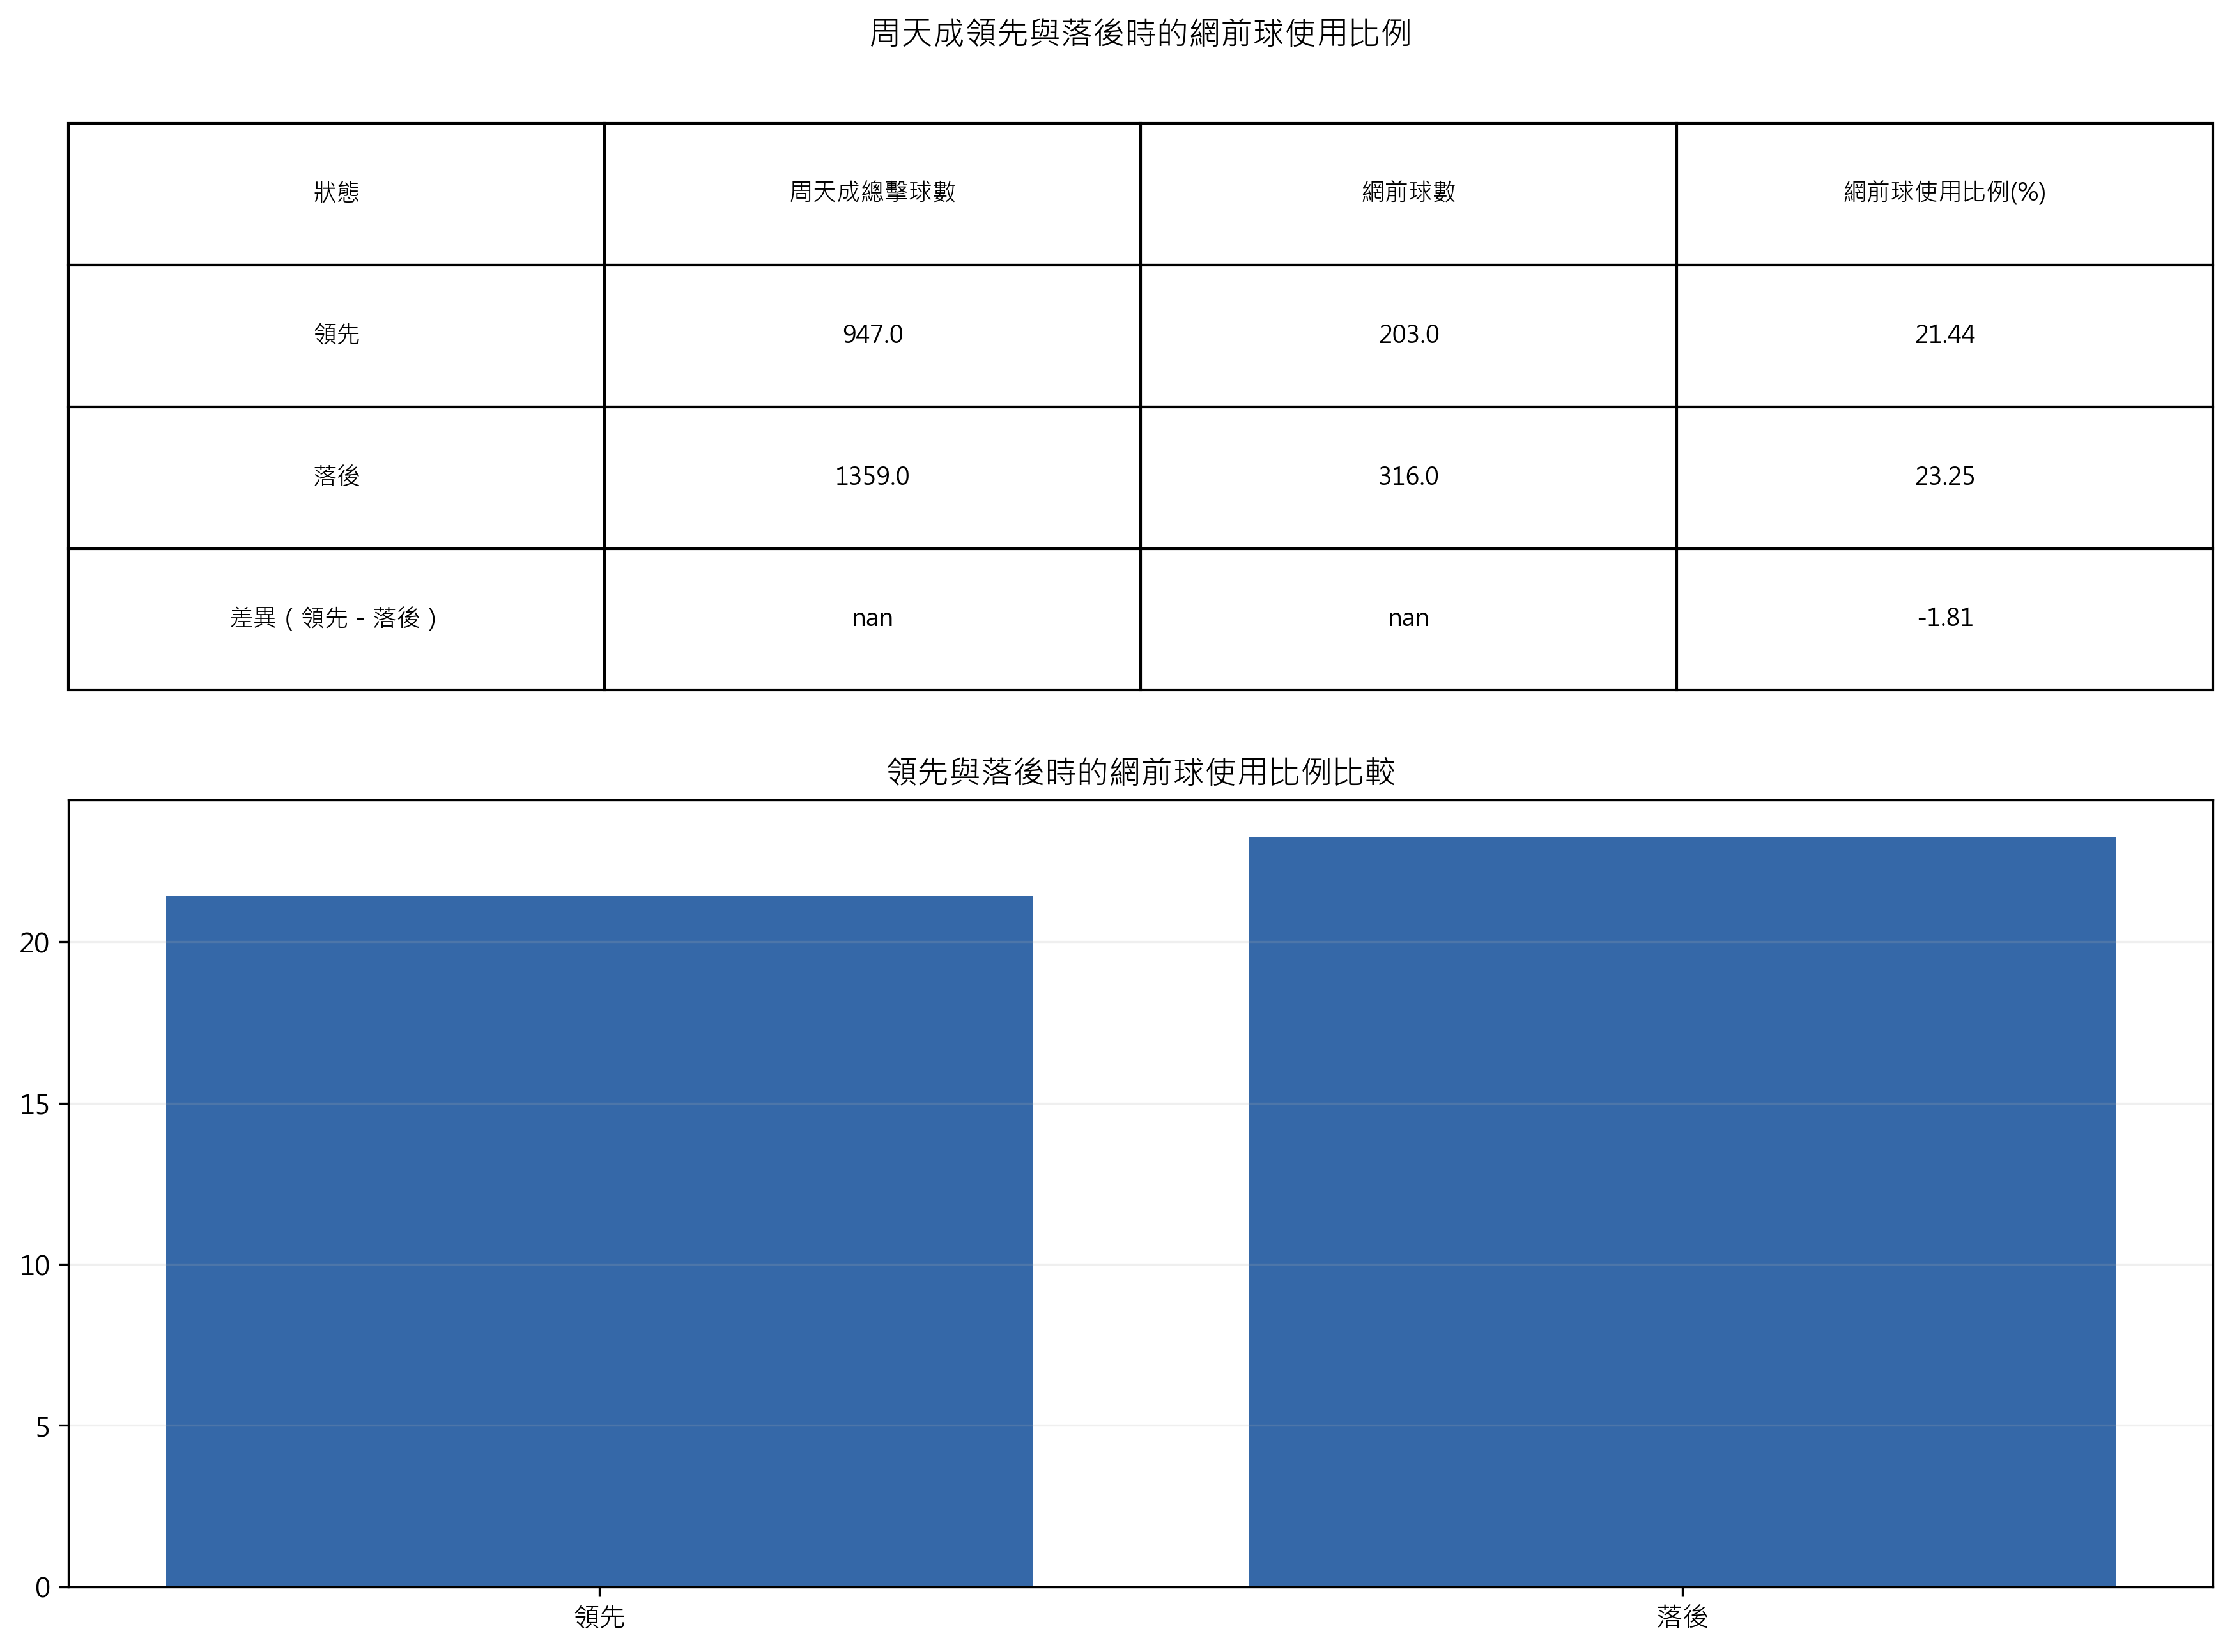

In [ ]:
required_cols = {
    'player', 'type', 'Kento MOMOTA_score', 'CHOU Tien Chen_score'
}

if len(df) == 0:
    payload = {
        "table": {
            "columns": ["狀態", "周天成總擊球數", "網前球數", "網前球使用比例(%)"],
            "rows": []
        },
        "bar": {
            "series": [{"name": "網前球使用比例(%)", "labels": [], "values": []}]
        }
    }
    template_output = render_output(kind="composite", payload={
        "items": [
            {"kind": "table", "payload": payload["table"], "title": "周天成網前球使用比例"},
            {"kind": "bar", "payload": payload["bar"], "title": "領先與落後時的網前球使用比例"}
        ]
    }, title="周天成網前球使用比例分析")
else:
    missing_cols = required_cols.difference(df.columns)

    if missing_cols:
        print(f"缺少必要欄位：{sorted(missing_cols)}")
    else:
        player_name = "CHOU Tien Chen"
        work = df.loc[
            df["player"].eq(player_name),
            ["match_id", "set", "rally", "ball_round", "player",
             "type", "Kento MOMOTA_score", "CHOU Tien Chen_score"]
        ].copy()

        work["周天成比分"] = pd.to_numeric(
            work["CHOU Tien Chen_score"], errors="coerce"
        )
        work["對手比分"] = pd.to_numeric(
            work["Kento MOMOTA_score"], errors="coerce"
        )
        work = work.dropna(subset=["周天成比分", "對手比分"])

        work["比分狀態"] = "平手"
        work.loc[work["周天成比分"] > work["對手比分"], "比分狀態"] = "領先"
        work.loc[work["周天成比分"] < work["對手比分"], "比分狀態"] = "落後"

        analysis = work.loc[work["比分狀態"].isin(["領先", "落後"])].copy()
        analysis["是否網前球"] = analysis["type"].eq("網前球")

        states = ["領先", "落後"]
        summary = (
            analysis.groupby("比分狀態", sort=False)
            .agg(
                周天成總擊球數=("是否網前球", "size"),
                網前球數=("是否網前球", "sum")
            )
            .reindex(states, fill_value=0)
            .reset_index()
        )
        summary["網前球使用比例(%)"] = (
            summary["網前球數"]
            .div(summary["周天成總擊球數"].replace(0, pd.NA))
            .mul(100)
            .fillna(0)
            .round(2)
        )

        leading_rate = float(
            summary.loc[
                summary["比分狀態"].eq("領先"), "網前球使用比例(%)"
            ].iloc[0]
        )
        trailing_rate = float(
            summary.loc[
                summary["比分狀態"].eq("落後"), "網前球使用比例(%)"
            ].iloc[0]
        )
        difference = round(leading_rate - trailing_rate, 2)

        rows = summary[
            ["比分狀態", "周天成總擊球數", "網前球數", "網前球使用比例(%)"]
        ].values.tolist()
        rows.append(["差異（領先－落後）", None, None, difference])

        table_payload = {
            "columns": [
                "狀態",
                "周天成總擊球數",
                "網前球數",
                "網前球使用比例(%)"
            ],
            "rows": rows
        }

        bar_payload = {
            "series": [{
                "name": "網前球使用比例(%)",
                "labels": states,
                "values": summary["網前球使用比例(%)"].astype(float).tolist()
            }]
        }

        template_output = render_output(
            kind="composite",
            payload={
                "items": [
                    {
                        "kind": "table",
                        "payload": table_payload,
                        "title": "周天成領先與落後時的網前球使用比例"
                    },
                    {
                        "kind": "bar",
                        "payload": bar_payload,
                        "title": "領先與落後時的網前球使用比例比較"
                    }
                ]
            },
            title="周天成網前球使用比例分析"
        )


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 73
**問題**: 周天成對直線 vs 斜線殺球的對手回擊效果（得失分比較）。
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：text；renderer：renderer / completed


In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
    'type', 'hit_x', 'landing_x', 'getpoint_player'
]

if len(df) == 0:
    payload = {
        "label": "分析結果",
        "value": "資料不足：DataFrame 為空。",
        "unit": "",
        "note": ""
    }
elif not set(required_cols).issubset(df.columns):
    missing = sorted(set(required_cols) - set(df.columns))
    payload = {
        "label": "分析結果",
        "value": f"欄位不足：缺少 {missing}",
        "unit": "",
        "note": ""
    }
else:
    work = df.sort_values(
        ['match_id', 'set', 'rally', 'ball_round']
    ).copy()

    group_cols = ['match_id', 'set', 'rally']
    grouped = work.groupby(group_cols, sort=False)

    work['next_player'] = grouped['player'].shift(-1)
    work['next_type'] = grouped['type'].shift(-1)
    work['next_match_id'] = grouped['match_id'].shift(-1)
    work['next_set'] = grouped['set'].shift(-1)
    work['next_rally'] = grouped['rally'].shift(-1)

    work['rally_winner'] = grouped['getpoint_player'].transform('last')

    chou = 'CHOU Tien Chen'
    opponent = 'Kento MOMOTA'

    smash_events = work[
        (work['player'] == chou) &
        (work['type'] == '殺球') &
        (work['next_player'] == work['opponent']) &
        (work['next_match_id'] == work['match_id']) &
        (work['next_set'] == work['set']) &
        (work['next_rally'] == work['rally']) &
        (work['hit_x'].notna()) &
        (work['landing_x'].notna()) &
        (work['rally_winner'].isin([chou, opponent]))
    ].copy()

    smash_events = smash_events[
        (smash_events['hit_x'] != 0) &
        (smash_events['landing_x'] != 0)
    ].copy()

    smash_events['方向'] = smash_events.apply(
        lambda row: (
            '直線殺球'
            if row['hit_x'] * row['landing_x'] > 0
            else '斜線殺球'
        ),
        axis=1
    )

    smash_events['結果'] = smash_events['rally_winner'].map({
        chou: '周天成得分',
        opponent: '周天成失分'
    })
    smash_events['對手回擊球種'] = smash_events['next_type'].fillna('未知')

    if len(smash_events) == 0:
        value = "沒有符合條件的周天成殺球後對手下一拍回擊事件。"
        note = (
            "直線／斜線以殺球擊球點 hit_x 與落點 landing_x "
            "位於球場同側或異側作為空間代理；排除 x=0 或空間資料缺失事件。"
        )
    else:
        summary = (
            smash_events
            .groupby('方向')['結果']
            .value_counts()
            .unstack(fill_value=0)
            .reindex(columns=['周天成得分', '周天成失分'], fill_value=0)
            .reset_index()
        )
        summary['事件數'] = summary['周天成得分'] + summary['周天成失分']
        summary['得分率'] = (
            summary['周天成得分'] / summary['事件數'] * 100
        ).round(1)
        summary['失分率'] = (
            summary['周天成失分'] / summary['事件數'] * 100
        ).round(1)
        summary['淨得分差'] = (
            summary['周天成得分'] - summary['周天成失分']
        )

        summary = summary[
            [
                '方向', '事件數', '周天成得分', '周天成失分',
                '得分率', '失分率', '淨得分差'
            ]
        ]

        detail = (
            smash_events
            .groupby(['方向', '對手回擊球種'])['結果']
            .value_counts()
            .unstack(fill_value=0)
            .reindex(columns=['周天成得分', '周天成失分'], fill_value=0)
            .reset_index()
        )
        detail['事件數'] = detail['周天成得分'] + detail['周天成失分']
        detail = detail[
            [
                '方向', '對手回擊球種', '事件數',
                '周天成得分', '周天成失分'
            ]
        ].sort_values(
            ['方向', '事件數', '對手回擊球種'],
            ascending=[True, False, True]
        )

        value = (
            f"有效事件數：{len(smash_events)}\n\n"
            "直線／斜線殺球後一拍的回合最終得失分：\n"
            f"{summary.to_string(index=False)}\n\n"
            "依對手下一拍回擊球種拆分：\n"
            f"{detail.to_string(index=False)}"
        )
        note = (
            "得失分採該回合最終 getpoint_player 判定；"
            "下一拍先在完整資料中依 match_id、set、rally 分組後使用 shift(-1)，"
            "並確認下一拍確為對手擊球。直線／斜線以 hit_x 與 landing_x "
            "同側／異側作為空間代理。"
        )

    payload = {
        "label": "周天成殺球後對手回擊效果",
        "value": value,
        "unit": "",
        "note": note
    }

template_output = render_output(kind="text", payload=payload, title="周天成直線 vs 斜線殺球")


周天成殺球後對手回擊效果: 有效事件數：218

直線／斜線殺球後一拍的回合最終得失分：
  方向  事件數  周天成得分  周天成失分  得分率  失分率  淨得分差
斜線殺球  133     61     72 45.9 54.1   -11
直線殺球   85     36     49 42.4 57.6   -13

依對手下一拍回擊球種拆分：
  方向 對手回擊球種  事件數  周天成得分  周天成失分
斜線殺球   接殺防守   91     43     48
斜線殺球    網前球   37     17     20
斜線殺球     平球    3      1      2
斜線殺球     切球    1      0      1
斜線殺球     挑球    1      0      1
直線殺球   接殺防守   83     36     47
直線殺球    推撲球    1      0      1
直線殺球    網前球    1      0      1
得失分採該回合最終 getpoint_player 判定；下一拍先在完整資料中依 match_id、set、rally 分組後使用 shift(-1)，並確認下一拍確為對手擊球。直線／斜線以 hit_x 與 landing_x 同側／異側作為空間代理。


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 76
**問題**: 在被動情況下（跨步救球），下一拍攻擊性球種的成功機率。
> **使用的資料欄位群組**: `game_structure, shot_type, player_movement, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：text；renderer：renderer / completed


In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round',
    'player', 'opponent', 'type', 'getpoint_player'
]

if len(df) == 0:
    payload = {
        "label": "跨步救球後下一拍攻擊性球種成功機率",
        "value": None,
        "unit": "%",
        "note": "資料為空，無法計算。"
    }
else:
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        payload = {
            "label": "跨步救球後下一拍攻擊性球種成功機率",
            "value": None,
            "unit": "%",
            "note": f"缺少必要欄位：{', '.join(missing_cols)}"
        }
    else:
        attack_types = ['殺球', '推撲球', '平球']
        defensive_trigger = '接殺防守'

        work = df.sort_values(
            ['match_id', 'set', 'rally', 'ball_round']
        ).copy()

        rally_group = work.groupby(
            ['match_id', 'set', 'rally'],
            sort=False
        )

        work['next_player'] = rally_group['player'].shift(-1)
        work['next_opponent'] = rally_group['opponent'].shift(-1)
        work['next_type'] = rally_group['type'].shift(-1)
        work['next_getpoint_player'] = rally_group['getpoint_player'].shift(-1)

        same_rally_next = (
            work['next_player'].notna()
            & work['next_player'].eq(work['opponent'])
            & work['next_opponent'].eq(work['player'])
        )

        after_cross_step_rescue = (
            work['type'].eq(defensive_trigger)
            & same_rally_next
            & work['next_type'].isin(attack_types)
        )

        eligible_next_attacks = work.loc[after_cross_step_rescue].copy()
        denominator = len(eligible_next_attacks)

        if denominator == 0:
            payload = {
                "label": "跨步救球後下一拍攻擊性球種成功機率",
                "value": None,
                "unit": "%",
                "note": (
                    "以「接殺防守」作為跨步救球的可用代理；"
                    "資料中沒有符合條件的同回合下一拍攻擊性球種。"
                )
            }
        else:
            active_wins = (
                eligible_next_attacks['next_player']
                == eligible_next_attacks['next_getpoint_player']
            )
            numerator = int(active_wins.sum())
            probability = numerator / denominator * 100

            payload = {
                "label": "跨步救球後下一拍攻擊性球種成功機率",
                "value": round(float(probability), 2),
                "unit": "%",
                "note": (
                    f"以「接殺防守」代理跨步救球；攻擊性球種為"
                    f"{'、'.join(attack_types)}。"
                    f"分子為下一拍擊球者主動得分 {numerator} 次，"
                    f"分母為符合條件的下一拍攻擊性球種 {denominator} 次；"
                    "僅同一 match_id、set、rally 且下一拍擊球者為對手時納入。"
                )
            }

template_output = render_output(
    kind='text',
    payload=payload,
    title='跨步救球後下一拍攻擊性球種成功機率'
)


跨步救球後下一拍攻擊性球種成功機率: 6.15%
以「接殺防守」代理跨步救球；攻擊性球種為殺球、推撲球、平球。分子為下一拍擊球者主動得分 12 次，分母為符合條件的下一拍攻擊性球種 195 次；僅同一 match_id、set、rally 且下一拍擊球者為對手時納入。


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 79
**問題**: 計算對手挑球過短時，周天成球種的選擇統計。
> **使用的資料欄位群組**: `game_structure, shot_type`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：table, text；renderer：renderer / completed


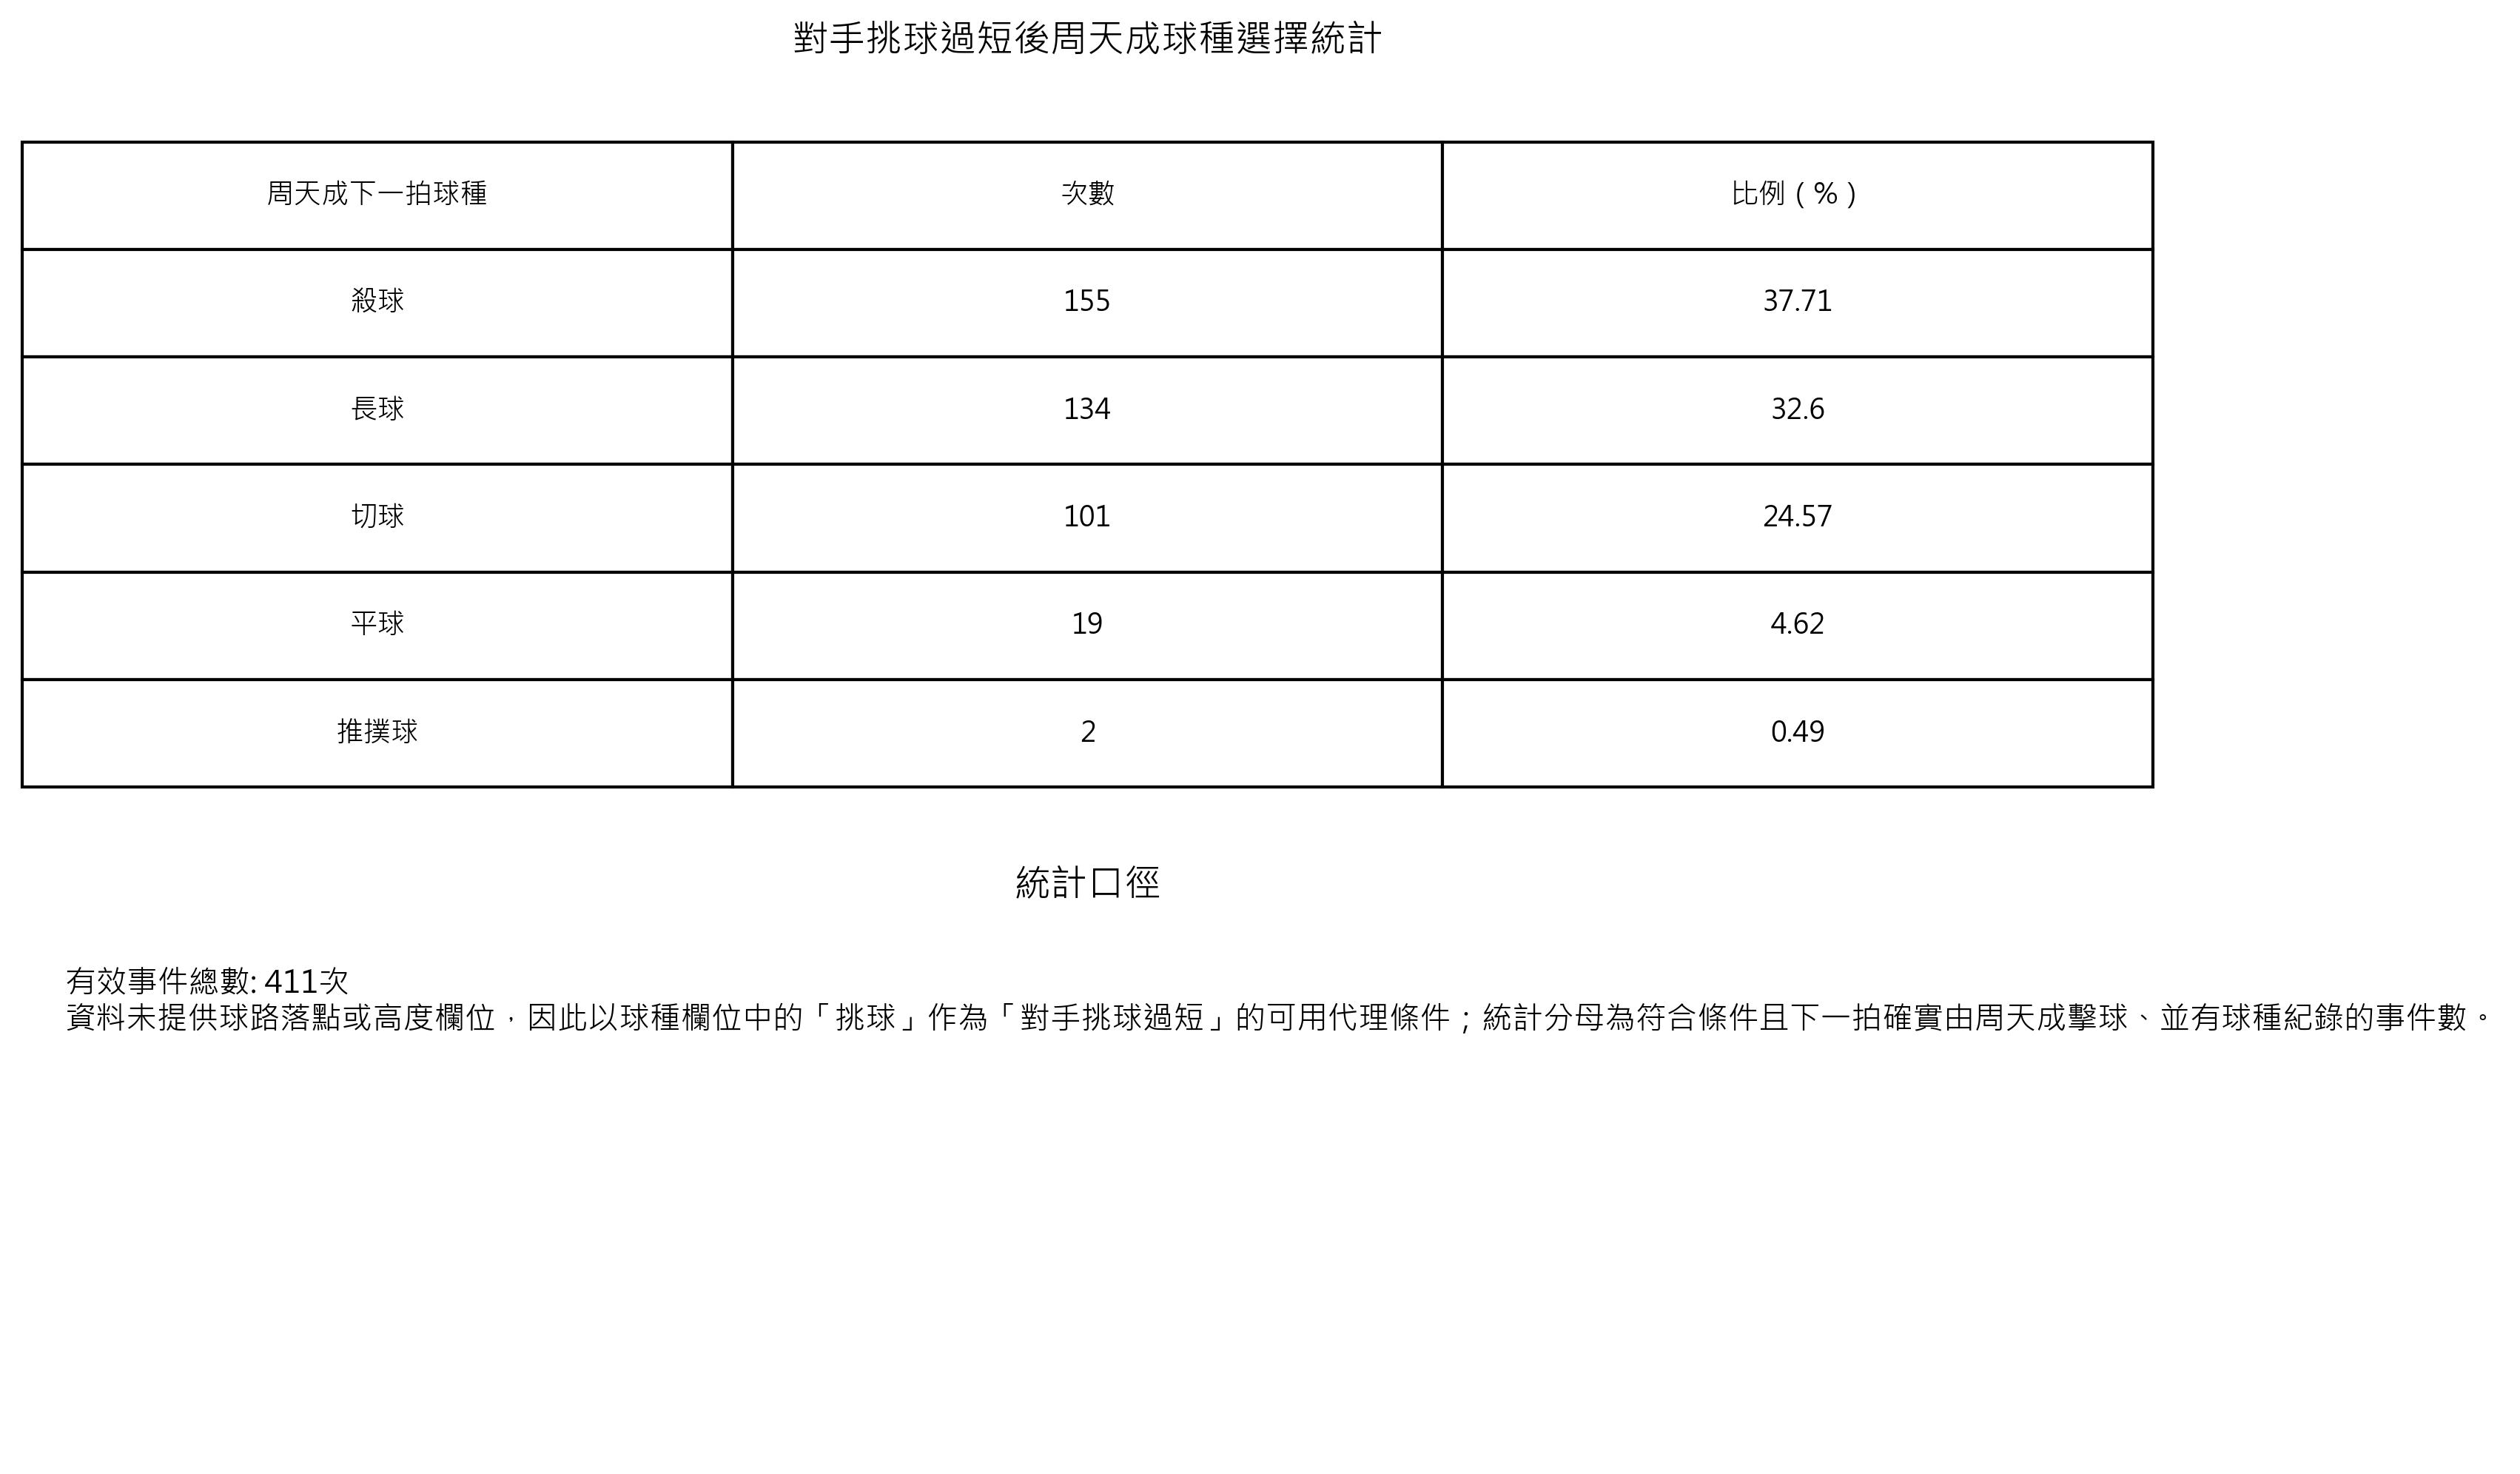

In [ ]:
required_cols = ['match_id', 'set', 'rally', 'ball_round', 'player', 'type']
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    payload = {
        "items": [
            {
                "kind": "table",
                "payload": {
                    "columns": ["狀態"],
                    "rows": [[f"缺少必要欄位：{', '.join(missing_cols)}"]]
                },
                "title": "對手挑球過短後周天成球種選擇統計"
            }
        ]
    }
elif len(df) == 0:
    payload = {
        "items": [
            {
                "kind": "table",
                "payload": {
                    "columns": ["狀態"],
                    "rows": [["資料為空，無法計算"]]
                },
                "title": "對手挑球過短後周天成球種選擇統計"
            }
        ]
    }
else:
    work = df[required_cols].copy()
    work = work.sort_values(
        ['match_id', 'set', 'rally', 'ball_round'],
        kind='mergesort'
    ).reset_index(drop=True)

    group_cols = ['match_id', 'set', 'rally']
    work['next_player'] = work.groupby(group_cols, sort=False)['player'].shift(-1)
    work['next_type'] = work.groupby(group_cols, sort=False)['type'].shift(-1)
    work['next_match_id'] = work.groupby(group_cols, sort=False)['match_id'].shift(-1)
    work['next_set'] = work.groupby(group_cols, sort=False)['set'].shift(-1)
    work['next_rally'] = work.groupby(group_cols, sort=False)['rally'].shift(-1)

    valid_next = (
        (work['next_match_id'] == work['match_id']) &
        (work['next_set'] == work['set']) &
        (work['next_rally'] == work['rally']) &
        (work['next_player'] == 'CHOU Tien Chen') &
        work['next_type'].notna()
    )

    trigger_events = (
        (work['player'] == 'Kento MOMOTA') &
        (work['type'] == '挑球') &
        valid_next
    )

    next_shot = work.loc[trigger_events, ['next_type']].copy()
    denominator = len(next_shot)

    if denominator == 0:
        rows = []
        note = "資料中沒有符合「Kento MOMOTA 挑球後，下一拍由 CHOU Tien Chen 擊球」的有效事件。"
    else:
        stats = (
            next_shot.groupby('next_type', dropna=False)
            .size()
            .reset_index(name='次數')
            .rename(columns={'next_type': '周天成下一拍球種'})
        )
        stats['比例'] = stats['次數'] / denominator
        stats = stats.sort_values(
            ['次數', '周天成下一拍球種'],
            ascending=[False, True],
            kind='mergesort'
        ).reset_index(drop=True)

        rows = [
            [
                str(row['周天成下一拍球種']),
                int(row['次數']),
                round(float(row['比例']) * 100, 2)
            ]
            for _, row in stats.iterrows()
        ]
        note = (
            "資料未提供球路落點或高度欄位，因此以球種欄位中的「挑球」"
            "作為「對手挑球過短」的可用代理條件；統計分母為符合條件且"
            "下一拍確實由周天成擊球、並有球種紀錄的事件數。"
        )

    payload = {
        "items": [
            {
                "kind": "table",
                "payload": {
                    "columns": ["周天成下一拍球種", "次數", "比例（%）"],
                    "rows": rows
                },
                "title": "對手挑球過短後周天成球種選擇統計"
            },
            {
                "kind": "text",
                "payload": {
                    "label": "有效事件總數",
                    "value": denominator,
                    "unit": "次",
                    "note": note
                },
                "title": "統計口徑"
            }
        ]
    }

template_output = render_output(
    kind='composite',
    payload=payload,
    title='對手挑球過短後周天成球種選擇統計'
)


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 80
**問題**: 當周天成發現自己較容易掛網時，應該如何調整自己的擊球策略與站位，以減少掛網失誤的發生？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, player_location, scoring_reason, stroke_details`


### 流程摘要

- 場地資訊：完整場地資訊（判定來源：llm）
- 輸出：text；renderer：renderer / completed


In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
    'type', 'lose_reason', 'getpoint_player', 'player_location_area'
]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"缺少必要欄位：{missing_cols}")

if len(df) == 0:
    payload = {
        "label": "周天成掛網失誤分析",
        "value": 0,
        "unit": "筆",
        "note": "資料表為空，無法進行分析。"
    }
else:
    keys = ['match_id', 'set', 'rally']
    data = df.sort_values(keys + ['ball_round']).copy()

    def station_label(zone):
        if pd.isna(zone):
            return "未知"
        zone = int(zone)

        interior = {
            1: "後場-左", 2: "後場-中左", 3: "後場-中右", 4: "後場-右",
            5: "中場-左", 6: "中場-中左", 7: "中場-中右", 8: "中場-右",
            9: "中場-左", 10: "中場-中左", 11: "中場-中右", 12: "中場-右",
            13: "中場-左", 14: "中場-中左", 15: "中場-中右", 16: "中場-右",
            17: "前場-左", 18: "前場-中左", 19: "前場-中右", 20: "前場-右",
            21: "前場-左", 22: "前場-中左", 23: "前場-中右", 24: "前場-右"
        }
        out_area = {
            25: "出界-右側上", 26: "出界-右側中", 27: "出界-右側下",
            28: "出界-右後方", 29: "出界-左側上", 30: "出界-左側中",
            31: "出界-左側下", 32: "出界-左後方"
        }
        category = (
            "後場" if zone in range(1, 5)
            else "中場" if zone in range(5, 17)
            else "前場" if zone in range(17, 25)
            else "出界" if zone in range(25, 33)
            else "未知"
        )
        if zone in interior:
            return f"{interior[zone]}（{category}）"
        return out_area.get(zone, "未知")

    final_rally_rows = data.groupby(keys, sort=False, as_index=False).tail(1)

    chou_errors = final_rally_rows[
        (final_rally_rows['player'] == 'CHOU Tien Chen') &
        (final_rally_rows['opponent'] == 'Kento MOMOTA') &
        (final_rally_rows['getpoint_player'] == 'Kento MOMOTA') &
        (final_rally_rows['lose_reason'] == '掛網')
    ].copy()

    chou_shots = data[
        (data['player'] == 'CHOU Tien Chen') &
        (data['opponent'] == 'Kento MOMOTA')
    ].copy()

    type_attempts = (
        chou_shots[['type']]
        .dropna(subset=['type'])
        .groupby('type')
        .size()
        .rename('擊球次數')
        .reset_index()
    )
    type_errors = (
        chou_errors[['type']]
        .dropna(subset=['type'])
        .groupby('type')
        .size()
        .rename('掛網失誤次數')
        .reset_index()
    )
    type_table = type_attempts.merge(type_errors, on='type', how='left')
    type_table['掛網失誤次數'] = type_table['掛網失誤次數'].fillna(0).astype(int)
    type_table['掛網失誤率'] = (
        type_table['掛網失誤次數'] / type_table['擊球次數'] * 100
    )
    type_table = type_table.sort_values(
        ['掛網失誤次數', '掛網失誤率', '擊球次數'],
        ascending=[False, False, False]
    )

    chou_shots['站位'] = chou_shots['player_location_area'].map(station_label)
    chou_errors['站位'] = chou_errors['player_location_area'].map(station_label)

    station_attempts = (
        chou_shots[['player_location_area', '站位']]
        .dropna(subset=['player_location_area'])
        .groupby(['player_location_area', '站位'])
        .size()
        .rename('擊球次數')
        .reset_index()
    )
    station_errors = (
        chou_errors[['player_location_area', '站位']]
        .dropna(subset=['player_location_area'])
        .groupby(['player_location_area', '站位'])
        .size()
        .rename('掛網失誤次數')
        .reset_index()
    )
    station_table = station_attempts.merge(
        station_errors,
        on=['player_location_area', '站位'],
        how='left'
    )
    station_table['掛網失誤次數'] = (
        station_table['掛網失誤次數'].fillna(0).astype(int)
    )
    station_table['掛網失誤率'] = (
        station_table['掛網失誤次數'] / station_table['擊球次數'] * 100
    )
    station_table = station_table.sort_values(
        ['掛網失誤次數', '掛網失誤率', '擊球次數'],
        ascending=[False, False, False]
    )

    overall_attempts = len(chou_shots)
    overall_errors = len(chou_errors)
    overall_rate = (
        overall_errors / overall_attempts * 100
        if overall_attempts > 0 else 0.0
    )

    type_evidence = (
        type_table.head(8).to_string(index=False)
        if len(type_table) > 0 else "無可用球種資料"
    )
    station_evidence = (
        station_table.head(8).to_string(index=False)
        if len(station_table) > 0 else "無可用站位資料"
    )

    note = (
        f"統計口徑：以(match_id, set, rally)為一筆回合，僅保留該回合最後一球；"
        f"掛網失誤須同時符合 player=CHOU Tien Chen、"
        f"getpoint_player=Kento MOMOTA、lose_reason=掛網。"
        f"共分析周天成擊球{overall_attempts}拍、掛網失誤{overall_errors}筆，"
        f"整體掛網失誤率{overall_rate:.2f}%。\n\n"
        f"依球種的掛網失誤證據（分母為周天成該球種總擊球次數）：\n"
        f"{type_evidence}\n\n"
        f"依站位的掛網失誤證據（player_location_area正式場地定義）：\n"
        f"{station_evidence}\n\n"
        f"站位區域定義：後場=1-4，中場=5-16，前場=17-24，出界=25-32；"
        f"站位標籤依提供的Court Grid Definitions建立。"
    )

    payload = {
        "label": "周天成掛網失誤分析證據",
        "value": overall_errors,
        "unit": "筆掛網失誤",
        "note": note
    }

template_output = render_output(
    kind='text',
    payload=payload,
    title='周天成掛網失誤的擊球策略與站位證據'
)


周天成掛網失誤分析證據: 57筆掛網失誤
統計口徑：以(match_id, set, rally)為一筆回合，僅保留該回合最後一球；掛網失誤須同時符合 player=CHOU Tien Chen、getpoint_player=Kento MOMOTA、lose_reason=掛網。共分析周天成擊球2609拍、掛網失誤57筆，整體掛網失誤率2.18%。

依球種的掛網失誤證據（分母為周天成該球種總擊球次數）：
type  擊球次數  掛網失誤次數    掛網失誤率
 網前球   582      26 4.467354
接殺防守   351      18 5.128205
  平球   106       3 2.830189
  殺球   299       3 1.003344
 推撲球   334       3 0.898204
  切球   211       2 0.947867
  挑球   270       2 0.740741
  長球   275       0 0.000000

依站位的掛網失誤證據（player_location_area正式場地定義）：
 player_location_area        站位  擊球次數  掛網失誤次數    掛網失誤率
                  6.0 中場-中左（中場）   271      14 5.166052
                 10.0 中場-中左（中場）   782      12 1.534527
                 15.0 中場-中右（中場）   298      10 3.355705
                 11.0 中場-中右（中場）   370       5 1.351351
…（輸出已截斷；notebook 僅保留重點）


### 數據洞察
> SKIP_INSIGHT=True；分析證據已完成，但本題最終洞察／建議未產生；洞察 token 為 0。


## 題號 82
**問題**: 統計周天成成功逼迫對手挑球的頻率，以及最常造成的球種來源。
> **使用的資料欄位群組**: `game_structure, shot_type`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：text；renderer：renderer / completed


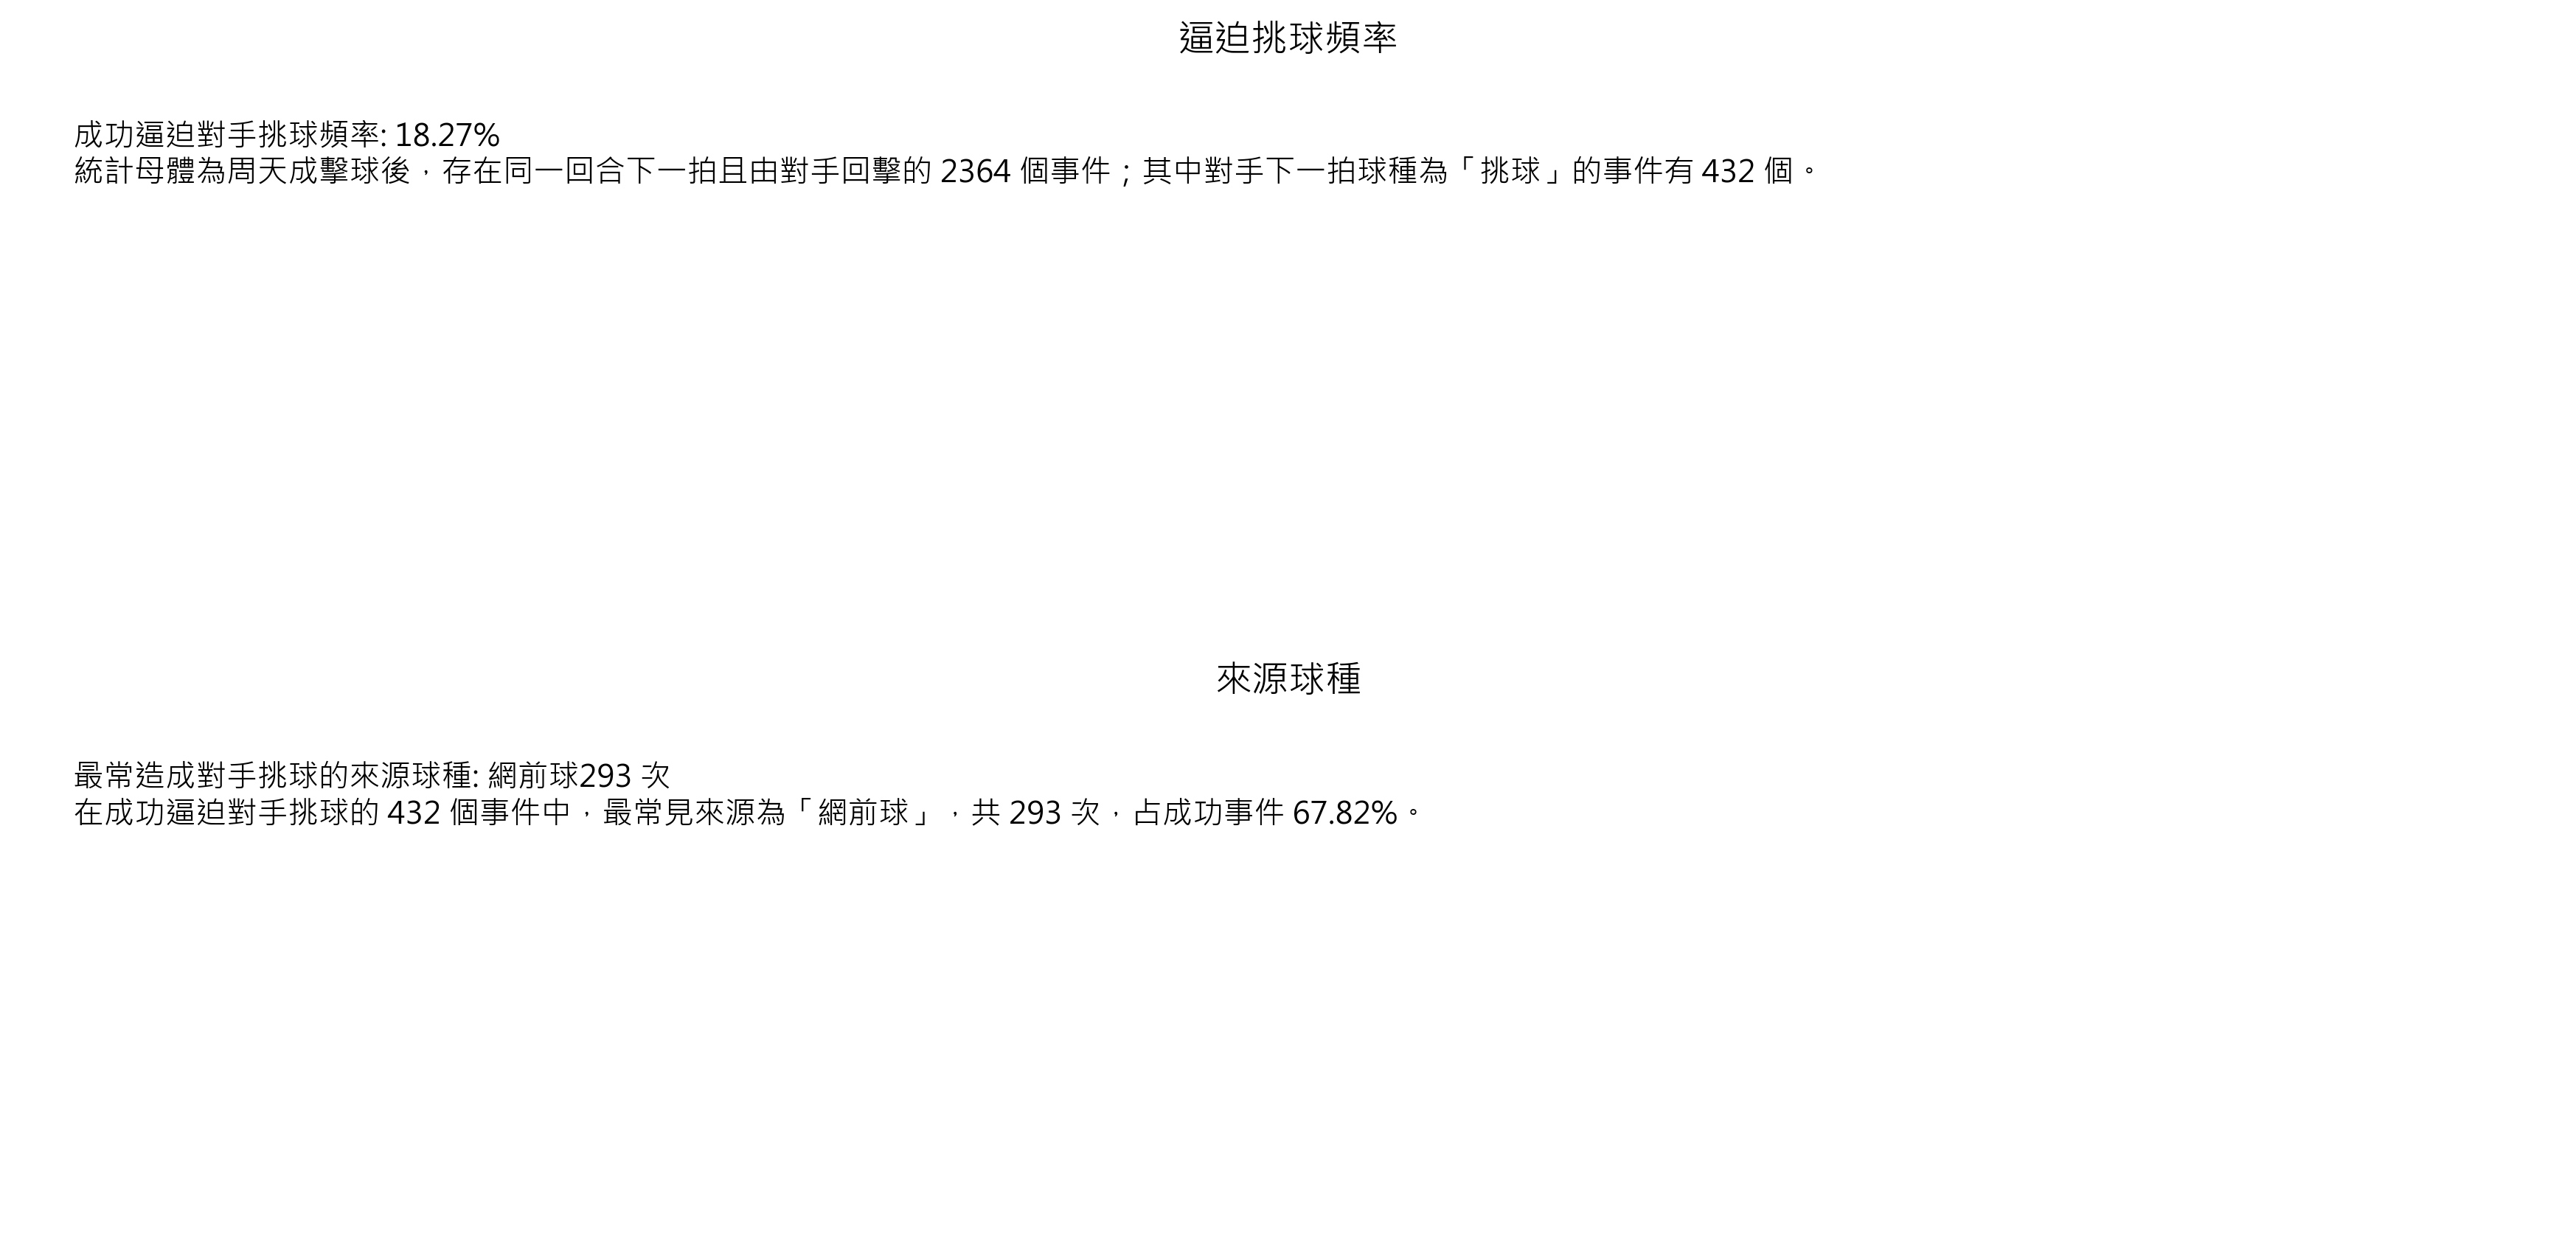

In [ ]:
required_cols = ['match_id', 'set', 'rally', 'player', 'opponent', 'type']
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"缺少必要欄位：{missing_cols}")

result_items = []

if len(df) == 0:
    result_items = [
        {
            "kind": "text",
            "payload": {
                "label": "資料狀態",
                "value": "無資料",
                "unit": "",
                "note": "df 為空，無法統計周天成逼迫對手挑球的頻率。"
            },
            "title": "分析結果"
        }
    ]
else:
    work = df.copy()
    work = work.sort_values(
        ['match_id', 'set', 'rally', 'ball_round']
        if 'ball_round' in work.columns
        else ['match_id', 'set', 'rally']
    ).reset_index(drop=True)

    group_keys = ['match_id', 'set', 'rally']
    grouped = work.groupby(group_keys, sort=False)

    work['next_player'] = grouped['player'].shift(-1)
    work['next_type'] = grouped['type'].shift(-1)

    chou = 'CHOU Tien Chen'

    valid_next = (
        work['player'].eq(chou)
        & work['next_player'].eq(work['opponent'])
        & work['next_type'].notna()
    )

    denominator = int(valid_next.sum())

    forced_lob = valid_next & work['next_type'].eq('挑球')
    successful_count = int(forced_lob.sum())

    frequency = (
        successful_count / denominator * 100
        if denominator > 0 else 0.0
    )

    source_counts = (
        work.loc[forced_lob & work['type'].notna(), 'type']
        .astype(str)
        .value_counts()
    )

    if len(source_counts) > 0:
        top_source = str(source_counts.index[0])
        top_source_count = int(source_counts.iloc[0])
        top_source_share = (
            top_source_count / successful_count * 100
            if successful_count > 0 else 0.0
        )
        source_note = (
            f"在成功逼迫對手挑球的 {successful_count} 個事件中，"
            f"最常見來源為「{top_source}」，共 {top_source_count} 次，"
            f"占成功事件 {top_source_share:.2f}%。"
        )
    else:
        top_source = "無"
        top_source_count = 0
        source_note = "沒有可辨識的成功逼迫對手挑球事件來源球種。"

    result_items = [
        {
            "kind": "text",
            "payload": {
                "label": "成功逼迫對手挑球頻率",
                "value": round(frequency, 2),
                "unit": "%",
                "note": (
                    f"統計母體為周天成擊球後，存在同一回合下一拍且由對手回擊的 "
                    f"{denominator} 個事件；其中對手下一拍球種為「挑球」的事件有 "
                    f"{successful_count} 個。"
                )
            },
            "title": "逼迫挑球頻率"
        },
        {
            "kind": "text",
            "payload": {
                "label": "最常造成對手挑球的來源球種",
                "value": top_source,
                "unit": f"{top_source_count} 次",
                "note": source_note
            },
            "title": "來源球種"
        }
    ]

payload = {"items": result_items}
template_output = render_output(
    kind="composite",
    payload=payload,
    title="周天成逼迫對手挑球分析"
)


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 83
**問題**: 周天成挑高球的落點分布，是否常造成對手容易得分？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, scoring_reason`


### 流程摘要

- 場地資訊：完整場地資訊（判定來源：llm）
- 輸出：text；renderer：renderer / completed


In [ ]:
required_cols = ['player', 'type', 'landing_area', 'getpoint_player', 'opponent']

if len(df) == 0:
    payload = {
        "label": "周天成挑高球後對手得分率",
        "value": None,
        "unit": "%",
        "note": "資料表為空，無法分析。"
    }
else:
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        payload = {
            "label": "周天成挑高球後對手得分率",
            "value": None,
            "unit": "%",
            "note": f"缺少必要欄位：{missing_cols}"
        }
    else:
        zone_info = {
            1: ("後場", "後場左"), 2: ("後場", "後場中左"),
            3: ("後場", "後場中右"), 4: ("後場", "後場右"),
            5: ("中場", "中場左"), 6: ("中場", "中場中左"),
            7: ("中場", "中場中右"), 8: ("中場", "中場右"),
            9: ("中場", "中場左"), 10: ("中場", "中場中左"),
            11: ("中場", "中場中右"), 12: ("中場", "中場右"),
            13: ("中場", "中前左"), 14: ("中場", "中前中左"),
            15: ("中場", "中前中右"), 16: ("中場", "中前右"),
            17: ("前場", "前場左"), 18: ("前場", "前場中左"),
            19: ("前場", "前場中右"), 20: ("前場", "前場右"),
            21: ("前場", "網前左"), 22: ("前場", "網前中左"),
            23: ("前場", "網前中右"), 24: ("網前", "網前右"),
            25: ("出界", "右側上方出界"), 26: ("出界", "右側中間出界"),
            27: ("出界", "右側下方出界"), 28: ("出界", "右後方出界"),
            29: ("出界", "左側上方出界"), 30: ("出界", "左側中間出界"),
            31: ("出界", "左側下方出界"), 32: ("出界", "左後方出界"),
            33: ("未定義", "區域33")
        }

        target = df.loc[
            (df['player'] == 'CHOU Tien Chen') &
            (df['type'] == '挑球'),
            required_cols
        ].dropna(subset=['player', 'type', 'landing_area', 'opponent']).copy()

        if len(target) == 0:
            payload = {
                "label": "周天成挑高球後對手得分率",
                "value": None,
                "unit": "%",
                "note": "沒有符合「周天成」且球種為「挑球」的有效單拍資料。"
            }
        else:
            target['landing_area'] = pd.to_numeric(
                target['landing_area'], errors='coerce'
            )
            target = target.dropna(subset=['landing_area']).copy()
            target['landing_area'] = target['landing_area'].astype(int)

            target['opponent_scored'] = (
                target['getpoint_player'] == target['opponent']
            )

            overall_shots = len(target)
            overall_opponent_scores = int(target['opponent_scored'].sum())
            overall_loss_rate = overall_opponent_scores / overall_shots * 100

            distribution = (
                target.groupby('landing_area', as_index=False)
                .agg(
                    挑球次數=('landing_area', 'size'),
                    對手得分次數=('opponent_scored', 'sum')
                )
            )
            distribution['落點分布'] = (
                distribution['挑球次數'] / overall_shots * 100
            )
            distribution['對手得分率'] = (
                distribution['對手得分次數'] / distribution['挑球次數'] * 100
            )
            distribution['區域類別'] = distribution['landing_area'].map(
                lambda zone: zone_info.get(zone, ("未定義", f"區域{zone}"))[0]
            )
            distribution['相對位置'] = distribution['landing_area'].map(
                lambda zone: zone_info.get(zone, ("未定義", f"區域{zone}"))[1]
            )

            distribution = distribution.sort_values(
                ['挑球次數', 'landing_area'],
                ascending=[False, True]
            )

            detail = []
            for row in distribution.itertuples(index=False):
                detail.append(
                    f"{row.landing_area}({row.區域類別}/{row.相對位置})："
                    f"{row.挑球次數}球，占{row.落點分布:.1f}%，"
                    f"對手得分{int(row.對手得分次數)}球，得分率{row.對手得分率:.1f}%"
                )

            highest_risk = distribution.loc[
                distribution['對手得分率'].idxmax()
            ]

            note = (
                f"完整母體為周天成全部{overall_shots}次挑球；"
                f"失分定義為該拍所在回合的getpoint_player等於對手，"
                f"不區分對手主動得分或周天成失誤。"
                f"對手總得分{overall_opponent_scores}次，整體得分率為"
                f"{overall_loss_rate:.1f}%。"
                f"最高落點風險為{int(highest_risk['landing_area'])}區"
                f"（{highest_risk['區域類別']}/{highest_risk['相對位置']}），"
                f"該區對手得分率{highest_risk['對手得分率']:.1f}%。"
                f"各落點分布：{'；'.join(detail)}"
            )

            payload = {
                "label": "周天成挑球後對手得分率",
                "value": round(overall_loss_rate, 2),
                "unit": "%",
                "note": note
            }

template_output = render_output(
    kind='text',
    payload=payload,
    title='周天成挑高球落點分布與對手得分'
)


周天成挑球後對手得分率: 6.3%
完整母體為周天成全部270次挑球；失分定義為該拍所在回合的getpoint_player等於對手，不區分對手主動得分或周天成失誤。對手總得分17次，整體得分率為6.3%。最高落點風險為28區（出界/右後方出界），該區對手得分率100.0%。各落點分布：4(後場/後場右)：79球，占29.3%，對手得分0球，得分率0.0%；3(後場/後場中右)：54球，占20.0%，對手得分0球，得分率0.0%；1(後場/後場左)：28球，占10.4%，對手得分0球，得分率0.0%；7(中場/中場中右)：27球，占10.0%，對手得分0球，得分率0.0%；5(中場/中場左)：21球，占7.8%，對手得分0球，得分率0.0%；8(中場/中場右)：19球，占7.0%，對手得分0球，得分率0.0%；2(後場/後場中左)：10球，占3.7%，對手得分0球，得分率0.0%；6(中場/中場中左)：9球，占3.3%，對手得分0球，得分率0.0%；28(出界/右後方出界)：5球，占1.9%，對手得分5球，得分率100.0%；32(出界/左後方出界)：4球，占1.5%，對手得分4球，得分率100.0%；10(中場/中場中左)：3球，占1.1%，對手得分0球，得分率0.0%；27(出界/右側下方出界)：3球，占1.1%，對手得分3球，得分率100.0%；9(中場/中場左)：1球，占0.4%，對手得分0球，得分率0.0%；11(中場/中場中右)：1球，占0.4%，對手得分0球，得分率0.0%；12(中場/中場右)：1球，占0.4%，對手得分0球，得分率0.0%；23(前場/網前中右)：1球，占0.4%，對手得分1球，得分率100.0%；24(網前/網前右)：1球，占0.4%，對手得分1球，得分率100.0%；26(出界/右側中間出界)：1球，占0.4%，對手得分1球，得分率100.0%；30(出界/左側中間出界)：1球，占0.4%，對手得分1球，得分率100.0%；31(出界/左側下方出界)：1球，占0.4%，對手得分1球，得分率100.0%


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 84
**問題**: 當周天成採取多拍耐心拉吊策略時的平均勝率。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：text；renderer：generic_text_fallback / fallback；fallback：TypeError: value 只能是 JSON scalar


In [ ]:
required_columns = [
    'match_id', 'set', 'rally', 'ball_round', 'player',
    'type', 'getpoint_player'
]

missing_columns = [col for col in required_columns if col not in df.columns]

if len(df) == 0:
    payload = {
        "label": "周天成多拍耐心拉吊策略平均勝率",
        "value": None,
        "unit": "%",
        "note": "資料表為空，無法計算。"
    }
elif missing_columns:
    payload = {
        "label": "周天成多拍耐心拉吊策略平均勝率",
        "value": None,
        "unit": "%",
        "note": f"缺少必要欄位：{', '.join(missing_columns)}。"
    }
else:
    work_df = df.sort_values(
        ['match_id', 'set', 'rally', 'ball_round']
    ).copy()

    rally_keys = ['match_id', 'set', 'rally']

    strategy_shots = {'長球', '切球', '網前球'}

    rally_summary = (
        work_df.groupby(rally_keys, sort=False)
        .agg(
            shot_count=('ball_round', 'size'),
            player_count=('player', lambda s: (s == 'CHOU Tien Chen').sum()),
            has_long=('type', lambda s: (s == '長球').any()),
            has_drop_or_net=('type', lambda s: s.isin({'切球', '網前球'}).any())
        )
        .reset_index()
    )

    final_point = (
        work_df.dropna(subset=['getpoint_player'])
        .groupby(rally_keys, sort=False)
        .tail(1)[rally_keys + ['getpoint_player']]
    )

    rally_summary = rally_summary.merge(
        final_point,
        on=rally_keys,
        how='inner'
    )

    strategy_rallies = rally_summary[
        (rally_summary['player_count'] > 0) &
        (rally_summary['shot_count'] >= 6) &
        (rally_summary['has_long']) &
        (rally_summary['has_drop_or_net'])
    ].copy()

    if len(strategy_rallies) == 0:
        value = None
        note = (
            "沒有符合條件的回合。策略代理定義為：同一場次與局中的單一回合，"
            "總擊球數至少 6 拍、周天成有參與擊球，且回合中同時出現長球與切球或網前球；"
            "勝負依回合最終得分者判定。"
        )
    else:
        strategy_rallies['chou_won'] = (
            strategy_rallies['getpoint_player'] == 'CHOU Tien Chen'
        )
        value = round(strategy_rallies['chou_won'].mean() * 100, 2)
        note = (
            f"符合條件回合數：{len(strategy_rallies)}；"
            f"周天成獲勝回合數：{int(strategy_rallies['chou_won'].sum())}。"
            "策略代理定義為：同一場次與局中的單一回合，總擊球數至少 6 拍、"
            "周天成有參與擊球，且回合中同時出現長球與切球或網前球；"
            "勝負依回合最終 getpoint_player 判定。"
        )

    payload = {
        "label": "周天成多拍耐心拉吊策略平均勝率",
        "value": value,
        "unit": "%",
        "note": note
    }

template_output = render_output(
    kind="text",
    payload=payload,
    title="周天成多拍耐心拉吊策略平均勝率"
)


周天成多拍耐心拉吊策略平均勝率: 50.53


### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 85
**問題**: 統計周天成經常「從防守轉攻擊得分」的常見回合模式。
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：table；renderer：renderer / completed


In [ ]:
required_columns = [
    'match_id', 'set', 'rally', 'ball_round', 'player',
    'getpoint_player', 'type', 'win_reason', 'lose_reason'
]

output_columns = [
    '排名', '防守球種', '轉攻球種', '得分情境', '得分原因',
    '回合數', '佔防守轉攻得分回合比例', '佔周天成最終得分回合比例'
]

if len(df) == 0:
    payload = {
        "columns": output_columns,
        "rows": [["", "", "", "", "資料為空", 0, 0.0, 0.0]]
    }
elif not set(required_columns).issubset(df.columns):
    missing_columns = [c for c in required_columns if c not in df.columns]
    payload = {
        "columns": output_columns,
        "rows": [["", "", "", "", f"缺少欄位：{', '.join(missing_columns)}", 0, 0.0, 0.0]]
    }
else:
    player_name = 'CHOU Tien Chen'
    defensive_shots = {'接殺防守', '挑球'}
    attacking_shots = {'殺球', '推撲球', '平球'}

    work_df = df.sort_values(
        ['match_id', 'set', 'rally', 'ball_round'],
        kind='mergesort'
    ).copy()

    transition_rallies = []
    total_winning_rallies = 0

    for (match_id, set_no, rally_no), rally_df in work_df.groupby(
        ['match_id', 'set', 'rally'],
        sort=False
    ):
        rally_df = rally_df.sort_values('ball_round', kind='mergesort')

        scored_rows = rally_df[rally_df['getpoint_player'].notna()]
        if len(scored_rows) == 0:
            continue

        final_row = scored_rows.iloc[-1]
        if final_row['getpoint_player'] != player_name:
            continue

        total_winning_rallies += 1

        player_rows = rally_df[rally_df['player'] == player_name]
        defense_positions = player_rows.index[
            player_rows['type'].isin(defensive_shots)
        ]

        if len(defense_positions) == 0:
            continue

        selected_transition = None

        for defense_position in defense_positions:
            defense_row = rally_df.loc[defense_position]
            later_player_rows = player_rows[
                player_rows['ball_round'] > defense_row['ball_round']
            ]
            later_attacks = later_player_rows[
                later_player_rows['type'].isin(attacking_shots)
            ]

            if len(later_attacks) > 0:
                attack_row = later_attacks.iloc[0]
                selected_transition = (
                    defense_row['type'],
                    attack_row['type']
                )
                break

        if selected_transition is None:
            continue

        if final_row['player'] == player_name:
            scoring_context = '主動得分'
            reason = final_row['win_reason']
        else:
            scoring_context = '對手失誤得分'
            reason = final_row['lose_reason']

        reason = '未記錄' if pd.isna(reason) else str(reason)

        transition_rallies.append({
            '防守球種': selected_transition[0],
            '轉攻球種': selected_transition[1],
            '得分情境': scoring_context,
            '得分原因': reason
        })

    transition_count = len(transition_rallies)

    if transition_count == 0:
        rows = [[
            1, '無', '無', '無', '未找到符合條件的回合',
            0, 0.0,
            round(0 / total_winning_rallies * 100, 2)
            if total_winning_rallies > 0 else 0.0
        ]]
    else:
        transition_df = pd.DataFrame(transition_rallies)

        summary = (
            transition_df
            .groupby(
                ['防守球種', '轉攻球種', '得分情境', '得分原因'],
                as_index=False
            )
            .size()
            .rename(columns={'size': '回合數'})
            .sort_values(
                ['回合數', '防守球種', '轉攻球種'],
                ascending=[False, True, True],
                kind='mergesort'
            )
            .reset_index(drop=True)
        )

        summary['佔防守轉攻得分回合比例'] = (
            summary['回合數'] / transition_count * 100
        ).round(2)

        summary['佔周天成最終得分回合比例'] = (
            summary['回合數'] / total_winning_rallies * 100
            if total_winning_rallies > 0 else 0
        ).round(2)

        rows = []
        for rank, row in summary.iterrows():
            rows.append([
                int(rank + 1),
                row['防守球種'],
                row['轉攻球種'],
                row['得分情境'],
                row['得分原因'],
                int(row['回合數']),
                float(row['佔防守轉攻得分回合比例']),
                float(row['佔周天成最終得分回合比例'])
            ])

    payload = {
        "columns": output_columns,
        "rows": rows
    }

template_output = render_output(
    kind='table',
    payload=payload,
    title='周天成防守轉攻擊得分的常見回合模式'
)


排名 防守球種 轉攻球種   得分情境   得分原因  回合數  佔防守轉攻得分回合比例  佔周天成最終得分回合比例
  1   挑球   殺球   主動得分   落地致勝   16        18.39          8.33
  2 接殺防守   殺球   主動得分   落地致勝   12        13.79          6.25
  3 接殺防守  推撲球   主動得分   落地致勝    8         9.20          4.17
  4 接殺防守   殺球 對手失誤得分     出界    7         8.05          3.65
  5 接殺防守  推撲球 對手失誤得分     出界    6         6.90          3.12
  6 接殺防守   平球 對手失誤得分     出界    5         5.75          2.60
  7 接殺防守   殺球 對手失誤得分     掛網    5         5.75          2.60
  8   挑球   平球   主動得分   落地致勝    4         4.60          2.08
  9   挑球   殺球 對手失誤得分     出界    4         4.60          2.08
 10   挑球   平球 對手失誤得分     掛網    3         3.45          1.56
 11   挑球  推撲球   主動得分   落地致勝    3         3.45          1.56
 12   挑球   殺球 對手失誤得分     掛網    2         2.30          1.04
 13 接殺防守  推撲球 對手失誤得分    未過網    2         2.30          1.04
 14   挑球   平球 對手失誤得分    未過網    1         1.15          0.52
 15   挑球  推撲球 對手失誤得分     出界    1         1.15          0.52
 16   挑球  推撲球 對手失誤得分     掛網    1         

### 數據洞察
> 已依 SKIP_INSIGHT 設定略過洞察生成；本題洞察 token 為 0。


## 題號 88
**問題**: 對手若習慣在第三拍主動攻擊，周天成應該如何設計接發策略，在前三拍就破壞對手節奏並轉守為攻？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：text；renderer：renderer / completed


In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round',
    'player', 'opponent', 'type'
]

if len(df) == 0:
    payload = {
        "label": "前三拍接發策略分析",
        "value": 0,
        "unit": "回合",
        "note": "資料表為空，無法進行分析。"
    }
elif not set(required_cols).issubset(df.columns):
    missing_cols = [c for c in required_cols if c not in df.columns]
    payload = {
        "label": "前三拍接發策略分析",
        "value": 0,
        "unit": "回合",
        "note": f"缺少必要欄位：{', '.join(missing_cols)}。"
    }
else:
    chou = "CHOU Tien Chen"
    attack_types = {"殺球", "推撲球", "平球"}

    work = df[required_cols].copy()
    work = work.sort_values(
        ['match_id', 'set', 'rally', 'ball_round'],
        kind='mergesort'
    )

    rally_records = []

    for (match_id, set_no, rally_no), rally_df in work.groupby(
        ['match_id', 'set', 'rally'],
        sort=False
    ):
        first_three = rally_df[
            rally_df['ball_round'].isin([1, 2, 3])
        ].drop_duplicates('ball_round', keep='first')

        if set(first_three['ball_round']) != {1, 2, 3}:
            continue

        shots = first_three.set_index('ball_round')

        shot_1 = shots.loc[1]
        shot_2 = shots.loc[2]
        shot_3 = shots.loc[3]

        if (
            shot_2['player'] == chou
            and shot_3['player'] != chou
            and shot_3['opponent'] == chou
            and shot_3['type'] in attack_types
        ):
            rally_records.append({
                'match_id': match_id,
                'set': set_no,
                'rally': rally_no,
                '第一拍': shot_1['type'],
                '周天成第二拍接發': shot_2['type'],
                '對手第三拍攻擊': shot_3['type']
            })

    target = pd.DataFrame(rally_records)

    if len(target) == 0:
        payload = {
            "label": "對手第三拍主動攻擊樣本",
            "value": 0,
            "unit": "回合",
            "note": "以「殺球、推撲球、平球」定義第三拍主動攻擊；資料中沒有符合條件且前三拍完整的回合。"
        }
    else:
        total_rallies = len(target)

        response_counts = (
            target['周天成第二拍接發']
            .value_counts()
            .rename_axis('接發球種')
            .reset_index(name='回合數')
        )
        response_counts['比例'] = (
            response_counts['回合數'] / total_rallies * 100
        ).round(1)

        response_evidence = '；'.join(
            f"{row['接發球種']} {int(row['回合數'])}回合（{row['比例']:.1f}%）"
            for _, row in response_counts.iterrows()
        )

        attack_counts = (
            target['對手第三拍攻擊']
            .value_counts()
            .rename_axis('第三拍攻擊')
            .reset_index(name='回合數')
        )

        attack_evidence = '；'.join(
            f"{row['第三拍攻擊']} {int(row['回合數'])}回合"
            for _, row in attack_counts.iterrows()
        )

        sequence_counts = (
            target.assign(
                前三拍序列=(
                    target['第一拍'] + ' → ' +
                    target['周天成第二拍接發'] + ' → ' +
                    target['對手第三拍攻擊']
                )
            )['前三拍序列']
            .value_counts()
            .head(5)
        )

        sequence_evidence = '；'.join(
            f"{sequence} {int(count)}回合（{count / total_rallies * 100:.1f}%）"
            for sequence, count in sequence_counts.items()
        )

        payload = {
            "label": "對手第三拍主動攻擊後的周天成接發策略證據",
            "value": total_rallies,
            "unit": "回合",
            "note": (
                "統計單位為 match_id、set、rally 組成的單一回合，僅保留前三拍完整，"
                "且周天成在第二拍、對手在第三拍以殺球／推撲球／平球主動攻擊的回合。"
                f"對手第三拍分布：{attack_evidence}。"
                f"周天成第二拍接發分布：{response_evidence}。"
                f"最常見前三拍序列：{sequence_evidence}。"
            )
        }

template_output = render_output(
    kind='text',
    payload=payload,
    title='對手第三拍攻擊下的前三拍接發策略分析'
)


對手第三拍主動攻擊後的周天成接發策略證據: 66回合
統計單位為 match_id、set、rally 組成的單一回合，僅保留前三拍完整，且周天成在第二拍、對手在第三拍以殺球／推撲球／平球主動攻擊的回合。對手第三拍分布：殺球 35回合；推撲球 24回合；平球 7回合。周天成第二拍接發分布：推撲球 26回合（39.4%）；網前球 17回合（25.8%）；挑球 11回合（16.7%）；平球 4回合（6.1%）；長球 3回合（4.5%）；接殺防守 3回合（4.5%）；切球 1回合（1.5%）；殺球 1回合（1.5%）。最常見前三拍序列：發短球 → 推撲球 → 殺球 23回合（34.8%）；發短球 → 網前球 → 推撲球 17回合（25.8%）；發短球 → 挑球 → 殺球 9回合（13.6%）；發短球 → 平球 → 推撲球 3回合（4.5%）；發短球 → 推撲球 → 平球 3回合（4.5%）。


### 數據洞察
> SKIP_INSIGHT=True；分析證據已完成，但本題最終洞察／建議未產生；洞察 token 為 0。


## 題號 89
**問題**: 若對手在回合中主動進攻，周天成可以如何利用「節奏」與「落點深度」讓對手無法進入舒服的進攻狀態？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates`


### 流程摘要

- 場地資訊：完整場地資訊（判定來源：llm）
- 輸出：text；renderer：renderer / completed


In [ ]:
required_cols = {
    "match_id", "set", "rally", "ball_round", "player", "opponent",
    "type", "landing_area"
}

if len(df) == 0:
    payload = {
        "label": "有效事件數",
        "value": 0,
        "unit": "個事件",
        "note": "資料表為空，無法分析。"
    }
elif not required_cols.issubset(df.columns):
    missing_cols = sorted(required_cols - set(df.columns))
    payload = {
        "label": "有效事件數",
        "value": 0,
        "unit": "個事件",
        "note": "缺少必要欄位：" + "、".join(missing_cols)
    }
else:
    target_player = "CHOU Tien Chen"
    opponent_player = "Kento MOMOTA"

    work = df.copy()
    work = work.sort_values(
        ["match_id", "set", "rally", "ball_round"],
        kind="mergesort"
    ).reset_index(drop=True)

    group_cols = ["match_id", "set", "rally"]
    grouped = work.groupby(group_cols, sort=False)

    work["next_player"] = grouped["player"].shift(-1)
    work["next_type"] = grouped["type"].shift(-1)
    work["next_landing_area"] = grouped["landing_area"].shift(-1)
    work["next_ball_round"] = grouped["ball_round"].shift(-1)

    work["same_next_rally"] = (
        work["match_id"].eq(work["match_id"].shift(-1)) &
        work["set"].eq(work["set"].shift(-1)) &
        work["rally"].eq(work["rally"].shift(-1))
    )

    attacking_types = {"殺球", "推撲球", "平球"}

    opponent_attack = (
        work["player"].eq(opponent_player) &
        work["opponent"].eq(target_player) &
        work["type"].isin(attacking_types)
    )

    follow_up = work.loc[
        opponent_attack &
        work["same_next_rally"] &
        work["next_player"].eq(target_player) &
        work["next_type"].notna() &
        work["next_landing_area"].notna()
    ].copy()

    def classify_depth(area):
        try:
            area = int(area)
        except (TypeError, ValueError):
            return "未知"
        if area in {1, 2, 3, 4}:
            return "後場"
        if area in set(range(5, 17)):
            return "中場"
        if area in set(range(17, 25)):
            return "前場"
        if area in {25, 26, 27, 28, 29, 30, 31, 32}:
            return "出界區"
        return "未知"

    if len(follow_up) == 0:
        payload = {
            "label": "有效事件數",
            "value": 0,
            "unit": "個事件",
            "note": (
                "沒有找到符合條件的事件。"
                "主動進攻操作化定義為對手擊出「殺球、推撲球或平球」，"
                "並只保留同一 match_id、set、rally 中周天成的下一拍；"
                "下一拍落點區域缺失者排除。"
            )
        }
    else:
        follow_up["落點深度"] = follow_up["next_landing_area"].map(classify_depth)

        total_events = len(follow_up)

        rhythm_table = (
            follow_up.groupby("next_type", dropna=False)
            .size()
            .reset_index(name="事件數")
            .rename(columns={"next_type": "周天成下一拍球種"})
            .sort_values(["事件數", "周天成下一拍球種"], ascending=[False, True])
        )
        rhythm_table["比例"] = (
            rhythm_table["事件數"] / total_events * 100
        ).round(1)

        depth_order = ["後場", "中場", "前場", "出界區", "未知"]
        depth_table = (
            follow_up["落點深度"]
            .value_counts()
            .reindex(depth_order, fill_value=0)
            .rename_axis("落點深度")
            .reset_index(name="事件數")
        )
        depth_table["比例"] = (
            depth_table["事件數"] / total_events * 100
        ).round(1)

        cross_table = pd.crosstab(
            follow_up["next_type"],
            follow_up["落點深度"]
        ).reindex(columns=depth_order, fill_value=0)

        cross_table.index.name = "周天成下一拍球種"

        attacking_count = int(opponent_attack.sum())
        response_ball_round_gap = (
            follow_up["next_ball_round"] - follow_up["ball_round"]
        ).value_counts().to_dict()

        note = (
            "統計單位為「對手進攻後的下一拍」；"
            f"對手進攻事件 {attacking_count} 個，具有效周天成下一拍與落點資料 {total_events} 個。"
            "\n對手進攻球種定義：殺球、推撲球、平球。"
            "\n節奏證據（下一拍球種分布）：\n"
            + rhythm_table.to_string(index=False)
            + "\n落點深度證據：\n"
            + depth_table.to_string(index=False)
            + "\n下一拍球種 × 落點深度：\n"
            + cross_table.to_string()
            + "\n下一拍拍數差分分布："
            + str(response_ball_round_gap)
            + "\n落點深度依正式場地定義：後場=1–4，中場=5–16，前場=17–24，出界區=25–32。"
            "本分析描述對手進攻後周天成的實際回擊型態，不包含得分或勝負判定。"
        )

        payload = {
            "label": "對手進攻後周天成有效回擊事件數",
            "value": int(total_events),
            "unit": "個事件",
            "note": note
        }

template_output = render_output(kind="text", payload=payload, title="對手進攻後的周天成回擊：節奏與落點深度")


對手進攻後周天成有效回擊事件數: 515個事件
統計單位為「對手進攻後的下一拍」；對手進攻事件 592 個，具有效周天成下一拍與落點資料 515 個。
對手進攻球種定義：殺球、推撲球、平球。
節奏證據（下一拍球種分布）：
周天成下一拍球種  事件數   比例
    接殺防守  259 50.3
      長球   67 13.0
      切球   57 11.1
      殺球   50  9.7
      平球   47  9.1
     網前球   27  5.2
     推撲球    8  1.6
落點深度證據：
落點深度  事件數   比例
  後場   64 12.4
  中場  260 50.5
  前場  171 33.2
 出界區   15  2.9
  未知    5  1.0
下一拍球種 × 落點深度：
…（輸出已截斷；notebook 僅保留重點）


### 數據洞察
> SKIP_INSIGHT=True；分析證據已完成，但本題最終洞察／建議未產生；洞察 token 為 0。


## 題號 91
**問題**: 若對手的右後場出球不穩，周天成應如何調整策略，攻擊其弱側？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, player_location`


### 流程摘要

- 場地資訊：完整場地資訊（判定來源：llm+semantic_guard）
- 輸出：text；renderer：renderer / completed


In [ ]:
required_cols = [
    "match_id", "set", "rally", "ball_round", "player", "opponent",
    "type", "hit_area", "landing_area", "player_location_area"
]

if len(df) == 0:
    payload = {
        "label": "分析結果",
        "value": "資料為空，無法分析對手右後場出球與四角分布。",
        "unit": "文字",
        "note": "未進行任何推論。"
    }
elif not set(required_cols).issubset(df.columns):
    missing_cols = [c for c in required_cols if c not in df.columns]
    payload = {
        "label": "分析結果",
        "value": f"缺少必要欄位：{missing_cols}",
        "unit": "文字",
        "note": "無法依照正式場地區域定義完成分析。"
    }
else:
    work = df.copy()
    work = work.sort_values(
        ["match_id", "set", "rally", "ball_round"],
        kind="stable"
    )

    player_names = set(work["player"].dropna().astype(str).unique())
    chou_name = "CHOU Tien Chen"
    if chou_name not in player_names:
        payload = {
            "label": "分析結果",
            "value": f"資料中找不到球員：{chou_name}",
            "unit": "文字",
            "note": f"目前資料球員：{sorted(player_names)}"
        }
    else:
        opponent_name = "Kento MOMOTA" if "Kento MOMOTA" in player_names else None
        if opponent_name is None:
            opponent_candidates = sorted(player_names - {chou_name})
            opponent_name = opponent_candidates[0] if opponent_candidates else None

        if opponent_name is None:
            payload = {
                "label": "分析結果",
                "value": "找不到可辨識的對手，無法分析對手右後場。",
                "unit": "文字",
                "note": "需要至少兩名球員的擊球紀錄。"
            }
        else:
            valid_opponent = work[
                (work["player"] == opponent_name) &
                work["hit_area"].notna() &
                work["type"].notna()
            ].copy()

            right_back = valid_opponent[valid_opponent["hit_area"] == 4].copy()
            all_back = valid_opponent[valid_opponent["hit_area"].isin([1, 2, 3, 4])].copy()

            corner_names = {
                1: "後左角",
                4: "後右角",
                21: "前左角",
                24: "前右角"
            }

            chou_valid = work[
                (work["player"] == chou_name) &
                work["landing_area"].notna()
            ].copy()
            chou_corner = chou_valid[
                chou_valid["landing_area"].isin(list(corner_names.keys()))
            ].copy()

            if len(right_back) == 0:
                payload = {
                    "label": "分析結果",
                    "value": f"資料中沒有 {opponent_name} 在右後場區域 4 的擊球紀錄。",
                    "unit": "文字",
                    "note": "正式場地定義：區域 4 為後排最右側；無法由資料驗證右後場出球特徵。"
                }
            else:
                type_counts = right_back["type"].value_counts()
                type_summary = "、".join(
                    f"{shot} {int(count)}次（{count / len(right_back) * 100:.1f}%）"
                    for shot, count in type_counts.head(5).items()
                )

                landing_counts = right_back["landing_area"].value_counts(dropna=True)
                landing_summary_parts = []
                for area, count in landing_counts.head(5).items():
                    area_int = int(area)
                    area_label = corner_names.get(area_int, f"區域{area_int}")
                    landing_summary_parts.append(
                        f"{area_label} {int(count)}次（{count / len(right_back) * 100:.1f}%）"
                    )
                landing_summary = "、".join(landing_summary_parts) if landing_summary_parts else "無有效落點資料"

                receive_fail_count = int((right_back["type"] == "接不到").sum())
                receive_fail_rate = receive_fail_count / len(right_back) * 100

                right_back_share = (
                    len(right_back) / len(all_back) * 100
                    if len(all_back) > 0 else 0
                )

                chou_corner_summary = "、".join(
                    f"{corner_names[int(area)]} {int(count)}次（{count / len(chou_corner) * 100:.1f}%）"
                    for area, count in chou_corner["landing_area"].value_counts().items()
                ) if len(chou_corner) > 0 else "周天成沒有有效四角落點紀錄"

                evidence_text = (
                    f"對手：{opponent_name}；分析位置：正式場地區域4（後排右側）。"
                    f"該位置共記錄{len(right_back)}拍，佔對手所有後排擊球{right_back_share:.1f}%。"
                    f"主要出球種類：{type_summary}。"
                    f"右後場擊球後的落點分布：{landing_summary}。"
                    f"其中「接不到」紀錄{receive_fail_count}拍（{receive_fail_rate:.1f}%）。"
                    f"周天成自身四角落點分布：{chou_corner_summary}。"
                )

                payload = {
                    "label": "對手右後場出球與四角證據",
                    "value": evidence_text,
                    "unit": "文字",
                    "note": (
                        "四角定義依正式 Court Grid：1=後左角、4=後右角、"
                        "21=前左角、24=前右角。"
                        "資料未提供得分、失誤或回合結果欄位，因此本分析僅描述位置、球種與落點，"
                        "不能直接驗證各攻擊策略的得分效果；「接不到」僅作為資料中的出球不穩定代理指標。"
                    )
                }

template_output = render_output(kind="text", payload=payload, title="對手右後場弱側攻擊分析")


對手右後場出球與四角證據: 對手：Kento MOMOTA；分析位置：正式場地區域4（後排右側）。該位置共記錄220拍，佔對手所有後排擊球42.7%。主要出球種類：切球 115次（52.3%）、長球 59次（26.8%）、殺球 31次（14.1%）、平球 12次（5.5%）、網前球 1次（0.5%）。右後場擊球後的落點分布：區域13 44次（20.0%）、後左角 35次（15.9%）、區域17 25次（11.4%）、區域9 22次（10.0%）、區域20 18次（8.2%）。其中「接不到」紀錄0拍（0.0%）。周天成自身四角落點分布：後右角 229次（32.9%）、前右角 210次（30.1%）、前左角 132次（18.9%）、後左角 126次（18.1%）。文字
四角定義依正式 Court Grid：1=後左角、4=後右角、21=前左角、24=前右角。資料未提供得分、失誤或回合結果欄位，因此本分析僅描述位置、球種與落點，不能直接驗證各攻擊策略的得分效果；「接不到」僅作為資料中的出球不穩定代理指標。


### 數據洞察
> SKIP_INSIGHT=True；分析證據已完成，但本題最終洞察／建議未產生；洞察 token 為 0。


## 題號 93
**問題**: 當對手在關鍵分(18分以上)皆呈現非進攻狀態，周天成應如何調整球路設計來強化關鍵分得分率？
> **使用的資料欄位群組**: `game_structure, shot_type, scoring_reason`


### 流程摘要

- 場地資訊：未傳入（判定來源：llm）
- 輸出：text；renderer：renderer / completed


In [ ]:
required_cols = {
    'match_id', 'set', 'rally', 'ball_round', 'player', 'type',
    'getpoint_player', 'Kento MOMOTA_score', 'CHOU Tien Chen_score'
}
missing_cols = sorted(required_cols - set(df.columns))

if missing_cols:
    raise ValueError(f"缺少必要欄位：{missing_cols}")

if len(df) == 0:
    payload = {
        "text": {
            "label": "關鍵分球路設計分析",
            "value": "無法分析",
            "unit": "",
            "note": "DataFrame 沒有資料。"
        }
    }
else:
    match_keys = ['match_id', 'set', 'rally']
    kento = 'Kento MOMOTA'
    chou = 'CHOU Tien Chen'
    attack_types = {'殺球', '推撲球', '平球'}

    work = df.sort_values(
        ['match_id', 'set', 'rally', 'ball_round']
    ).copy()

    rally_end = (
        work.groupby(match_keys, sort=False, as_index=False)
        .tail(1)
        [match_keys + [
            'getpoint_player',
            'Kento MOMOTA_score',
            'CHOU Tien Chen_score'
        ]]
        .copy()
    )

    rally_end['opponent_score'] = rally_end['Kento MOMOTA_score']
    rally_end['chou_won'] = rally_end['getpoint_player'].eq(chou)

    opponent_strokes = work[work['player'].eq(kento)].copy()
    opponent_strokes = opponent_strokes.dropna(subset=['type'])

    if len(opponent_strokes) > 0:
        opponent_strokes['is_non_attack'] = (
            ~opponent_strokes['type'].isin(attack_types)
        )

        opponent_state = (
            opponent_strokes.groupby(match_keys, sort=False)
            .agg(
                opponent_stroke_count=('type', 'size'),
                opponent_all_non_attack=('is_non_attack', 'all')
            )
            .reset_index()
        )
    else:
        opponent_state = pd.DataFrame(
            columns=match_keys + [
                'opponent_stroke_count',
                'opponent_all_non_attack'
            ]
        )

    eligible_rallies = rally_end.merge(
        opponent_state,
        on=match_keys,
        how='inner'
    )

    eligible_rallies = eligible_rallies[
        eligible_rallies['opponent_score'].ge(18)
        & eligible_rallies['opponent_all_non_attack']
        & eligible_rallies['opponent_stroke_count'].gt(0)
    ].copy()

    eligible_count = len(eligible_rallies)

    if eligible_count == 0:
        payload = {
            "text": {
                "label": "關鍵分球路設計分析",
                "value": "無符合條件的回合",
                "unit": "",
                "note": (
                    "條件：對手比分至少18分、同一回合對手所有已記錄球種均不屬於"
                    "殺球／推撲球／平球，且回合具有對手擊球紀錄。"
                )
            }
        }
    else:
        chou_strokes = work[
            work['player'].eq(chou)
            & work['type'].notna()
        ][match_keys + ['type']].drop_duplicates()

        chou_strokes = chou_strokes.merge(
            eligible_rallies[match_keys + ['chou_won']],
            on=match_keys,
            how='inner'
        )

        type_stats = (
            chou_strokes.groupby('type', sort=False)
            .agg(
                關鍵分回合數=('chou_won', 'size'),
                周天成得分回合數=('chou_won', 'sum')
            )
            .reset_index()
            .rename(columns={'type': '周天成球路'})
        )

        type_stats['得分率'] = (
            type_stats['周天成得分回合數']
            / type_stats['關鍵分回合數']
            * 100
        )

        type_stats = type_stats[
            type_stats['關鍵分回合數'].ge(3)
        ].sort_values(
            ['得分率', '關鍵分回合數'],
            ascending=[False, False]
        )

        baseline_wins = int(eligible_rallies['chou_won'].sum())
        baseline_rate = baseline_wins / eligible_count * 100

        if len(type_stats) > 0:
            evidence_table = type_stats[
                [
                    '周天成球路',
                    '關鍵分回合數',
                    '周天成得分回合數',
                    '得分率'
                ]
            ].copy()

            evidence_table['得分率'] = evidence_table['得分率'].round(1)
            table_text = evidence_table.to_string(
                index=False,
                formatters={'得分率': lambda x: f'{x:.1f}%'}
            )
        else:
            table_text = "沒有任何周天成球路達到至少3個關鍵分回合，無法進行穩定比較。"

        payload = {
            "text": {
                "label": "非進攻對手關鍵分下的周天成回合得分率",
                "value": round(baseline_rate, 1),
                "unit": "%",
                "note": (
                    f"分析回合數：{eligible_count}；周天成得分回合數：{baseline_wins}。"
                    "統計單位為關鍵分回合；回合得分依最終 getpoint_player 判定，"
                    "未限制周天成必須主動得分。"
                    "非進攻定義為對手該回合所有球種皆不屬於"
                    "殺球、推撲球、平球；球種分析採該球路是否出現在回合內，"
                    "因此各球種回合可能重疊。"
                    f"\n\n各球路證據（至少3回合）：\n{table_text}"
                )
            }
        }

template_output = render_output(
    kind='text',
    payload=payload,
    title='周天成對非進攻對手的關鍵分球路設計分析'
)


非進攻對手關鍵分下的周天成回合得分率: 45.5%
分析回合數：11；周天成得分回合數：5。統計單位為關鍵分回合；回合得分依最終 getpoint_player 判定，未限制周天成必須主動得分。非進攻定義為對手該回合所有球種皆不屬於殺球、推撲球、平球；球種分析採該球路是否出現在回合內，因此各球種回合可能重疊。

各球路證據（至少3回合）：
周天成球路  關鍵分回合數  周天成得分回合數   得分率
  推撲球       5         3 60.0%
   殺球       7         4 57.1%
  網前球       6         3 50.0%
   挑球       3         0  0.0%


### 數據洞察
> SKIP_INSIGHT=True；分析證據已完成，但本題最終洞察／建議未產生；洞察 token 為 0。


## 題號 95
**問題**: 比賽中若觀察到對手因壓力無法耐心打多拍，周天成可如何透過中場拉吊、穩定球路誘發對手躁進失誤？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates, scoring_reason`


### 流程摘要

- 場地資訊：完整場地資訊（判定來源：llm+semantic_guard）
- 輸出：text；renderer：renderer / completed


In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player',
    'getpoint_player', 'type', 'hit_area', 'lose_reason'
]

if len(df) == 0:
    print("資料為空，無法進行分析。")
elif not set(required_cols).issubset(df.columns):
    missing_cols = sorted(set(required_cols) - set(df.columns))
    print(f"缺少必要欄位：{missing_cols}")
else:
    ctc = 'CHOU Tien Chen'
    momota = 'Kento MOMOTA'
    group_cols = ['match_id', 'set', 'rally']
    lure_types = {'長球', '切球'}

    work = df.sort_values(group_cols + ['ball_round']).copy()
    rally_rows = []

    for keys, rally_df in work.groupby(group_cols, sort=False):
        rally_df = rally_df.sort_values('ball_round')
        last_row = rally_df.iloc[-1]
        ctc_df = rally_df[rally_df['player'] == ctc].copy()

        if len(ctc_df) == 0:
            continue

        hit_area = pd.to_numeric(ctc_df['hit_area'], errors='coerce')

        front_count = int(hit_area.between(17, 24, inclusive='both').sum())
        mid_count = int(hit_area.between(5, 16, inclusive='both').sum())
        back_count = int(hit_area.between(1, 4, inclusive='both').sum())
        out_count = int(hit_area.between(25, 32, inclusive='both').sum())

        ctc_lure = ctc_df[ctc_df['type'].isin(lure_types)]
        ctc_lure_mid = ctc_lure[
            pd.to_numeric(ctc_lure['hit_area'], errors='coerce').between(
                5, 16, inclusive='both'
            )
        ]

        opponent_error = (
            last_row['player'] == momota
            and last_row['getpoint_player'] == ctc
        )

        rally_rows.append({
            'match_id': keys[0],
            'set': keys[1],
            'rally': keys[2],
            'rally_length': len(rally_df),
            'ctc_shots': len(ctc_df),
            'ctc_lure_shots': len(ctc_lure),
            'ctc_lure_mid_shots': len(ctc_lure_mid),
            'ctc_front_shots': front_count,
            'ctc_mid_shots': mid_count,
            'ctc_back_shots': back_count,
            'ctc_out_shots': out_count,
            'opponent_error': bool(opponent_error),
            'lose_reason': (
                last_row['lose_reason']
                if opponent_error and pd.notna(last_row['lose_reason'])
                else None
            )
        })

    rally_stats = pd.DataFrame(rally_rows)

    if len(rally_stats) == 0:
        print("沒有可分析的周天成參與回合。")
    else:
        rally_stats['多拍'] = rally_stats['rally_length'] >= 6
        rally_stats['中場拉吊'] = rally_stats['ctc_lure_mid_shots'] > 0
        rally_stats['周天成至少兩拍'] = rally_stats['ctc_shots'] >= 2
        rally_stats['中場拉吊且多拍'] = (
            rally_stats['中場拉吊'] & rally_stats['多拍']
        )
        rally_stats['穩定多拍條件'] = (
            rally_stats['周天成至少兩拍'] & rally_stats['多拍']
        )

        total_rallies = len(rally_stats)
        total_errors = int(rally_stats['opponent_error'].sum())
        overall_error_rate = total_errors / total_rallies

        def condition_summary(label, condition):
            subset = rally_stats.loc[condition]
            n = len(subset)
            errors = int(subset['opponent_error'].sum()) if n > 0 else 0
            rate = errors / n if n > 0 else 0.0
            return f"{label}：{errors}/{n} 回合，對手失誤率 {rate:.1%}"

        pattern_lines = [
            condition_summary('全部周天成參與回合', rally_stats.index == rally_stats.index),
            condition_summary('中場拉吊', rally_stats['中場拉吊']),
            condition_summary('非中場拉吊', ~rally_stats['中場拉吊']),
            condition_summary('中場拉吊且多拍', rally_stats['中場拉吊且多拍']),
            condition_summary('其餘回合', ~rally_stats['中場拉吊且多拍']),
            condition_summary('穩定多拍條件', rally_stats['穩定多拍條件']),
            condition_summary('非穩定多拍條件', ~rally_stats['穩定多拍條件'])
        ]

        error_rallies = rally_stats[rally_stats['opponent_error']].copy()

        reason_counts = (
            error_rallies['lose_reason']
            .dropna()
            .value_counts()
            .head(5)
        )
        reason_text = (
            '；'.join(
                f"{reason} {int(count)} 回合"
                for reason, count in reason_counts.items()
            )
            if len(reason_counts) > 0
            else '無可辨識的失誤原因'
        )

        ctc_shots_in_error_rallies = []
        ctc_zone_counts = {'前場': 0, '中場': 0, '後場': 0, '出界': 0}

        for keys in error_rallies[group_cols].itertuples(index=False, name=None):
            one_rally = work[
                (work['match_id'] == keys[0]) &
                (work['set'] == keys[1]) &
                (work['rally'] == keys[2]) &
                (work['player'] == ctc)
            ]

            if len(one_rally) == 0:
                continue

            ctc_shots_in_error_rallies.extend(
                one_rally['type'].dropna().astype(str).tolist()
            )

            areas = pd.to_numeric(one_rally['hit_area'], errors='coerce')
            ctc_zone_counts['前場'] += int(areas.between(17, 24, inclusive='both').sum())
            ctc_zone_counts['中場'] += int(areas.between(5, 16, inclusive='both').sum())
            ctc_zone_counts['後場'] += int(areas.between(1, 4, inclusive='both').sum())
            ctc_zone_counts['出界'] += int(areas.between(25, 32, inclusive='both').sum())

        shot_counts = pd.Series(ctc_shots_in_error_rallies).value_counts().head(5)
        shot_text = (
            '；'.join(
                f"{shot_type} {int(count)} 次"
                for shot_type, count in shot_counts.items()
            )
            if len(shot_counts) > 0
            else '無可辨識球種'
        )

        zone_total = sum(ctc_zone_counts.values())
        zone_text = (
            '；'.join(
                f"{zone} {count} 次 ({count / zone_total:.1%})"
                for zone, count in ctc_zone_counts.items()
                if count > 0
            )
            if zone_total > 0
            else '無可辨識場區'
        )

        evidence_text = (
            f"周天成參與 {total_rallies} 回合，其中對手失誤 {total_errors} 回合，"
            f"整體失誤率 {overall_error_rate:.1%}。\n"
            + "\n".join(pattern_lines)
            + f"\n對手失誤原因：{reason_text}"
            + f"\n對手失誤回合中，周天成常用球種：{shot_text}"
            + f"\n對手失誤回合中，周天成擊球位置：{zone_text}"
        )

        payload = {
            "label": "周天成以中場拉吊與多拍球路誘發對手失誤的統計證據",
            "value": evidence_text,
            "unit": "每回合",
            "note": (
                "失誤定義為該回合最後一拍由對手擊球，且 "
                "getpoint_player 為周天成；未將周天成主動得分或對手未失誤回合計入。"
                "中場依正式場地定義為 hit_area 5–16，前場為 17–24，後場為 1–4，"
                "出界區為 25–32。拉吊操作化定義為周天成擊出「長球」或「切球」；"
                "多拍操作化定義為回合至少 6 拍。"
            )
        }

        template_output = render_output(
            kind='text',
            payload=payload,
            title='周天成誘發對手失誤：中場拉吊與多拍球路'
        )


周天成以中場拉吊與多拍球路誘發對手失誤的統計證據: 周天成參與 408 回合，其中對手失誤 106 回合，整體失誤率 26.0%。
全部周天成參與回合：106/408 回合，對手失誤率 26.0%
中場拉吊：14/65 回合，對手失誤率 21.5%
非中場拉吊：92/343 回合，對手失誤率 26.8%
中場拉吊且多拍：14/61 回合，對手失誤率 23.0%
其餘回合：92/347 回合，對手失誤率 26.5%
穩定多拍條件：80/314 回合，對手失誤率 25.5%
非穩定多拍條件：26/94 回合，對手失誤率 27.7%
對手失誤原因：出界 58 回合；掛網 35 回合；未過網 13 回合
對手失誤回合中，周天成常用球種：網前球 137 次；推撲球 92 次；接殺防守 76 次；挑球 67 次；殺球 65 次
對手失誤回合中，周天成擊球位置：前場 218 次 (35.2%)；中場 248 次 (40.1%)；後場 153 次 (24.7%)每回合
失誤定義為該回合最後一拍由對手擊球，且 getpoint_player 為周天成；未將周天成主動得分或對手未失誤回合計入。中場依正式場地定義為 hit_area 5–16，前場為 17–24，後場為 1–4，出界區為 25–32。拉吊操作化定義為周天成擊出「長球」或「切球」；多拍操作化定義為回合至少 6 拍。


### 數據洞察
> SKIP_INSIGHT=True；分析證據已完成，但本題最終洞察／建議未產生；洞察 token 為 0。


## 題號 100
**問題**: 當對手偏好在網前搶撲時，周天成應如何調整網前落點深淺與後續連接球種？
> **使用的資料欄位群組**: `game_structure, shot_type, coordinates`


### 流程摘要

- 場地資訊：完整場地資訊（判定來源：llm）
- 輸出：text；renderer：renderer / completed


In [ ]:
required_cols = [
    'match_id', 'set', 'rally', 'ball_round', 'player', 'opponent',
    'type', 'landing_area'
]

if len(df) == 0:
    payload = {
        "label": "分析結果",
        "value": 0,
        "unit": "筆資料",
        "note": "df 無資料，無法分析。"
    }
else:
    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        payload = {
            "label": "分析結果",
            "value": 0,
            "unit": "缺少欄位",
            "note": f"缺少必要欄位：{missing_cols}"
        }
    else:
        chou = 'CHOU Tien Chen'
        kento = 'Kento MOMOTA'
        group_cols = ['match_id', 'set', 'rally']

        work = df.sort_values(
            group_cols + ['ball_round'],
            kind='mergesort'
        ).copy()

        grouped = work.groupby(group_cols, sort=False)

        work['prev_player'] = grouped['player'].shift(1)
        work['prev_type'] = grouped['type'].shift(1)
        work['prev_landing_area'] = grouped['landing_area'].shift(1)
        work['prev_ball_round'] = grouped['ball_round'].shift(1)

        work['next_player'] = grouped['player'].shift(-1)
        work['next_type'] = grouped['type'].shift(-1)
        work['next_ball_round'] = grouped['ball_round'].shift(-1)

        def landing_depth(zone):
            if pd.isna(zone):
                return pd.NA
            zone = int(zone)
            if zone in [17, 18, 19, 20, 21, 22, 23, 24]:
                return '前場'
            if zone in [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]:
                return '中場'
            if zone in [1, 2, 3, 4]:
                return '後場'
            if zone in [25, 26, 27, 28, 29, 30, 31, 32]:
                return '出界'
            return pd.NA

        work['prev_landing_depth'] = work['prev_landing_area'].map(
            landing_depth
        )

        chou_net = work[
            (work['player'] == chou) &
            (work['opponent'] == kento) &
            (work['type'] == '網前球') &
            (work['landing_depth'].notna()
             if 'landing_depth' in work.columns
             else work['landing_area'].notna())
        ].copy()

        if len(chou_net) > 0:
            chou_net['landing_depth'] = chou_net['landing_area'].map(
                landing_depth
            )

        push_events = work[
            (work['player'] == kento) &
            (work['opponent'] == chou) &
            (work['type'] == '推撲球') &
            (work['prev_player'] == chou) &
            (work['prev_type'] == '網前球') &
            (work['next_player'] == chou) &
            (work['prev_ball_round'] == work['ball_round'] - 1) &
            (work['next_ball_round'] == work['ball_round'] + 1) &
            (work['prev_landing_depth'].notna())
        ].copy()

        total_net_shots = len(chou_net)
        total_push_events = len(push_events)

        if total_net_shots > 0:
            depth_order = ['前場', '中場', '後場', '出界']

            depth_summary = (
                chou_net
                .groupby('landing_depth', observed=False)
                .size()
                .rename('網前球次數')
                .reindex(depth_order, fill_value=0)
                .to_frame()
            )

            event_by_depth = (
                push_events
                .groupby('prev_landing_depth', observed=False)
                .size()
                .rename('對手推撲事件數')
                .reindex(depth_order, fill_value=0)
            )

            depth_summary['對手推撲事件數'] = event_by_depth
            depth_summary['推撲事件率'] = (
                depth_summary['對手推撲事件數']
                .div(depth_summary['網前球次數'].replace(0, pd.NA))
                .mul(100)
                .round(2)
                .fillna(0)
            )

            depth_summary = depth_summary.reset_index().rename(
                columns={'landing_depth': '周天成網前落點深度'}
            )

            if total_push_events > 0:
                response_summary = (
                    push_events
                    .groupby('next_type', dropna=False)
                    .size()
                    .rename('次數')
                    .reset_index()
                    .rename(columns={'next_type': '周天成後續連接球種'})
                    .sort_values(
                        ['次數', '周天成後續連接球種'],
                        ascending=[False, True]
                    )
                )
                response_summary['比例'] = (
                    response_summary['次數']
                    .div(response_summary['次數'].sum())
                    .mul(100)
                    .round(2)
                )
            else:
                response_summary = pd.DataFrame(
                    columns=['周天成後續連接球種', '次數', '比例']
                )

            note = (
                f"分析主體：周天成對 Kento MOMOTA。"
                f"統計單位為一個完整回合中的事件：周天成打出網前球，"
                f"下一拍 Kento MOMOTA 使用推撲球，再下一拍觀察周天成的連接球種。"
                f"周天成網前球母體共 {total_net_shots} 拍；符合事件且有下一拍的推撲事件共 "
                f"{total_push_events} 次。\n\n"
                f"不同網前落點深度的對手推撲事件率：\n"
                f"{depth_summary.to_string(index=False)}\n\n"
                f"對手推撲後周天成的下一拍球種分布：\n"
                f"{response_summary.to_string(index=False)}\n\n"
                f"Court Grid Definitions：前場區域為 17–24；中場區域為 5–16；"
                f"後場區域為 1–4；出界區域為 25–32。"
                f"本分析使用周天成網前球的 landing_area 作為落點深度，"
                f"並以同一 match_id、set、rally 內的相鄰 ball_round 建立前後拍關係。"
                f"未使用得分或勝負口徑；結果僅描述觀察到的落點與後續連接球種，"
                f"不能單獨推論因果效果。"
            )

            payload = {
                "label": "網前落點與對手搶撲後連接證據",
                "value": total_push_events,
                "unit": "次事件",
                "note": note
            }
        else:
            payload = {
                "label": "分析結果",
                "value": 0,
                "unit": "筆有效網前球",
                "note": "沒有找到周天成具有效 landing_area 的網前球資料。"
            }

template_output = render_output(
    kind='text',
    payload=payload,
    title='周天成對手搶撲時的網前落點與後續連接分析'
)


網前落點與對手搶撲後連接證據: 70次事件
分析主體：周天成對 Kento MOMOTA。統計單位為一個完整回合中的事件：周天成打出網前球，下一拍 Kento MOMOTA 使用推撲球，再下一拍觀察周天成的連接球種。周天成網前球母體共 582 拍；符合事件且有下一拍的推撲事件共 70 次。

不同網前落點深度的對手推撲事件率：
周天成網前落點深度  網前球次數  對手推撲事件數     推撲事件率
       前場    549       68 12.386157
       中場     29        2  6.896552
       後場      0        0  0.000000
       出界      3        0  0.000000

對手推撲後周天成的下一拍球種分布：
周天成後續連接球種  次數    比例
       長球  23 32.86
       切球  22 31.43
       殺球  16 22.86
       平球   6  8.57
     接殺防守   2  2.86
      推撲球   1  1.43

Court Grid Definitions：前場區域為 17–24；中場區域為 5–16；後場區域為 1–4；出界區域為 25–32。本分析使用周天成網前球的 landing_area 作為落點深度，並以同一 match_id、set、rally 內的相鄰 ball_round 建立前後拍關係。未使用得分或勝負口徑；結果僅描述觀察到的落點與後續連接球種，不能單獨推論因果效果。


### 數據洞察
> SKIP_INSIGHT=True；分析證據已完成，但本題最終洞察／建議未產生；洞察 token 為 0。
